# KT Gossip Evaluation 

This notebook evaluates MINGLE through incremental experiments.  
It is organized so cells can be run top-to-bottom without jumping around.

## Structure
1. Setup and repo discovery
2. Baselines and shared settings
3. Runner + loaders + derived metrics
4. Aggregation and plotting helpers
5. Experiment registry and reusable templates
6. Scenario cells
7. Scratch / ad hoc analysis


## Setup and repo discovery

In [1]:

import os, sys, re, json, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()

# Find repo root as nearest parent containing sim/run.py
REPO_ROOT = None
for p in [HERE] + list(HERE.parents):
    if (p / "sim" / "run.py").exists():
        REPO_ROOT = p.resolve()
        break

if REPO_ROOT is None:
    raise RuntimeError(
        f"Could not find repo root from HERE={HERE}. "
        "Expected a parent directory containing sim/run.py"
    )

print("Repo root:", REPO_ROOT)

# Make repo importable inside the notebook too
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Require sim to be a proper package for `python -m sim.run`
SIM_DIR = REPO_ROOT / "sim"
RUN_PY = SIM_DIR / "run.py"
INIT_PY = SIM_DIR / "__init__.py"

if not RUN_PY.exists():
    raise RuntimeError(f"Expected simulator entrypoint not found: {RUN_PY}")

if not INIT_PY.exists():
    raise RuntimeError(
        f"Expected package marker not found: {INIT_PY}\n"
        "Add an empty sim/__init__.py file so `python -m sim.run` works reliably."
    )

def choose_python_exe(repo_root: Path) -> str:
    """
    Prefer a repo-local virtualenv interpreter, but only if it matches the current OS
    and is actually runnable. Otherwise fall back to the current notebook interpreter.
    """
    if os.name == "nt":
        candidate = repo_root / ".venv" / "Scripts" / "python.exe"
    else:
        candidate = repo_root / ".venv" / "bin" / "python"

    if candidate.exists():
        try:
            p = subprocess.run(
                [str(candidate), "--version"],
                capture_output=True,
                text=True,
            )
            if p.returncode == 0:
                return str(candidate.resolve())
        except OSError:
            pass

    return sys.executable

PYTHON_EXE = choose_python_exe(REPO_ROOT)
print("Python exe:", PYTHON_EXE)

def run_cmd(cmd, cwd=REPO_ROOT, check=False):
    """
    Run a subprocess with clearer errors, especially on Windows.
    """
    try:
        p = subprocess.run(
            list(map(str, cmd)),
            cwd=str(cwd),
            capture_output=True,
            text=True,
        )
    except OSError as e:
        raise RuntimeError(
            f"Failed to launch subprocess:\n"
            f"  cmd={' '.join(map(str, cmd))}\n"
            f"  cwd={cwd}\n"
            f"  PYTHON_EXE={PYTHON_EXE}\n"
            f"Original error: {e}"
        ) from e

    if p.stdout.strip():
        print(p.stdout)
    if p.stderr.strip():
        print("STDERR:\n", p.stderr)

    if check and p.returncode != 0:
        raise RuntimeError(
            f"Command failed rc={p.returncode}:\n"
            f"  cmd={' '.join(map(str, cmd))}\n"
            f"  cwd={cwd}\n"
            f"  PYTHON_EXE={PYTHON_EXE}"
        )
    return p

# Strong artifact assumption: fixed module entrypoint
ENTRY = ["-m", "sim.run"]
print("ENTRY:", ENTRY)

# Sanity check entrypoint
help_p = run_cmd([PYTHON_EXE] + ENTRY + ["--help"], check=False)
if help_p.returncode != 0:
    raise RuntimeError(
        "Simulator entrypoint exists, but `python -m sim.run --help` failed.\n"
        "This usually means sim.run crashes during import, the environment is incomplete,\n"
        "or the package layout is broken.\n"
        f"Repo root: {REPO_ROOT}\n"
        f"Python exe: {PYTHON_EXE}"
    )

HELP_TEXT = (help_p.stdout or "") + "\n" + (help_p.stderr or "")
SUPPORTED_FLAGS = set(re.findall(r"(--[a-zA-Z0-9_]+)", HELP_TEXT))
print("Supported flags:", len(SUPPORTED_FLAGS))

# Clean, explicit artifact output root
OUT_ROOT = REPO_ROOT / "out_artifact"
OUT_ROOT.mkdir(parents=True, exist_ok=True)
print("OUT_ROOT:", OUT_ROOT.resolve())

# Path hygiene check
test_path = (OUT_ROOT / "path_test" / "a" / "b").resolve()
print("Path test:", test_path)
print("as_posix:", test_path.as_posix())

Repo root: C:\Users\efasllija\dev\mingle-artifact\network-simulation
Python exe: C:\Users\efasllija\dev\mingle-artifact\network-simulation\.venv\Scripts\python.exe
ENTRY: ['-m', 'sim.run']
usage: run.py [-h] [--users USERS] [--hours HOURS] [--dt_min DT_MIN]
              [--avg_contacts AVG_CONTACTS] [--groups GROUPS]
              [--avg_group_size AVG_GROUP_SIZE]
              [--p_contact_cross P_CONTACT_CROSS]
              [--p_group_cross P_GROUP_CROSS]
              [--active_hour_mu ACTIVE_HOUR_MU]
              [--active_hour_sigma ACTIVE_HOUR_SIGMA]
              [--active_span_hours ACTIVE_SPAN_HOURS]
              [--msg_rate_1to1 MSG_RATE_1TO1]
              [--msg_rate_group MSG_RATE_GROUP] [--mode {sth_only,sth_proof}]
              [--p_gossip P_GOSSIP] [--sth_bytes STH_BYTES]
              [--proof_bytes PROOF_BYTES] [--adoption ADOPTION]
              [--server_mode {honest,permanent_fork,transient_fork,rolling,freeze,regional}]
              [--fork_hour FORK_HOUR] [

In [2]:
import os, sys, re, json, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()

# Find repo root as the nearest parent that contains a sim/ package.
REPO_ROOT = None
for p in [HERE] + list(HERE.parents):
    if (p / "sim").is_dir():
        REPO_ROOT = p.resolve()
        break

if REPO_ROOT is None:
    raise RuntimeError(
        f"Could not find repo root from HERE={HERE}. Expected a parent directory containing 'sim/'."
    )

print("Repo root:", REPO_ROOT)

# Prefer repo .venv python if present (no activation needed)
venv_py_win = REPO_ROOT / ".venv" / "Scripts" / "python.exe"
venv_py_unix = REPO_ROOT / ".venv" / "bin" / "python"

if venv_py_win.exists():
    PYTHON_EXE = str(venv_py_win.resolve())
elif venv_py_unix.exists():
    PYTHON_EXE = str(venv_py_unix.resolve())
else:
    PYTHON_EXE = sys.executable

print("Python exe:", PYTHON_EXE)


def run_cmd(cmd, cwd=REPO_ROOT, check=False):
    p = subprocess.run(
        list(map(str, cmd)),
        cwd=str(cwd),
        capture_output=True,
        text=True,
    )
    if p.stdout.strip():
        print(p.stdout)
    if p.stderr.strip():
        print("STDERR:\n", p.stderr)
    if check and p.returncode != 0:
        raise RuntimeError(f"Command failed rc={p.returncode}: {' '.join(map(str, cmd))}")
    return p


def detect_entrypoint():
    """
    This repo uses package-relative imports inside sim/run.py,
    so it must be launched as a module: python -m sim.run
    """
    sim_dir = REPO_ROOT / "sim"
    run_py = sim_dir / "run.py"

    if not sim_dir.is_dir():
        raise RuntimeError(f"Expected package directory not found: {sim_dir}")
    if not run_py.exists():
        raise RuntimeError(f"Expected simulator entrypoint not found: {run_py}")

    p = subprocess.run(
        [PYTHON_EXE, "-m", "sim.run", "--help"],
        cwd=str(REPO_ROOT),
        capture_output=True,
        text=True,
    )

    if p.returncode == 0:
        return ["-m", "sim.run"]

    print("Failed: python -m sim.run --help")
    if p.stdout.strip():
        print("STDOUT:\n", p.stdout)
    if p.stderr.strip():
        print("STDERR:\n", p.stderr)

    raise RuntimeError(
        f"Could not run simulator package entrypoint from REPO_ROOT={REPO_ROOT}. "
        f"Expected 'python -m sim.run' to work."
    )


ENTRY = detect_entrypoint()
print("ENTRY:", ENTRY)

help_p = run_cmd([PYTHON_EXE] + ENTRY + ["--help"], check=True)
HELP_TEXT = (help_p.stdout or "") + "\n" + (help_p.stderr or "")
SUPPORTED_FLAGS = set(re.findall(r"(--[a-zA-Z0-9_]+)", HELP_TEXT))
print("Supported flags:", len(SUPPORTED_FLAGS))

# Path hygiene check
test_path = (REPO_ROOT / "out_path_test" / "a" / "b").resolve()
print("Path test:", test_path)
print("as_posix:", test_path.as_posix())

Repo root: C:\Users\efasllija\dev\mingle-artifact\network-simulation
Python exe: C:\Users\efasllija\dev\mingle-artifact\network-simulation\.venv\Scripts\python.exe
ENTRY: ['-m', 'sim.run']
usage: run.py [-h] [--users USERS] [--hours HOURS] [--dt_min DT_MIN]
              [--avg_contacts AVG_CONTACTS] [--groups GROUPS]
              [--avg_group_size AVG_GROUP_SIZE]
              [--p_contact_cross P_CONTACT_CROSS]
              [--p_group_cross P_GROUP_CROSS]
              [--active_hour_mu ACTIVE_HOUR_MU]
              [--active_hour_sigma ACTIVE_HOUR_SIGMA]
              [--active_span_hours ACTIVE_SPAN_HOURS]
              [--msg_rate_1to1 MSG_RATE_1TO1]
              [--msg_rate_group MSG_RATE_GROUP] [--mode {sth_only,sth_proof}]
              [--p_gossip P_GOSSIP] [--sth_bytes STH_BYTES]
              [--proof_bytes PROOF_BYTES] [--adoption ADOPTION]
              [--server_mode {honest,permanent_fork,transient_fork,rolling,freeze,regional}]
              [--fork_hour FORK_HOUR] [

## Baselines and output roots

In [3]:

BASE_SMALL = dict(
    users=500, hours=2, dt_min=5,
    avg_contacts=25,
    groups=800, avg_group_size=10,
    active_hour_mu=14, active_hour_sigma=4, active_span_hours=10.0,
    msg_rate_1to1=0.08, msg_rate_group=0.04,
    mode="sth_proof",
    p_gossip=0.2,
    adoption=0.5,
    server_mode="permanent_fork",
    fork_hour=1.0,
    fork_frac=0.1,
    fork_duration=1.0,
    sth_period_hours=1.0,
    p_equiv=0.0,
    proof_withhold_rate=0.0,
    proof_timeout_rate=0.0,
    invalid_proof_rate=0.0,
    p_drop_crosscut=0.0,
    witness_required=False,
    seed=1,
)

BASE_LAPTOP = dict(BASE_SMALL)
BASE_LAPTOP.update(
    users=2000, hours=3,
    groups=4000, avg_group_size=12,
    msg_rate_1to1=0.06, msg_rate_group=0.03,
    p_gossip=0.05, adoption=0.3,
    fork_hour=1.5, fork_frac=0.05,
    seed=42,
)

OUT_ROOT = (REPO_ROOT / "out_artifacts").resolve()
OUT_ROOT.mkdir(parents=True, exist_ok=True)

OUT_SUITE = OUT_ROOT / "eval_suite"
OUT_SUITE.mkdir(parents=True, exist_ok=True)

print("OUT_ROOT :", OUT_ROOT)
print("OUT_SUITE:", OUT_SUITE)

OUT_ROOT : C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts
OUT_SUITE: C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\eval_suite


## Shared experiment settings

In [4]:

DET_THR = 0.95

HOURS = 6.0
FORK_HOUR = 3.0
FORK_DUR = 2.0

MSG_RATE_1to1 = 0.20
MSG_RATE_GROUP = 0.08

N_USERS = 12000

FORK_FRAC_TYP = 0.05
STICKY_VICTIMS = True

PG_GRID = [0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]
ADOPT_GRID = [0.10, 0.20, 0.30]

REPS_EXPLORE = 9
SEED_BASE = 30000

## Runner, loaders, and derived metrics

In [5]:

from itertools import product

def params_to_args(params: dict):
    args = []
    for k, v in params.items():
        flag = f"--{k}"
        if flag not in SUPPORTED_FLAGS:
            continue
        if v is None:
            continue
        if isinstance(v, bool):
            if v:
                args.append(flag)
        else:
            args.extend([flag, str(v)])
    return args

def safe_token(x):
    if isinstance(x, float):
        return f"{x:g}".replace(".", "p")
    s = str(x)
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    return s[:24]

def make_outdir_name(cfg, seed):
    parts = [
        safe_token(cfg.get("server_mode", "m")),
        safe_token(cfg.get("mode", "x")),
        f"n{safe_token(cfg.get('users', 0))}",
        f"pg{safe_token(cfg.get('p_gossip', 0))}",
        f"a{safe_token(cfg.get('adoption', 0))}",
        f"ff{safe_token(cfg.get('fork_frac', 0))}",
        f"s{seed}",
    ]
    for k, tag in [("p_drop_crosscut", "drop"), ("p_contact_cross", "pc"), ("p_group_cross", "pgc")]:
        if k in cfg:
            parts.append(f"{tag}{safe_token(cfg.get(k))}")
    return "_".join(parts)

def run_sim(params: dict, outdir):
    outdir = Path(outdir)
    if not outdir.is_absolute():
        outdir = REPO_ROOT / outdir
    outdir = outdir.resolve()
    outdir.mkdir(parents=True, exist_ok=True)

    p = dict(params)
    p["outdir"] = str(outdir)

    cmd = [PYTHON_EXE] + ENTRY + params_to_args(p)
    t0 = time.time()
    proc = subprocess.run(list(map(str, cmd)), cwd=str(REPO_ROOT), capture_output=True, text=True)
    wall_s = time.time() - t0

    if proc.stdout.strip():
        print(proc.stdout)
    if proc.stderr.strip():
        print("STDERR:\n", proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"Simulation failed rc={proc.returncode}")

    return outdir, wall_s

def load_run(outdir: Path):
    outdir = Path(outdir)
    summary_path = outdir / "summary.json"
    timeline_path = outdir / "timeline.csv"
    events_path = outdir / "events.csv"

    summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
    timeline = pd.read_csv(timeline_path) if timeline_path.exists() else pd.DataFrame()
    events = pd.read_csv(events_path) if events_path.exists() else pd.DataFrame()

    if not timeline.empty:
        if "evidence_users" not in timeline.columns and "detectors" in timeline.columns:
            timeline["evidence_users"] = timeline["detectors"]
        if "detectors" not in timeline.columns and "evidence_users" in timeline.columns:
            timeline["detectors"] = timeline["evidence_users"]
        if "aware_users" not in timeline.columns:
            timeline["aware_users"] = np.nan

    return summary, timeline, events

def time_to_fraction(timeline: pd.DataFrame, users: int, dt_min: float, frac: float, col: str):
    if timeline.empty or users <= 0:
        return np.nan
    if col not in timeline.columns or "tick" not in timeline.columns:
        return np.nan
    target = frac * users
    arr = timeline[col].to_numpy()
    ticks = timeline["tick"].to_numpy()
    idx = np.where(arr >= target)[0]
    if len(idx) == 0:
        return np.nan
    return float(ticks[idx[0]]) * dt_min

def derived_metrics(summary: dict, timeline: pd.DataFrame, fallback: dict, detection_policy="strict"):
    users = int(summary.get("users", fallback.get("users", 0)))
    dt_min = float(summary.get("dt_min", fallback.get("dt_min", 5)))
    fork_hour = float(summary.get("fork_hour", fallback.get("fork_hour", 0)))
    fork_offset_min = fork_hour * 60.0

    pr_ok = int(summary.get("proof_ok", 0))
    pr_inc = int(summary.get("proof_inconsistent", 0))
    pr_with = int(summary.get("proof_withhold", 0))
    pr_to = int(summary.get("proof_timeout", 0))
    evidence_events = pr_ok + pr_inc + pr_with + pr_to

    if detection_policy == "strict":
        detected = (pr_inc > 0)
    else:
        detected = ((pr_inc + pr_with + pr_to) > 0)

    first_aw = summary.get("first_awareness_tick", None)
    first_ev = summary.get("first_evidence_tick", summary.get("first_detection_tick", None))

    def tick_to_latency(first_tick):
        if first_tick in (None, ""):
            return np.nan
        try:
            return max(0.0, float(first_tick) * dt_min - fork_offset_min)
        except Exception:
            return np.nan

    lat_aw_min = tick_to_latency(first_aw)
    lat_ev_min = tick_to_latency(first_ev)

    aware_end = summary.get("aware_end", None)
    evidence_end = summary.get("evidence_end", None)
    if aware_end is None and not timeline.empty and "aware_users" in timeline.columns and users > 0:
        aware_end = float(timeline["aware_users"].iloc[-1])
    if evidence_end is None and not timeline.empty and "evidence_users" in timeline.columns and users > 0:
        evidence_end = float(timeline["evidence_users"].iloc[-1])

    aware_cov_end = (float(aware_end) / users) if (aware_end is not None and users > 0) else np.nan
    evid_cov_end = (float(evidence_end) / users) if (evidence_end is not None and users > 0) else np.nan

    t10_aw_abs = time_to_fraction(timeline, users, dt_min, 0.10, col="aware_users")
    t50_aw_abs = time_to_fraction(timeline, users, dt_min, 0.50, col="aware_users")
    t10_ev_abs = time_to_fraction(timeline, users, dt_min, 0.10, col="evidence_users")
    t50_ev_abs = time_to_fraction(timeline, users, dt_min, 0.50, col="evidence_users")

    def to_after_fork(t_abs):
        if not np.isfinite(t_abs):
            return np.nan
        return max(0.0, float(t_abs) - fork_offset_min)

    t10_aw = to_after_fork(t10_aw_abs)
    t50_aw = to_after_fork(t50_aw_abs)
    t10_ev = to_after_fork(t10_ev_abs)
    t50_ev = to_after_fork(t50_ev_abs)

    msgs_first_ev = np.nan
    msgs_10_ev = np.nan
    msgs_50_ev = np.nan
    msgs_95_ev = np.nan
    if (
        not timeline.empty
        and "tick" in timeline.columns
        and "evidence_users" in timeline.columns
        and "messages_this_tick" in timeline.columns
        and users > 0
    ):
        tl = timeline.sort_values("tick").copy()
        tl["cum_messages"] = tl["messages_this_tick"].cumsum()
        ev = tl["evidence_users"].to_numpy(dtype=float)
        cum = tl["cum_messages"].to_numpy(dtype=float)
        idx_first = np.where(ev >= 1)[0]
        idx_10 = np.where(ev >= 0.10 * users)[0]
        idx_50 = np.where(ev >= 0.50 * users)[0]
        idx_95 = np.where(ev >= 0.95 * users)[0]
        if len(idx_first) > 0:
            msgs_first_ev = float(cum[idx_first[0]])
        if len(idx_10) > 0:
            msgs_10_ev = float(cum[idx_10[0]])
        if len(idx_50) > 0:
            msgs_50_ev = float(cum[idx_50[0]])
        if len(idx_95) > 0:
            msgs_95_ev = float(cum[idx_95[0]])

    total_gossip_bytes = float(summary.get("total_gossip_bytes", 0) or 0)
    total_msgs = float(summary.get("total_messages", 0) or 0)
    total_sends = float(summary.get("total_sends", total_msgs) or total_msgs)
    total_deliv = float(summary.get("total_deliveries", total_msgs) or total_msgs)

    bps = total_gossip_bytes / max(1.0, total_sends)
    bpd = total_gossip_bytes / max(1.0, total_deliv)

    x_deliv = float(summary.get("crosscut_deliveries", 0) or 0)
    x_drop = float(summary.get("crosscut_dropped", 0) or 0)
    crosscuts_eff = max(0.0, x_deliv - x_drop)
    crosscut_rate_eff = crosscuts_eff / max(1.0, total_deliv)

    out = dict(
        server_mode=summary.get("server_mode", fallback.get("server_mode")),
        mode=summary.get("mode", fallback.get("mode")),
        users=users,
        hours=float(summary.get("hours", fallback.get("hours", np.nan))),
        dt_min=dt_min,
        p_gossip=float(summary.get("p_gossip", fallback.get("p_gossip", np.nan))),
        adoption=float(summary.get("adoption", fallback.get("adoption", np.nan))),
        fork_frac=float(summary.get("fork_frac", fallback.get("fork_frac", np.nan))),
        fork_hour=float(summary.get("fork_hour", fallback.get("fork_hour", np.nan))),
        detected=bool(detected),
        lat_aw_min=lat_aw_min,
        lat_ev_min=lat_ev_min,
        aware_cov_end=aware_cov_end,
        evid_cov_end=evid_cov_end,
        t10_aw=t10_aw,
        t50_aw=t50_aw,
        t10_ev=t10_ev,
        t50_ev=t50_ev,
        msgs_first_ev=msgs_first_ev,
        msgs_10_ev=msgs_10_ev,
        msgs_50_ev=msgs_50_ev,
        msgs_95_ev=msgs_95_ev,
        bytes_per_send=bps,
        bytes_per_delivery=bpd,
        crosscuts=crosscuts_eff,
        crosscut_rate=crosscut_rate_eff,
        proof_inconsistent=pr_inc,
        evidence_events=evidence_events,
        seed=int(summary.get("seed", fallback.get("seed", -1))),
    )

    for k in [
        "p_contact_cross", "p_group_cross", "p_drop_crosscut", "sticky_victims",
        "msg_rate_1to1", "msg_rate_group", "groups", "avg_group_size",
        "proof_withhold_rate", "proof_timeout_rate", "invalid_proof_rate"
    ]:
        if k in summary or k in fallback:
            out[k] = summary.get(k, fallback.get(k))
    return out

def run_grid(base: dict, sweep: dict, replicates: int, seed_base: int, outroot: Path, detection_policy="strict"):
    outroot = Path(outroot)
    if not outroot.is_absolute():
        outroot = REPO_ROOT / outroot
    outroot = outroot.resolve()
    outroot.mkdir(parents=True, exist_ok=True)

    rows = []
    keys = list(sweep.keys())

    for vals in product(*[sweep[k] for k in keys]):
        cfg = dict(base)
        cfg.update({k: v for k, v in zip(keys, vals)})
        for r in range(replicates):
            seed = seed_base + r
            cfg_run = dict(cfg)
            cfg_run["seed"] = seed
            outdir = outroot / make_outdir_name(cfg_run, seed)

            outdir_path, wall_s = run_sim(cfg_run, outdir)
            summary, timeline, _ = load_run(outdir_path)
            dm = derived_metrics(summary, timeline, fallback=cfg_run, detection_policy=detection_policy)
            dm["wall_s"] = wall_s
            dm["run_dir"] = outdir_path.as_posix()
            rows.append(dm)

    return pd.DataFrame(rows)

## Aggregation and plotting helpers

In [6]:

def aggregate_runs(df_raw: pd.DataFrame, group_cols):
    return df_raw.groupby(group_cols, dropna=False).agg(
        reps=("run_dir", "count"),
        wall_s_med=("wall_s", "median"),
        aware_cov_end_mean=("aware_cov_end", "mean"),
        evid_cov_end_mean=("evid_cov_end", "mean"),
        detected_rate=("detected", "mean"),
        lat_aw_med=("lat_aw_min", "median"),
        lat_ev_med=("lat_ev_min", "median"),
        t10_aw_med=("t10_aw", "median"),
        t50_aw_med=("t50_aw", "median"),
        t10_ev_med=("t10_ev", "median"),
        t50_ev_med=("t50_ev", "median"),
        msgs_first_ev_med=("msgs_first_ev", "median"),
        msgs_50_ev_med=("msgs_50_ev", "median"),
        msgs_95_ev_med=("msgs_95_ev", "median"),
        bpd_mean=("bytes_per_delivery", "mean"),
        bps_mean=("bytes_per_send", "mean"),
        crosscuts_mean=("crosscuts", "mean"),
        evidence_mean=("evidence_events", "mean"),
    ).reset_index()

def aggregate_iqr_safe(df_raw: pd.DataFrame, group_cols):
    def _finite(x):
        x = np.asarray(x, dtype=float)
        return x[np.isfinite(x)]
    def q25(x):
        x = _finite(x)
        return float(np.quantile(x, 0.25)) if x.size else np.nan
    def q75(x):
        x = _finite(x)
        return float(np.quantile(x, 0.75)) if x.size else np.nan
    def med(x):
        x = _finite(x)
        return float(np.median(x)) if x.size else np.nan

    return df_raw.groupby(group_cols, dropna=False).agg(
        reps=("run_dir", "count"),
        detected_rate=("detected", "mean"),
        lat_ev_med=("lat_ev_min", med),
        lat_ev_q25=("lat_ev_min", q25),
        lat_ev_q75=("lat_ev_min", q75),
        bpd_mean=("bytes_per_delivery", "mean"),
        bps_mean=("bytes_per_send", "mean"),
        evidence_mean=("evidence_events", "mean"),
        crosscuts_mean=("crosscuts", "mean"),
        msgs_95_ev_med=("msgs_95_ev", med),
        msgs_95_ev_q25=("msgs_95_ev", q25),
        msgs_95_ev_q75=("msgs_95_ev", q75),
    ).reset_index()

def plot_messages_until_evidence(df_agg, ycol="msgs_95_ev_med", title="Messages until 95% evidence"):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    if "mix_level" not in df_agg.columns:
        raise ValueError("Expected a mix_level column in df_agg")
    for mix in sorted(df_agg["mix_level"].dropna().unique()):
        sub = df_agg[np.isclose(df_agg["mix_level"], mix)].sort_values("p_gossip")
        ax.plot(sub["p_gossip"], sub[ycol], marker="o", label=f"mix={mix:g}")
    ax.set_xlabel("Gossip probability")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Mixing")
    plt.tight_layout()
    return fig, ax

## Scenario template

This is the template for each scenario:
1. Define `OUT_SCENARIO`
2. Define `BASE_*`
3. Define `SWEEP_*`
4. Run `run_grid`
5. Aggregate
6. Plot

In [7]:

# Example scenario template

# OUT_SCENARIO = OUT_SUITE / "S1_typical"
# OUT_SCENARIO.mkdir(parents=True, exist_ok=True)

# BASE_SCENARIO = dict(BASE_SMALL)
# BASE_SCENARIO.update(
#     users=N_USERS,
#     hours=HOURS,
#     fork_hour=FORK_HOUR,
#     fork_duration=FORK_DUR,
#     server_mode="permanent_fork",
#     mode="sth_proof",
#     msg_rate_1to1=MSG_RATE_1to1,
#     msg_rate_group=MSG_RATE_GROUP,
#     fork_frac=FORK_FRAC_TYP,
#     sticky_victims=STICKY_VICTIMS,
#     p_drop_crosscut=0.0,
# )

# SWEEP_SCENARIO = dict(
#     adoption=ADOPT_GRID,
#     p_gossip=PG_GRID,
#     p_contact_cross=[0.02, 0.03, 0.05],
#     p_group_cross=[0.02, 0.03, 0.05],
# )

# df_raw = run_grid(
#     BASE_SCENARIO,
#     SWEEP_SCENARIO,
#     replicates=REPS_EXPLORE,
#     seed_base=SEED_BASE,
#     outroot=OUT_SCENARIO,
#     detection_policy="strict",
# )
# df_raw.to_csv(OUT_SCENARIO / "raw.csv", index=False)

# group_cols = [
#     "users", "adoption", "p_gossip", "server_mode", "mode",
#     "fork_frac", "p_contact_cross", "p_group_cross", "p_drop_crosscut"
# ]
# df_agg = aggregate_iqr_safe(df_raw, group_cols).sort_values(
#     ["p_contact_cross", "adoption", "p_gossip"]
# )
# df_agg = df_agg[np.isclose(df_agg["p_contact_cross"], df_agg["p_group_cross"])].copy()
# df_agg["mix_level"] = df_agg["p_contact_cross"].astype(float)
# df_agg.to_csv(OUT_SCENARIO / "agg_iqr_safe.csv", index=False)

## Experiment 0 — Performance ramp

Done. See C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n500/summary.json and C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n500/timeline.csv.

users= 500 wall_s= 0.33
Done. See C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n1000/summary.json and C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n1000/timeline.csv.

users= 1000 wall_s= 0.32
Done. See C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n2000/summary.json and C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n2000/timeline.csv.

users= 2000 wall_s= 0.37
Done. See C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n5000/summary.json and C:\Users\efasllija\dev\mingle-artifact\network-simulation\out_artifacts\ramp\n5000/timeline.csv.

users= 5000 wall_s= 0.54
Done. See C:\Users\efasllija\dev\mingle-artifact\network-simulation\out

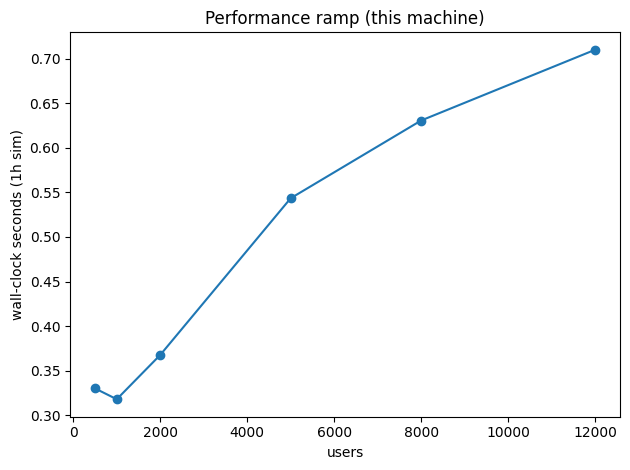

In [8]:
RAMP_USERS = [500, 1000, 2000, 5000, 8000, 12000]
rows = []

for n in RAMP_USERS:
    cfg = dict(BASE_LAPTOP)
    cfg.update(users=n, hours=1.0, fork_hour=0.5, server_mode="honest", p_gossip=0.0, adoption=0.0)
    cfg["groups"] = int(min(4*n, 20000))
    cfg["avg_group_size"] = 10
    cfg["msg_rate_group"] = 0.02
    cfg["msg_rate_1to1"] = 0.05

    outdir = OUT_ROOT / "ramp" / f"n{n}"
    outdir_path, wall_s = run_sim(cfg, outdir)
    summary, _, _ = load_run(outdir_path)
    rows.append(dict(users=n, wall_s=wall_s,
                     total_deliveries=summary.get("total_deliveries", summary.get("total_messages", np.nan)),
                     total_sends=summary.get("total_sends", np.nan),
                     groups=cfg["groups"]))
    print("users=", n, "wall_s=", round(wall_s, 2))

df_ramp = pd.DataFrame(rows)
df_ramp.to_csv(OUT_ROOT / "ramp.csv", index=False)
df_ramp

plt.figure()
plt.plot(df_ramp["users"], df_ramp["wall_s"], marker="o")
plt.xlabel("users")
plt.ylabel("wall-clock seconds (1h sim)")
plt.title("Performance ramp (this machine)")
plt.tight_layout()
plt.show()

## Experiment 1 --- Sanity Checks

In [9]:

def one_run(name, cfg):
   outdir = OUT_ROOT / "sanity" / name
   outdir_path, wall_s = run_sim(cfg, outdir)
   summary, timeline, _ = load_run(outdir_path)
   dm = derived_metrics(summary, timeline, fallback=cfg, detection_policy="strict")
    # ---- Normalize metric names for tables/plots ----
    # Use evidence metrics as the detection metrics in the baseline.
   dm["coverage_end"] = dm.get("evid_cov_end", dm.get("coverage_end", np.nan))
    # Depending on notebook version, t10/t50 may be stored as *_ev_med (minutes) or *_ev_min
   dm["t10_min"] = dm.get("t10_ev_med", dm.get("t10_ev_min", dm.get("t10_min", np.nan)))
   dm["t50_min"] = dm.get("t50_ev_med", dm.get("t50_ev_min", dm.get("t50_min", np.nan)))
   # Overhead alias (some versions call it bytes_per_delivery, some bpd)
   if "bytes_per_delivery" not in dm:
      dm["bytes_per_delivery"] = dm.get("bpd", dm.get("bpd_mean", np.nan))
        
   dm["name"] = name
   dm["wall_s"] = wall_s
   # Pull these directly from summary.json (they exist there)
   dm["proof_inconsistent"] = int(summary.get("proof_inconsistent", 0))
   dm["proof_ok"] = int(summary.get("proof_ok", 0))
   dm["proof_withhold"] = int(summary.get("proof_withhold", 0))
   dm["proof_timeout"] = int(summary.get("proof_timeout", 0))
   # Crosscut diagnostics
   total_deliv = float(summary.get("total_deliveries", summary.get("total_messages", 0)) or 0)
   crosscuts = float(summary.get("crosscut_deliveries", 0))
   x_deliv = float(summary.get("crosscut_deliveries", 0))
   x_drop  = float(summary.get("crosscut_dropped", 0))
   # Treat "delivered crosscuts" as delivered-minus-dropped (robust even if simulator double-counts)
   x_effective = max(0.0, x_deliv - x_drop)
   dm["crosscuts_deliv"] = x_deliv
   dm["crosscuts_drop"] = x_drop
   dm["crosscuts_eff"] = x_effective
   dm["crosscut_rate_eff"] = (x_effective / total_deliv) if total_deliv > 0 else np.nan
    
   dm["proof_per_crosscut"] = (dm["proof_inconsistent"] / crosscuts) if crosscuts > 0 else np.nan
   return dm
cases = []
cases.append(one_run(
   "honest",
   dict(BASE_SMALL, server_mode="honest", p_gossip=0.2, adoption=0.5)
))
cases.append(one_run(
   "fork_no_gossip",
   dict(BASE_SMALL, server_mode="permanent_fork", p_gossip=0.0, adoption=0.0)
))
cases.append(one_run(
   "fork_with_gossip",
   dict(BASE_SMALL, server_mode="permanent_fork", p_gossip=0.2, adoption=0.5)
))
cases.append(one_run(
   "fork_with_gossip_highmix",
   dict(
       BASE_SMALL,
       hours=6.0, fork_hour=3.0, fork_duration=2.0,
       server_mode="permanent_fork",
       p_gossip=0.2, adoption=1.0,
       msg_rate_1to1=0.20,
       msg_rate_group=0.08,
       p_contact_cross=0.05,
       p_group_cross=0.05
   )
))
cases.append(one_run(
   "fork_with_gossip_censored",
   dict(
       BASE_SMALL,
       hours=6.0, fork_hour=3.0, fork_duration=2.0,
       server_mode="permanent_fork",
       p_gossip=0.2, adoption=1.0,
       msg_rate_1to1=0.20,
       msg_rate_group=0.08,
       p_contact_cross=0.05,
       p_group_cross=0.05,
       p_drop_crosscut=1.0
   )
))
df_sanity2 = pd.DataFrame(cases)
df_sanity2.to_csv(OUT_ROOT / "sanity_ladder.csv", index=False)
# Show key columns (now guaranteed to exist)
cols = [
   "name","server_mode","p_gossip","adoption",
   "detected","coverage_end","t10_min","t50_min",
   "crosscuts_eff","crosscut_rate_eff","proof_inconsistent","proof_per_crosscut",
   "bytes_per_delivery","wall_s"
]
df_sanity2[cols]

Done. See C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\honest/summary.json and C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\honest/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_no_gossip/summary.json and C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_no_gossip/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_gossip/summary.json and C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_gossip/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_gossip_highmix/summary.json and C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_gossip_highmix/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_gossip_censored/summary.json and C:\Users\efasllija\dev\gossip-poc-artifact\out_artifacts\sanity\fork_with_g

,name,server_mode,p_gossip,adoption,detected,coverage_end,t10_min,t50_min,crosscuts_eff,crosscut_rate_eff,proof_inconsistent,proof_per_crosscut,bytes_per_delivery,wall_s
0,honest,honest,0.2,0.5,False,0.0,NaN,NaN,0.0,0.000000,0,NaN,113.542700,0.285076
1,fork_no_gossip,permanent_fork,0.0,0.0,False,0.0,NaN,NaN,0.0,0.000000,0,NaN,0.000000,0.254829
2,fork_with_gossip,permanent_fork,0.2,0.5,True,0.0,NaN,NaN,2.0,0.002755,2,1.0,113.542700,0.240367
3,fork_with_gossip_highmix,permanent_fork,0.2,1.0,True,0.0,NaN,NaN,116.0,0.019768,116,1.0,170.252215,0.275156
4,fork_with_gossip_censored,permanent_fork,0.2,1.0,False,0.0,NaN,NaN,0.0,0.000000,0,0.0,152.539877,0.274036


## Scenario 1 — Typical deployment BASELINE

In [34]:
# =========================
# Shared showcase plot helpers
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

COL_USERS = "users"
COL_ADOPT = "adoption"
COL_PG = "p_gossip"
COL_DET = "detected_rate"
COL_LAT = "lat_ev_med"
COL_OVH = "bpd_mean"
COL_MSG95 = "msgs_first_ev_med"


def pareto_frontier(df, x, y):
    d = df[[x, y]].dropna().sort_values(x).copy()
    best = np.inf
    keep = []
    for _, r in d.iterrows():
        if float(r[y]) < best:
            best = float(r[y])
            keep.append(True)
        else:
            keep.append(False)
    return d.loc[keep].copy()


def isotonic_fit_monotone(x, y):
    # PAVA for non-decreasing y
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x, y = x[order], y[order]

    levels = y.copy()
    weights = np.ones_like(levels)

    i = 0
    while i < len(levels) - 1:
        if levels[i] <= levels[i + 1]:
            i += 1
            continue

        new_level = (
            levels[i] * weights[i] + levels[i + 1] * weights[i + 1]
        ) / (weights[i] + weights[i + 1])

        levels[i] = new_level
        weights[i] += weights[i + 1]

        levels = np.delete(levels, i + 1)
        weights = np.delete(weights, i + 1)
        x = np.delete(x, i + 1)

        i = max(i - 1, 0)

    return x, levels


def min_pg_for_threshold(x_step, y_step, thr=0.95):
    if len(x_step) == 0:
        return np.nan
    for xi, yi in zip(x_step, y_step):
        if yi >= thr:
            return float(xi)
    return np.nan


def plot_showcase_for_users(
    df_all,
    users,
    plots_dir,
    det_thr=0.95,
    adoption_order=None,
):
    dU = df_all[df_all[COL_USERS] == users].copy()
    dU[COL_ADOPT] = dU[COL_ADOPT].astype(float)
    dU[COL_PG] = dU[COL_PG].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU[COL_ADOPT].dropna().unique())

    fig = plt.figure(figsize=(3.45, 8.2))
    gs = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.2, 1.0, 0.85], hspace=0.38)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])
    ax4 = fig.add_subplot(gs[3, 0])

    # Panel 1: detection curves
    min_pg = []
    for a in adoption_order:
        s = dU[dU[COL_ADOPT] == a].sort_values(COL_PG)
        x = s[COL_PG].to_numpy()
        y = s[COL_DET].to_numpy()

        xs, ys = isotonic_fit_monotone(x, y)

        m = np.isfinite(x) & np.isfinite(y)
        ax1.plot(x[m], y[m], marker="o", linestyle="None", markersize=2.8, alpha=0.55)

        if len(xs):
            ax1.step(xs, ys, where="post", linewidth=1.4, label=f"adopt={a:g}")

        min_pg.append((a, min_pg_for_threshold(xs, ys, det_thr)))

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection prob.")
    ax1.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax1.set_title(f"Typical regime, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # Panel 2: latency vs overhead for det >= threshold + Pareto frontier
    rel = dU[dU[COL_DET] >= det_thr].copy()
    for a in adoption_order:
        s = rel[rel[COL_ADOPT] == a].copy()
        x = s[COL_OVH].astype(float).to_numpy()
        y = s[COL_LAT].astype(float).to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.scatter(x[m], y[m], s=16, alpha=0.75, label=f"adopt={a:g}")

    front = pareto_frontier(rel, COL_OVH, COL_LAT)
    if not front.empty:
        ax2.plot(front[COL_OVH], front[COL_LAT], linewidth=1.6)

    ax2.set_xlabel("Overhead (B / delivered msg)")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25)
    ax2.legend(fontsize=7, frameon=True, ncol=2, loc="upper right")

    # Panel 3: total messages until 95% evidence
    for a in adoption_order:
        s = dU[dU[COL_ADOPT] == a].sort_values(COL_PG)
        x = s[COL_PG].to_numpy()
        y = s[COL_MSG95].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(x[m], y[m], marker="o", linewidth=1.3, label=f"adopt={a:g}")

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Msgs until first ev.")
    ax3.grid(True, alpha=0.25, which="both")

    # Panel 4: min p_gossip for det >= threshold
    mp = pd.DataFrame(min_pg, columns=[COL_ADOPT, "min_p_gossip"])
    mp = mp[np.isfinite(mp["min_p_gossip"])].sort_values(COL_ADOPT)
    if not mp.empty:
        ax4.plot(mp[COL_ADOPT], mp["min_p_gossip"], marker="o", linewidth=1.5)

    ax4.set_yscale("log")
    ax4.set_xlabel("Adoption")
    ax4.set_ylabel(r"min $p_{\mathrm{gossip}}$")
    ax4.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"fig_typical_showcase_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

In [35]:
# =========================
# Scenario 1: Typical regime definition
# =========================

OUT_TYPICAL = OUT_ROOT / "paper_sweeps_typical_showcase"

BASE_TYPICAL = dict(BASE_SMALL)
BASE_TYPICAL.update(
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",
    msg_rate_1to1=0.20,
    msg_rate_group=0.08,
    p_contact_cross=0.05,
    p_group_cross=0.05,
    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,
)

P_GOSSIP_GRID_TYPICAL = [
    0.002, 0.003, 0.005, 0.008, 0.01, 0.015, 0.02,
    0.03, 0.05, 0.08, 0.10, 0.15, 0.20
]
ADOPTION_GRID_TYPICAL = [0.05, 0.10, 0.20, 0.30, 0.60]
USERS_GRID_TYPICAL = [2000, 8000, 12000]

SWEEP_TYPICAL = dict(
    users=USERS_GRID_TYPICAL,
    p_gossip=P_GOSSIP_GRID_TYPICAL,
    adoption=ADOPTION_GRID_TYPICAL,
)

REPS_TYPICAL = 15
SEED_BASE_TYPICAL = 20000
DET_THR_TYPICAL = 0.95

GROUP_COLS_TYPICAL = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

In [36]:
# =========================
# Scenario 1: Typical regime execution
# =========================

OUT_TYPICAL.mkdir(parents=True, exist_ok=True)

df_raw_typical = run_grid(
    BASE_TYPICAL,
    SWEEP_TYPICAL,
    replicates=REPS_TYPICAL,
    seed_base=SEED_BASE_TYPICAL,
    outroot=OUT_TYPICAL,
    detection_policy="strict",
)

df_raw_typical.to_csv(OUT_TYPICAL / "raw.csv", index=False)

df_agg_typical = aggregate_runs(df_raw_typical, GROUP_COLS_TYPICAL)
df_agg_typical.to_csv(OUT_TYPICAL / "agg.csv", index=False)

print("Wrote raw:", (OUT_TYPICAL / "raw.csv").resolve())
print("Wrote agg:", (OUT_TYPICAL / "agg.csv").resolve())
print("Raw rows:", len(df_raw_typical))
display(df_raw_typical.head())
display(df_agg_typical.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20000_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20000_drop0_pc0p05_pgc0p05/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20001_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20001_drop0_pc0p05_pgc0p05/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20002_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\paper_sweeps_typical_showcase\permanent_fork_sth_pr

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,2000,6.0,5.0,0.002,0.05,0.05,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.410433,C:/Users/efasllija/dev/gossip-poc/out_artifact...
1,permanent_fork,sth_proof,2000,6.0,5.0,0.002,0.05,0.05,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.366953,C:/Users/efasllija/dev/gossip-poc/out_artifact...
2,permanent_fork,sth_proof,2000,6.0,5.0,0.002,0.05,0.05,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.376697,C:/Users/efasllija/dev/gossip-poc/out_artifact...
3,permanent_fork,sth_proof,2000,6.0,5.0,0.002,0.05,0.05,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.376617,C:/Users/efasllija/dev/gossip-poc/out_artifact...
4,permanent_fork,sth_proof,2000,6.0,5.0,0.002,0.05,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.399024,C:/Users/efasllija/dev/gossip-poc/out_artifact...


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,2000,0.05,0.002,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,15,...,NaN,NaN,NaN,12266.0,NaN,NaN,0.121641,0.121641,0.066667,0.066667
1,2000,0.05,0.003,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,15,...,NaN,NaN,NaN,10818.5,NaN,NaN,0.187874,0.187874,0.200000,0.200000
2,2000,0.05,0.005,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,15,...,NaN,NaN,NaN,12266.0,NaN,NaN,0.296923,0.296923,1.000000,1.000000
3,2000,0.05,0.008,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,15,...,NaN,NaN,NaN,12033.5,NaN,NaN,0.400849,0.400849,1.066667,1.066667
4,2000,0.05,0.010,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,15,...,NaN,NaN,NaN,12033.5,NaN,NaN,0.413896,0.413896,1.066667,1.066667


In [42]:
# =========================
# Scenario 1: Typical regime plots
# =========================

PLOTS_TYPICAL = OUT_TYPICAL / "plots_showcase"
PLOTS_TYPICAL.mkdir(parents=True, exist_ok=True)

for U in sorted(df_agg_typical[COL_USERS].dropna().unique()):
    plot_showcase_for_users(
        df_agg_typical,
        users=int(U),
        plots_dir=PLOTS_TYPICAL,
        det_thr=DET_THR_TYPICAL,
    )

NameError: name 'plot_showcase_for_users' is not defined

## attempt for cleaner plots

C:\Users\efasllija\AppData\Local\Temp\ipykernel_30108\2891681481.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


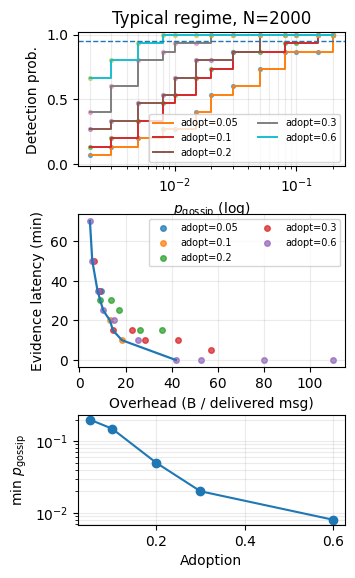

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_main\fig_typical_main3_N2000.pdf


C:\Users\efasllija\AppData\Local\Temp\ipykernel_30108\2891681481.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


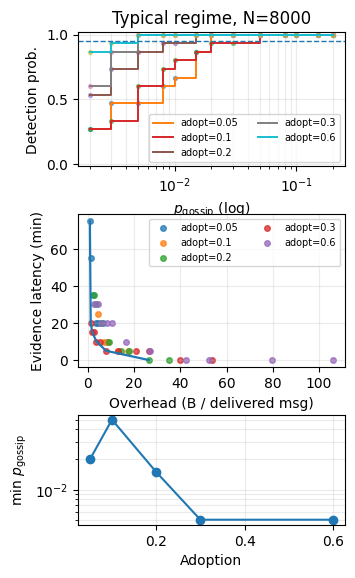

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_main\fig_typical_main3_N8000.pdf


C:\Users\efasllija\AppData\Local\Temp\ipykernel_30108\2891681481.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


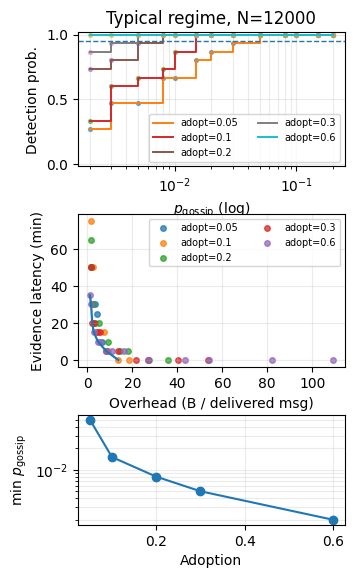

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_main\fig_typical_main3_N12000.pdf


In [43]:
# =========================
# Typical regime: cleaner 3-panel main figure
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_TYPICAL_MAIN = OUT_TYPICAL / "plots_main"
PLOTS_TYPICAL_MAIN.mkdir(parents=True, exist_ok=True)

COL_USERS = "users"
COL_ADOPT = "adoption"
COL_PG = "p_gossip"
COL_DET = "detected_rate"
COL_LAT = "lat_ev_med"
COL_OVH = "bpd_mean"

def pareto_frontier(df, x, y):
    d = df[[x, y]].dropna().sort_values(x).copy()
    best = np.inf
    keep = []
    for _, r in d.iterrows():
        if float(r[y]) < best:
            best = float(r[y])
            keep.append(True)
        else:
            keep.append(False)
    return d.loc[keep].copy()

def isotonic_fit_monotone(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x, y = x[order], y[order]

    levels = y.copy()
    weights = np.ones_like(levels)

    i = 0
    while i < len(levels) - 1:
        if levels[i] <= levels[i + 1]:
            i += 1
            continue

        new_level = (
            levels[i] * weights[i] + levels[i + 1] * weights[i + 1]
        ) / (weights[i] + weights[i + 1])

        levels[i] = new_level
        weights[i] += weights[i + 1]

        levels = np.delete(levels, i + 1)
        weights = np.delete(weights, i + 1)
        x = np.delete(x, i + 1)

        i = max(i - 1, 0)

    return x, levels

def min_pg_for_threshold(x_step, y_step, thr=0.95):
    if len(x_step) == 0:
        return np.nan
    for xi, yi in zip(x_step, y_step):
        if yi >= thr:
            return float(xi)
    return np.nan

def plot_typical_main_3panel(
    df_all,
    users,
    plots_dir,
    det_thr=0.95,
    adoption_order=None,
):
    dU = df_all[df_all[COL_USERS] == users].copy()
    dU[COL_ADOPT] = dU[COL_ADOPT].astype(float)
    dU[COL_PG] = dU[COL_PG].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU[COL_ADOPT].dropna().unique())

    fig = plt.figure(figsize=(3.45, 6.4))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.1, 1.25, 0.9], hspace=0.36)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # Panel 1: detection curves
    min_pg = []
    for a in adoption_order:
        s = dU[dU[COL_ADOPT] == a].sort_values(COL_PG)
        x = s[COL_PG].to_numpy()
        y = s[COL_DET].to_numpy()

        xs, ys = isotonic_fit_monotone(x, y)

        m = np.isfinite(x) & np.isfinite(y)
        ax1.plot(x[m], y[m], marker="o", linestyle="None", markersize=2.8, alpha=0.55)

        if len(xs):
            ax1.step(xs, ys, where="post", linewidth=1.4, label=f"adopt={a:g}")

        min_pg.append((a, min_pg_for_threshold(xs, ys, det_thr)))

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection prob.")
    ax1.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax1.set_title(f"Typical regime, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # Panel 2: latency vs overhead for det >= threshold
    rel = dU[dU[COL_DET] >= det_thr].copy()
    for a in adoption_order:
        s = rel[rel[COL_ADOPT] == a].copy()
        x = s[COL_OVH].astype(float).to_numpy()
        y = s[COL_LAT].astype(float).to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.scatter(x[m], y[m], s=16, alpha=0.75, label=f"adopt={a:g}")

    front = pareto_frontier(rel, COL_OVH, COL_LAT)
    if not front.empty:
        ax2.plot(front[COL_OVH], front[COL_LAT], linewidth=1.6)

    ax2.set_xlabel("Overhead (Bytes / delivered msg)")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25)
    ax2.legend(fontsize=7, frameon=True, ncol=2, loc="upper right")

    # Panel 3: min p_gossip for det >= threshold
    mp = pd.DataFrame(min_pg, columns=[COL_ADOPT, "min_p_gossip"])
    mp = mp[np.isfinite(mp["min_p_gossip"])].sort_values(COL_ADOPT)
    if not mp.empty:
        ax3.plot(mp[COL_ADOPT], mp["min_p_gossip"], marker="o", linewidth=1.5)

    ax3.set_yscale("log")
    ax3.set_xlabel("Adoption")
    ax3.set_ylabel(r"min $p_{\mathrm{gossip}}$")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"fig_typical_main3_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())


for U in sorted(df_agg_typical[COL_USERS].dropna().unique()):
    plot_typical_main_3panel(
        df_agg_typical,
        users=int(U),
        plots_dir=PLOTS_TYPICAL_MAIN,
        det_thr=DET_THR_TYPICAL,
    )

## Typical regime: companion grouped-bar figure
# Total app messages until first evidence

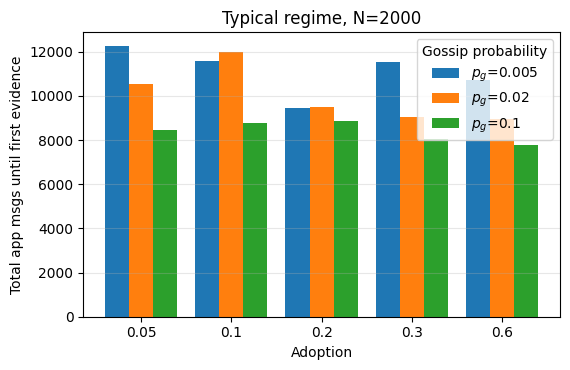

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_companion\fig_typical_messages_first_evidence_bars_N2000.pdf


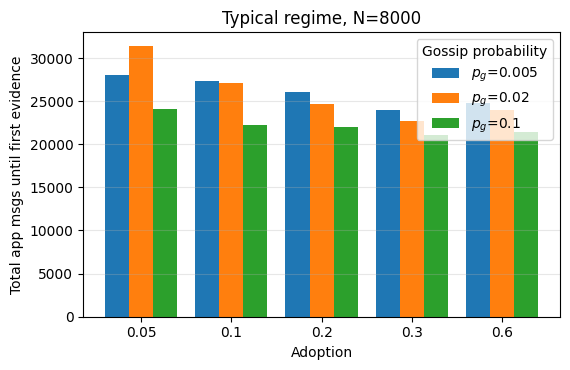

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_companion\fig_typical_messages_first_evidence_bars_N8000.pdf


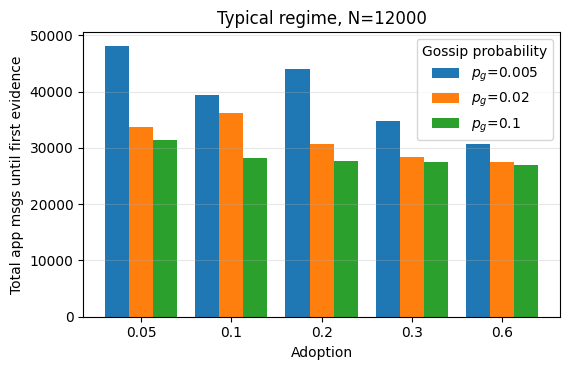

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_companion\fig_typical_messages_first_evidence_bars_N12000.pdf


In [44]:
# =========================
# Typical regime: companion grouped-bar figure
# Total app messages until first evidence
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_TYPICAL_COMPANION = OUT_TYPICAL / "plots_companion"
PLOTS_TYPICAL_COMPANION.mkdir(parents=True, exist_ok=True)

def plot_typical_messages_first_evidence_bars(
    df_agg,
    users,
    plots_dir,
    pg_bar_values=(0.005, 0.02, 0.1),
    adoption_order=None,
    value_col="msgs_first_ev_med",
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU["adoption"].dropna().unique())

    available_pg = sorted(dU["p_gossip"].dropna().unique())
    if len(available_pg) == 0:
        raise ValueError(f"No p_gossip values found for users={users}")

    # snap requested values to nearest actual values
    chosen_pg = []
    for target in pg_bar_values:
        nearest = min(available_pg, key=lambda x: abs(float(x) - float(target)))
        if nearest not in chosen_pg:
            chosen_pg.append(nearest)
    chosen_pg = sorted(chosen_pg)

    fig, ax = plt.subplots(figsize=(5.8, 3.8))

    x = np.arange(len(adoption_order))
    width = 0.8 / max(len(chosen_pg), 1)

    for i, pg in enumerate(chosen_pg):
        heights = []
        for a in adoption_order:
            s = dU[(np.isclose(dU["adoption"], a)) & (np.isclose(dU["p_gossip"], pg))]
            if len(s) == 0:
                heights.append(np.nan)
            else:
                heights.append(float(s[value_col].iloc[0]))

        xpos = x - 0.4 + width / 2 + i * width
        ax.bar(xpos, heights, width=width, label=f"$p_g$={pg:g}")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{a:g}" for a in adoption_order])
    ax.set_xlabel("Adoption")
    ax.set_ylabel("Total app msgs until first evidence")
    ax.set_title(f"Typical regime, N={users}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Gossip probability")

    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"fig_typical_messages_first_evidence_bars_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())


for U in sorted(df_agg_typical["users"].dropna().unique()):
    plot_typical_messages_first_evidence_bars(
        df_agg=df_agg_typical,
        users=int(U),
        plots_dir=PLOTS_TYPICAL_COMPANION,
        pg_bar_values=(0.005, 0.02, 0.1),
        value_col="msgs_first_ev_med",
    )

## messages alternative plot

In [43]:
# =========================
# Additional plot: grouped bars for total messages until first evidence
# (preserves the original line-based message plot)
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_messages_until_first_evidence_bars(
    df_agg,
    users,
    plots_dir,
    pg_bar_values=(0.005, 0.02, 0.1),
    adoption_order=None,
    value_col="msgs_first_ev_med",
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU["adoption"].dropna().unique())

    available_pg = sorted(dU["p_gossip"].dropna().unique())
    if len(available_pg) == 0:
        raise ValueError(f"No p_gossip values found for users={users}")

    # Snap requested p_gossip values to nearest available values in the data
    chosen_pg = []
    for target in pg_bar_values:
        nearest = min(available_pg, key=lambda x: abs(float(x) - float(target)))
        if nearest not in chosen_pg:
            chosen_pg.append(nearest)
    chosen_pg = sorted(chosen_pg)

    fig, ax = plt.subplots(figsize=(7.2, 4.6))

    x = np.arange(len(adoption_order))
    width = 0.8 / max(len(chosen_pg), 1)

    for i, pg in enumerate(chosen_pg):
        heights = []
        for a in adoption_order:
            s = dU[(np.isclose(dU["adoption"], a)) & (np.isclose(dU["p_gossip"], pg))]
            if len(s) == 0:
                heights.append(np.nan)
            else:
                heights.append(float(s[value_col].iloc[0]))

        xpos = x - 0.4 + width / 2 + i * width
        ax.bar(xpos, heights, width=width, label=f"$p_g$={pg:g}")

    ax.set_xticks(x)
    ax.set_xticklabels([f"{a:g}" for a in adoption_order])
    ax.set_xlabel("Adoption")
    ax.set_ylabel("Total app msgs until first evidence")
    ax.set_title(f"Typical regime, N={users}")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend(title="Gossip probability")

    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"bars_messages_first_evidence_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

In [44]:
# =========================
# Additional table: total messages until first evidence
# (same metric as grouped bars, easier to read exact values)
# =========================
from pathlib import Path

def messages_table_for_users(
    df_agg,
    users,
    pg_values=(0.005, 0.02, 0.1),
    value_col="msgs_first_ev_med",
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)

    available_pg = sorted(dU["p_gossip"].dropna().unique())
    if len(available_pg) == 0:
        raise ValueError(f"No p_gossip values found for users={users}")

    # Snap requested p_gossip values to nearest available values in the data
    chosen_pg = []
    for target in pg_values:
        nearest = min(available_pg, key=lambda x: abs(float(x) - float(target)))
        if nearest not in chosen_pg:
            chosen_pg.append(nearest)
    chosen_pg = sorted(chosen_pg)

    rows = []
    for a in sorted(dU["adoption"].dropna().unique()):
        row = {"adoption": a}
        for pg in chosen_pg:
            s = dU[(np.isclose(dU["adoption"], a)) & (np.isclose(dU["p_gossip"], pg))]
            row[f"p_g={pg:g}"] = float(s[value_col].iloc[0]) if len(s) else np.nan
        rows.append(row)

    return pd.DataFrame(rows)


def save_messages_table_csv(
    df_agg,
    users,
    outdir,
    pg_values=(0.005, 0.02, 0.1),
    value_col="msgs_first_ev_med",
):
    tbl = messages_table_for_users(
        df_agg=df_agg,
        users=users,
        pg_values=pg_values,
        value_col=value_col,
    )

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)
    out_csv = outdir / f"table_messages_first_evidence_N{users}.csv"
    tbl.to_csv(out_csv, index=False)

    # Pretty display copy
    tbl_fmt = tbl.copy()
    for c in tbl_fmt.columns:
        if c != "adoption":
            tbl_fmt[c] = tbl_fmt[c].map(lambda x: "" if pd.isna(x) else f"{int(round(x)):,}")

    print("Wrote:", out_csv.resolve())
    display(tbl_fmt)

    return tbl

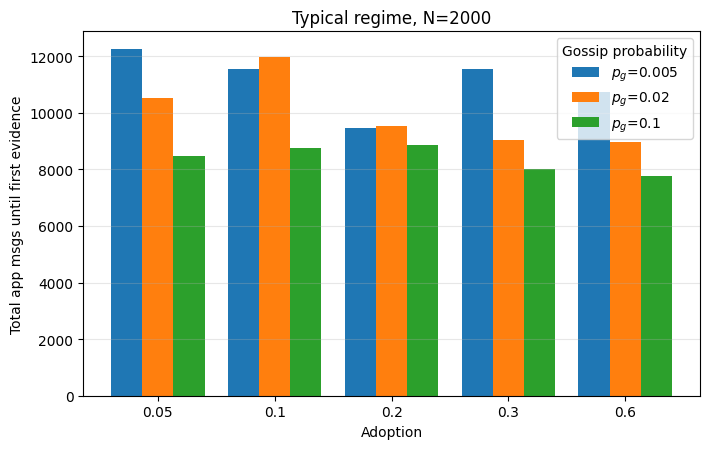

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_showcase_extra\bars_messages_first_evidence_N2000.pdf
Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\tables_showcase\table_messages_first_evidence_N2000.csv


,adoption,p_g=0.005,p_g=0.02,p_g=0.1
0,0.05,"12,266","10,530","8,475"
1,0.10,"11,565","11,989","8,771"
2,0.20,"9,451","9,518","8,868"
3,0.30,"11,547","9,030","8,031"
4,0.60,"10,728","8,963","7,778"


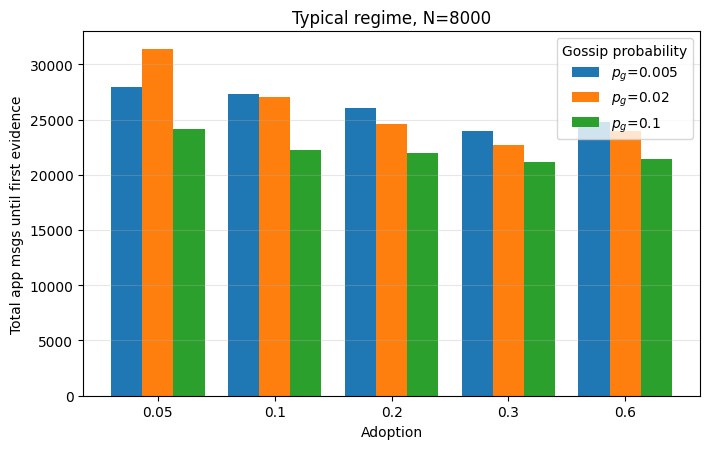

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_showcase_extra\bars_messages_first_evidence_N8000.pdf
Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\tables_showcase\table_messages_first_evidence_N8000.csv


,adoption,p_g=0.005,p_g=0.02,p_g=0.1
0,0.05,"27,979","31,410","24,120"
1,0.10,"27,321","27,067","22,247"
2,0.20,"26,085","24,622","21,964"
3,0.30,"23,983","22,675","21,128"
4,0.60,"24,784","23,996","21,382"


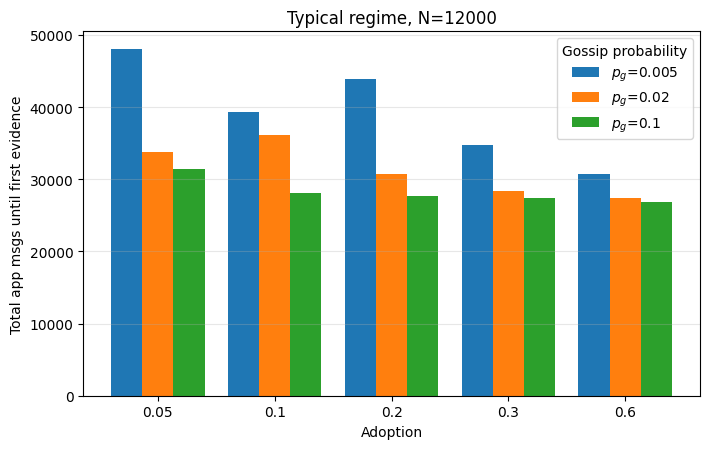

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\plots_showcase_extra\bars_messages_first_evidence_N12000.pdf
Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\tables_showcase\table_messages_first_evidence_N12000.csv


,adoption,p_g=0.005,p_g=0.02,p_g=0.1
0,0.05,"48,103","33,732","31,379"
1,0.10,"39,384","36,136","28,163"
2,0.20,"43,918","30,671","27,636"
3,0.30,"34,690","28,399","27,398"
4,0.60,"30,721","27,474","26,903"


In [45]:
# =========================
# Generate additional bar plots and tables for total messages until first evidence
# =========================
PLOTS_TYPICAL_EXTRA = OUT_TYPICAL / "plots_showcase_extra"
TABLES_TYPICAL = OUT_TYPICAL / "tables_showcase"

for U in sorted(df_agg_typical["users"].dropna().unique()):
    plot_messages_until_first_evidence_bars(
        df_agg=df_agg_typical,
        users=int(U),
        plots_dir=PLOTS_TYPICAL_EXTRA,
        pg_bar_values=(0.005, 0.02, 0.1),
        value_col="msgs_first_ev_med",
    )

    _ = save_messages_table_csv(
        df_agg=df_agg_typical,
        users=int(U),
        outdir=TABLES_TYPICAL,
        pg_values=(0.005, 0.02, 0.1),
        value_col="msgs_first_ev_med",
    )

In [15]:
# =========================
# Scenario 1: sanity checks
# =========================

print("df_raw_typical columns:")
print(sorted(df_raw_typical.columns))

print("\ndf_agg_typical columns:")
print(sorted(df_agg_typical.columns))

display(
    df_agg_typical[
        ["users", "adoption", "p_gossip", "detected_rate", "lat_ev_med", "bpd_mean", "msgs_95_ev_med"]
    ].head(12)
)

df_raw_typical columns:
['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']

df_agg_typical columns:
['adoption', 'aware_cov_end_mean', 'bpd_mean', 'bps_mean', 'crosscuts_mean', 'detected_rate', 'evid_cov_end_mean', 'evidence_mean', 'fork_frac', 'lat_aw_med', 'lat_ev_med', 'mode', 'msgs_50_ev_med', 'msgs_95_ev_med', 'msgs_first_ev_med', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'reps', 'server_mode', 't10_a

,users,adoption,p_gossip,detected_rate,lat_ev_med,bpd_mean,msgs_95_ev_med
0,2000,0.05,0.002,0.066667,100.0,0.121641,NaN
1,2000,0.05,0.003,0.133333,65.0,0.187874,NaN
2,2000,0.05,0.005,0.200000,100.0,0.296923,NaN
3,2000,0.05,0.008,0.266667,102.5,0.400849,NaN
4,2000,0.05,0.010,0.266667,102.5,0.413896,NaN
5,2000,0.05,0.015,0.400000,65.0,0.603441,NaN
6,2000,0.05,0.020,0.533333,65.0,0.810762,NaN
7,2000,0.05,0.030,0.600000,70.0,1.139926,NaN
8,2000,0.05,0.050,0.733333,65.0,1.633525,NaN
9,2000,0.05,0.080,0.866667,35.0,3.435930,NaN


## Mixing sweeps Helpers for scenario 2 and/or 2a

In [37]:
# =========================
# Mixing sweep (for mixing-comparison figures)
# Creates df_raw_mix / df_agg_mix / df_agg_mix_iqr
# =========================

OUT_MIXSWEEP = OUT_ROOT / "scenario_mixing_sweep"

BASE_MIXSWEEP = dict(BASE_SMALL)
BASE_MIXSWEEP.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    msg_rate_1to1=0.20,
    msg_rate_group=0.08,

    p_drop_crosscut=0.0,
    fork_frac=0.05,
    sticky_victims=True,
)

ADOPTION_GRID_MIXSWEEP = [0.10, 0.20, 0.30]
P_GOSSIP_GRID_MIXSWEEP = [0.003, 0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05]
MIX_GRID = [0.01, 0.02, 0.03, 0.05]

REPS_MIXSWEEP = 15
SEED_BASE_MIXSWEEP = 48000
DET_THR_MIXSWEEP = 0.95

In [38]:
# =========================
# Run mixing sweep
# =========================

OUT_MIXSWEEP.mkdir(parents=True, exist_ok=True)

rows_mix = []

for mix in MIX_GRID:
    base_cfg = dict(BASE_MIXSWEEP)
    base_cfg.update(
        p_contact_cross=mix,
        p_group_cross=mix,
    )

    sweep_cfg = dict(
        adoption=ADOPTION_GRID_MIXSWEEP,
        p_gossip=P_GOSSIP_GRID_MIXSWEEP,
    )

    df_part = run_grid(
        base_cfg,
        sweep_cfg,
        replicates=REPS_MIXSWEEP,
        seed_base=SEED_BASE_MIXSWEEP,
        outroot=OUT_MIXSWEEP / f"mix_{mix:g}".replace(".", "p"),
        detection_policy="strict",
    ).copy()

    df_part["mix_level"] = mix
    rows_mix.append(df_part)

df_raw_mix = pd.concat(rows_mix, ignore_index=True)
df_raw_mix.to_csv(OUT_MIXSWEEP / "raw.csv", index=False)

GROUP_COLS_MIX = [
    "users",
    "adoption",
    "p_gossip",
    "mix_level",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

df_agg_mix = aggregate_runs(df_raw_mix, GROUP_COLS_MIX)
df_agg_mix.to_csv(OUT_MIXSWEEP / "agg.csv", index=False)

df_agg_mix_iqr = aggregate_iqr_safe(df_raw_mix, GROUP_COLS_MIX)
df_agg_mix_iqr.to_csv(OUT_MIXSWEEP / "agg_iqr.csv", index=False)

print("Wrote raw:", (OUT_MIXSWEEP / "raw.csv").resolve())
print("Wrote agg:", (OUT_MIXSWEEP / "agg.csv").resolve())
print("Wrote agg_iqr:", (OUT_MIXSWEEP / "agg_iqr.csv").resolve())

display(df_agg_mix.head())
display(df_agg_mix_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p05_s48000_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p05_s48000_drop0_pc0p01_pgc0p01/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p05_s48001_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p05_s48001_drop0_pc0p01_pgc0p01/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p05_s48002_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\out_artifacts\scenario_mixing_sweep\mix_0p01\permanent_fork_

KeyboardInterrupt: 

## Scenario 2 LOWMIX (Low-mixing stress)

In [10]:
# =========================
# Scenario 2: Low-mixing stress definition
# =========================

OUT_LOWMIX = OUT_SUITE / "S2_lowmix"

BASE_LOWMIX = dict(BASE_SMALL)
BASE_LOWMIX.update(
    users=N_USERS,
    hours=HOURS,
    fork_hour=FORK_HOUR,
    fork_duration=FORK_DUR,
    server_mode="permanent_fork",
    mode="sth_proof",
    msg_rate_1to1=MSG_RATE_1to1,
    msg_rate_group=MSG_RATE_GROUP,
    fork_frac=FORK_FRAC_TYP,
    sticky_victims=STICKY_VICTIMS,
    p_drop_crosscut=0.0,
)

SWEEP_LOWMIX = dict(
    adoption=ADOPT_GRID,
    p_gossip=PG_GRID,
    p_contact_cross=[0.001, 0.003, 0.005, 0.01],
    p_group_cross=[0.001, 0.003, 0.005, 0.01],
)

GROUP_COLS_LOWMIX = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

SEED_BASE_LOWMIX = SEED_BASE + 1000
REPS_LOWMIX = REPS_EXPLORE
DET_THR_LOWMIX = DET_THR

In [11]:
# =========================
# Scenario 2: Low-mixing stress execution
# =========================

OUT_LOWMIX.mkdir(parents=True, exist_ok=True)

df_raw_lowmix = run_grid(
    BASE_LOWMIX,
    SWEEP_LOWMIX,
    replicates=REPS_LOWMIX,
    seed_base=SEED_BASE_LOWMIX,
    outroot=OUT_LOWMIX,
    detection_policy="strict",
)

df_raw_lowmix.to_csv(OUT_LOWMIX / "raw.csv", index=False)

df_agg_lowmix = aggregate_iqr_safe(df_raw_lowmix, GROUP_COLS_LOWMIX).sort_values(
    ["p_contact_cross", "adoption", "p_gossip"]
)

df_agg_lowmix = df_agg_lowmix[
    np.isclose(df_agg_lowmix["p_contact_cross"], df_agg_lowmix["p_group_cross"])
].copy()

df_agg_lowmix["mix_level"] = df_agg_lowmix["p_contact_cross"].astype(float)

df_agg_lowmix.to_csv(OUT_LOWMIX / "agg_iqr_safe.csv", index=False)

print("Wrote raw:", (OUT_LOWMIX / "raw.csv").resolve())
print("Wrote agg:", (OUT_LOWMIX / "agg_iqr_safe.csv").resolve())
display(df_raw_lowmix.head())
display(df_agg_lowmix.head(12))

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p05_s31000_drop0_pc0p001_pgc0p001/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p05_s31000_drop0_pc0p001_pgc0p001/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p05_s31001_drop0_pc0p001_pgc0p001/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p05_s31001_drop0_pc0p001_pgc0p001/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p05_s31002_drop0_pc0p001_pgc0p001/summary.json and C:\Users\efasllija\dev\gossip

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,1.131906,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.05,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.989771,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.980129,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.921959,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.946819,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75,mix_level
0,12000,0.1,0.005,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,37.50,126.25,0.359469,0.359469,1.777778,1.777778,NaN,NaN,NaN,0.001
16,12000,0.1,0.007,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,30.00,65.00,0.523710,0.523710,2.222222,2.222222,NaN,NaN,NaN,0.001
32,12000,0.1,0.010,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,25.00,35.00,0.978897,0.978897,3.888889,3.888889,NaN,NaN,NaN,0.001
48,12000,0.1,0.015,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,20.00,35.00,1.397386,1.397386,4.666667,4.666667,NaN,NaN,NaN,0.001
64,12000,0.1,0.020,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,20.00,35.00,1.805121,1.805121,5.888889,5.888889,NaN,NaN,NaN,0.001
80,12000,0.1,0.030,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,10.00,35.00,2.825162,2.825162,9.555556,9.555556,NaN,NaN,NaN,0.001
96,12000,0.1,0.050,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,5.00,20.00,4.508660,4.508660,18.333333,18.333333,NaN,NaN,NaN,0.001
112,12000,0.2,0.005,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,3.75,23.75,0.828725,0.828725,2.666667,2.666667,NaN,NaN,NaN,0.001
128,12000,0.2,0.007,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,0.00,15.00,1.249128,1.249128,4.000000,4.000000,NaN,NaN,NaN,0.001
144,12000,0.2,0.010,permanent_fork,sth_proof,0.05,0.001,0.001,0.0,9,...,0.00,15.00,1.627448,1.627448,7.222222,7.222222,NaN,NaN,NaN,0.001


In [12]:
# =========================
# Scenario 2: sanity checks
# =========================

print("df_raw_lowmix columns:")
print(sorted(df_raw_lowmix.columns))

print("\ndf_agg_lowmix columns:")
print(sorted(df_agg_lowmix.columns))

display(
    df_agg_lowmix[
        [
            "mix_level",
            "adoption",
            "p_gossip",
            "detected_rate",
            "lat_ev_med",
            "bpd_mean",
            "msgs_95_ev_med",
        ]
    ].head(12)
)

df_raw_lowmix columns:
['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']

df_agg_lowmix columns:
['adoption', 'bpd_mean', 'bps_mean', 'crosscuts_mean', 'detected_rate', 'evidence_mean', 'fork_frac', 'lat_ev_med', 'lat_ev_q25', 'lat_ev_q75', 'mix_level', 'mode', 'msgs_95_ev_med', 'msgs_95_ev_q25', 'msgs_95_ev_q75', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'reps', 'server_mode', 'users']


,mix_level,adoption,p_gossip,detected_rate,lat_ev_med,bpd_mean,msgs_95_ev_med
0,0.001,0.1,0.005,0.888889,67.5,0.359469,NaN
16,0.001,0.1,0.007,1.000000,40.0,0.523710,NaN
32,0.001,0.1,0.010,1.000000,35.0,0.978897,NaN
48,0.001,0.1,0.015,1.000000,35.0,1.397386,NaN
64,0.001,0.1,0.020,1.000000,35.0,1.805121,NaN
80,0.001,0.1,0.030,1.000000,20.0,2.825162,NaN
96,0.001,0.1,0.050,1.000000,15.0,4.508660,NaN
112,0.001,0.2,0.005,0.888889,10.0,0.828725,NaN
128,0.001,0.2,0.007,1.000000,10.0,1.249128,NaN
144,0.001,0.2,0.010,1.000000,5.0,1.627448,NaN


In [13]:
# =========================
# Scenario 2 plotting helper: low-mixing stress
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_lowmix_for_users(
    df_agg,
    users,
    plots_dir,
    det_thr=0.95,
    adoption_order=None,
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU["adoption"].dropna().unique())

    fig = plt.figure(figsize=(3.45, 6.7))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.1, 1.0], hspace=0.33)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection curves
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(x[m], y[m], marker="o", linewidth=1.4, markersize=3.5, label=f"adopt={a:g}")

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection probability")
    ax1.set_title(f"Low-mixing stress, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # -------------------------
    # Panel 2: latency curves
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["lat_ev_med"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.plot(x[m], y[m], marker="o", linewidth=1.4, markersize=3.5, label=f"adopt={a:g}")

            # Optional IQR band if present
            if "lat_ev_q25" in s.columns and "lat_ev_q75" in s.columns:
                y25 = s["lat_ev_q25"].to_numpy(dtype=float)
                y75 = s["lat_ev_q75"].to_numpy(dtype=float)
                m_band = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
                if m_band.any():
                    ax2.fill_between(x[m_band], y25[m_band], y75[m_band], alpha=0.15)

    ax2.set_xscale("log")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25, which="both")

    # -------------------------
    # Panel 3: overhead curves
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["bpd_mean"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(x[m], y[m], marker="o", linewidth=1.4, markersize=3.5, label=f"adopt={a:g}")

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"fig_lowmix_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

C:\Users\efasllija\AppData\Local\Temp\ipykernel_16612\4241161327.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


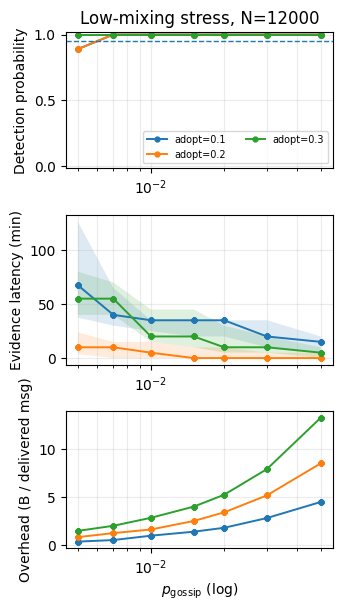

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\plots\fig_lowmix_N12000.pdf


In [14]:
# =========================
# Scenario 2: low-mixing stress plots
# =========================

PLOTS_LOWMIX = OUT_LOWMIX / "plots"
PLOTS_LOWMIX.mkdir(parents=True, exist_ok=True)

for U in sorted(df_agg_lowmix["users"].dropna().unique()):
    plot_lowmix_for_users(
        df_agg_lowmix,
        users=int(U),
        plots_dir=PLOTS_LOWMIX,
        det_thr=DET_THR_LOWMIX,
    )

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\446268447.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


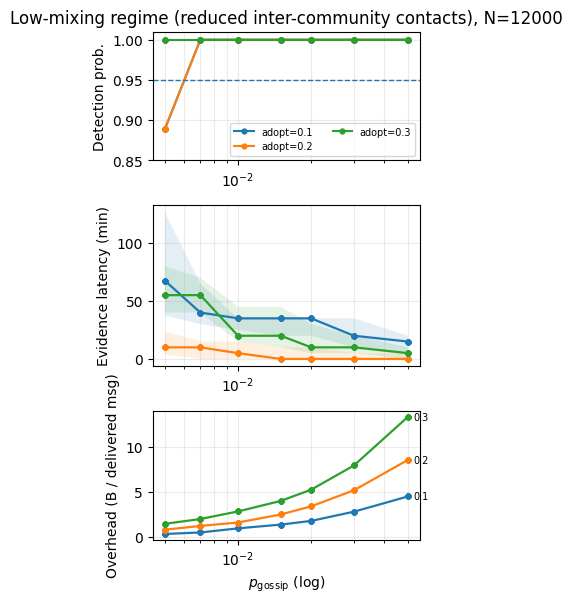

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S2_lowmix\plots_extra\fig_lowmix_publication_N12000.pdf


In [14]:
# =========================
# Extra plot: publication-style low-mixing figure
# - zoomed detection panel
# - lighter IQR shading for latency
# - overhead panel with markers and end-point labels
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_LOWMIX_EXTRA = Path(OUT_LOWMIX) / "plots_extra"
PLOTS_LOWMIX_EXTRA.mkdir(parents=True, exist_ok=True)

def plot_lowmix_publication(
    df_agg,
    users,
    adoption_order=None,
    det_thr=0.95,
    title="Low-mixing regime (reduced inter-community contacts)",
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU["adoption"].dropna().unique())

    fig = plt.figure(figsize=(3.45, 6.6))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.25, 1.0], hspace=0.32)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection (zoomed)
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy()
        y = s["detected_rate"].to_numpy()
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(x[m], y[m], marker="o", linewidth=1.5, markersize=3.5, label=f"adopt={a:g}")

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(0.85, 1.01)
    ax1.set_ylabel("Detection prob.")
    ax1.set_title(f"{title}, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # -------------------------
    # Panel 2: latency with lighter IQR
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")

        x = s["p_gossip"].to_numpy()
        y = s["lat_ev_med"].to_numpy()

        yq25 = s["lat_ev_q25"].to_numpy() if "lat_ev_q25" in s.columns else None
        yq75 = s["lat_ev_q75"].to_numpy() if "lat_ev_q75" in s.columns else None

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.plot(x[m], y[m], marker="o", linewidth=1.6, markersize=3.5, label=f"adopt={a:g}")

        if yq25 is not None and yq75 is not None:
            mq = np.isfinite(x) & np.isfinite(yq25) & np.isfinite(yq75)
            if mq.any():
                ax2.fill_between(x[mq], yq25[mq], yq75[mq], alpha=0.12)

    ax2.set_xscale("log")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25, which="both")

    # -------------------------
    # Panel 3: overhead with markers + end labels
    # -------------------------
    for a in adoption_order:
        s = dU[np.isclose(dU["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy()
        y = s["bpd_mean"].to_numpy()

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(x[m], y[m], marker="o", linewidth=1.6, markersize=3.5, label=f"adopt={a:g}")

            # annotate final point
            xf = x[m][-1]
            yf = y[m][-1]
            ax3.annotate(
                f"{a:g}",
                xy=(xf, yf),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=7,
                va="center",
            )

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    outbase = PLOTS_LOWMIX_EXTRA / f"fig_lowmix_publication_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())


for U in sorted(df_agg_lowmix["users"].dropna().unique()):
    plot_lowmix_publication(
        df_agg_lowmix,
        users=int(U),
        det_thr=0.95,
    )

## Scenario TRADEOFF(hard)

In [36]:
# =========================
# Scenario: TRADEOFF (hard)
# Low mixing + targeted victims
# Paper-oriented representative stress regime
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_TRADEOFF = OUT_ROOT / "scenario_tradeoff_hard"

BASE_TRADEOFF = dict(BASE_SMALL)
BASE_TRADEOFF.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # communication load
    msg_rate_1to1=0.20,
    msg_rate_group=0.08,

    # hard regime knobs
    fork_frac=0.02,
    p_contact_cross=0.005,
    p_group_cross=0.005,

    # no censorship in this scenario
    p_drop_crosscut=0.0,
    sticky_victims=True,
)

ADOPTION_GRID_TRADEOFF = [0.10, 0.20, 0.30]
P_GOSSIP_GRID_TRADEOFF = [0.003, 0.005, 0.008, 0.012, 0.020, 0.030, 0.050]

# Draft budget. For final paper rerun, increase to 12–15.
REPS_TRADEOFF = 8
SEED_BASE_TRADEOFF = 44000
DET_THR_TRADEOFF = 0.95

GROUP_COLS_TRADEOFF = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

In [37]:
# =========================
# Run TRADEOFF (hard)
# =========================

OUT_TRADEOFF.mkdir(parents=True, exist_ok=True)

SWEEP_TRADEOFF = dict(
    adoption=ADOPTION_GRID_TRADEOFF,
    p_gossip=P_GOSSIP_GRID_TRADEOFF,
)

df_raw_tradeoff = run_grid(
    BASE_TRADEOFF,
    SWEEP_TRADEOFF,
    replicates=REPS_TRADEOFF,
    seed_base=SEED_BASE_TRADEOFF,
    outroot=OUT_TRADEOFF,
    detection_policy="strict",
).copy()

df_raw_tradeoff.to_csv(OUT_TRADEOFF / "raw.csv", index=False)

df_agg_tradeoff = aggregate_runs(df_raw_tradeoff, GROUP_COLS_TRADEOFF)
df_agg_tradeoff.to_csv(OUT_TRADEOFF / "agg.csv", index=False)

df_agg_tradeoff_iqr = aggregate_iqr_safe(df_raw_tradeoff, GROUP_COLS_TRADEOFF)
df_agg_tradeoff_iqr.to_csv(OUT_TRADEOFF / "agg_iqr.csv", index=False)

print("Wrote raw:", (OUT_TRADEOFF / "raw.csv").resolve())
print("Wrote agg:", (OUT_TRADEOFF / "agg.csv").resolve())
print("Wrote agg_iqr:", (OUT_TRADEOFF / "agg_iqr.csv").resolve())

display(df_agg_tradeoff.head())
display(df_agg_tradeoff_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44000_drop0_pc0p005_pgc0p005/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44000_drop0_pc0p005_pgc0p005/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44001_drop0_pc0p005_pgc0p005/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44001_drop0_pc0p005_pgc0p005/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44002_drop0_pc0p005_pgc0p005/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremen

,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.1,0.003,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,NaN,NaN,NaN,39593.0,NaN,NaN,0.325122,0.325122,0.375,0.375
1,12000,0.1,0.005,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,NaN,NaN,NaN,41773.0,NaN,NaN,0.496918,0.496918,0.750,0.750
2,12000,0.1,0.008,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,NaN,NaN,NaN,40698.0,NaN,NaN,0.769792,0.769792,1.375,1.375
3,12000,0.1,0.012,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,NaN,NaN,NaN,39593.0,NaN,NaN,1.199181,1.199181,1.500,1.500
4,12000,0.1,0.020,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,NaN,NaN,NaN,35919.0,NaN,NaN,1.774931,1.774931,2.250,2.250


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.1,0.003,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,80.0,42.50,105.00,0.325122,0.325122,0.375,0.375,NaN,NaN,NaN
1,12000,0.1,0.005,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,85.0,80.00,95.00,0.496918,0.496918,0.750,0.750,NaN,NaN,NaN
2,12000,0.1,0.008,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,85.0,57.50,92.50,0.769792,0.769792,1.375,1.375,NaN,NaN,NaN
3,12000,0.1,0.012,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,80.0,37.50,90.00,1.199181,1.199181,1.500,1.500,NaN,NaN,NaN
4,12000,0.1,0.020,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,8,...,62.5,28.75,81.25,1.774931,1.774931,2.250,2.250,NaN,NaN,NaN


Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44000_drop0_pc0p005_pgc0p005/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44000_drop0_pc0p005_pgc0p005/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44001_drop0_pc0p005_pgc0p005/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44001_drop0_pc0p005_pgc0p005/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\permanent_fork_sth_proof_n12000_pg0p003_a0p1_ff0p02_s44002_drop0_pc0p005_pgc0p005/summar

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\449807907.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\plots\fig_tradeoff_hard_three_panel_N12000_final.pdf


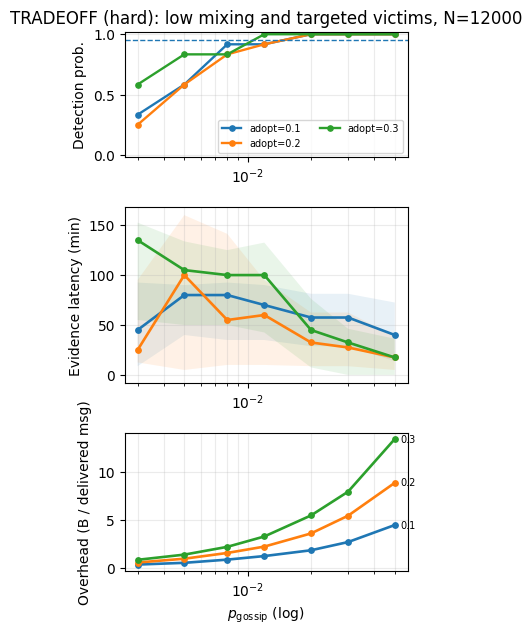

In [41]:
# =========================
# Optional final-paper rerun for smoother medians/IQRs
# =========================

REPS_TRADEOFF_FINAL = 12

df_raw_tradeoff_final = run_grid(
    BASE_TRADEOFF,
    SWEEP_TRADEOFF,
    replicates=REPS_TRADEOFF_FINAL,
    seed_base=SEED_BASE_TRADEOFF,
    outroot=OUT_TRADEOFF / "final_rerun",
    detection_policy="strict",
).copy()

df_raw_tradeoff_final.to_csv(OUT_TRADEOFF / "final_rerun" / "raw.csv", index=False)

df_agg_tradeoff_final = aggregate_runs(df_raw_tradeoff_final, GROUP_COLS_TRADEOFF)
df_agg_tradeoff_final.to_csv(OUT_TRADEOFF / "final_rerun" / "agg.csv", index=False)

df_agg_tradeoff_iqr_final = aggregate_iqr_safe(df_raw_tradeoff_final, GROUP_COLS_TRADEOFF)
df_agg_tradeoff_iqr_final.to_csv(OUT_TRADEOFF / "final_rerun" / "agg_iqr.csv", index=False)

plot_tradeoff_hard(
    df_agg_tradeoff_final,
    df_agg_tradeoff_iqr_final,
    users=12000,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=DET_THR_TRADEOFF,
    outdir=OUT_TRADEOFF / "final_rerun" / "plots",
    stem="fig_tradeoff_hard_three_panel_N12000_final",
)

In [45]:
# =========================
# Final-paper plotter: TRADEOFF (hard)
# Uses final rerun dataframes only
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_TRADEOFF_FINAL = OUT_TRADEOFF / "final_rerun" / "plots_final"
PLOTS_TRADEOFF_FINAL.mkdir(parents=True, exist_ok=True)

def plot_tradeoff_hard_final(
    df_agg_final,
    df_iqr_final,
    users=12000,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=0.95,
    outdir=None,
    stem="fig_tradeoff_hard_three_panel_N12000_finalpaper",
):
    d1 = df_agg_final[df_agg_final["users"] == users].copy()
    if d1.empty:
        raise ValueError(f"No final aggregated rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)

    d2 = None
    if df_iqr_final is not None:
        d2 = df_iqr_final[df_iqr_final["users"] == users].copy()
        if not d2.empty:
            d2["adoption"] = d2["adoption"].astype(float)
            d2["p_gossip"] = d2["p_gossip"].astype(float)
        else:
            d2 = None

    adoption_order = sorted(d1["adoption"].dropna().unique())

    fig = plt.figure(figsize=(3.55, 6.85))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.35, 1.1], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection probability
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=3.8,
                label=f"adopt={a:g}",
            )

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection prob.")
    ax1.set_title(f"{title}, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # -------------------------
    # Panel 2: evidence latency (final)
    # -------------------------
    used_iqr = False
    if d2 is not None and {"lat_ev_med", "lat_ev_q25", "lat_ev_q75"}.issubset(d2.columns):
        for a in adoption_order:
            s = d2[np.isclose(d2["adoption"], a)].sort_values("p_gossip")

            x = s["p_gossip"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            y25 = s["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s["lat_ev_q75"].to_numpy(dtype=float)

            m_band = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
            if m_band.any():
                ax2.fill_between(x[m_band], y25[m_band], y75[m_band], alpha=0.08)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.9,
                    markersize=3.9,
                )
                used_iqr = True

    if not used_iqr and "lat_ev_med" in d1.columns:
        for a in adoption_order:
            s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
            x = s["p_gossip"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.9,
                    markersize=3.9,
                )

    ax2.set_xscale("log")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25, which="both")

    # -------------------------
    # Panel 3: overhead
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["bpd_mean"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.9,
                markersize=3.9,
            )
            ax3.annotate(
                f"{a:g}",
                xy=(x[m][-1], y[m][-1]),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=7,
                va="center",
            )

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\378381007.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\plots_final\fig_tradeoff_hard_three_panel_N12000_finalpaper.pdf


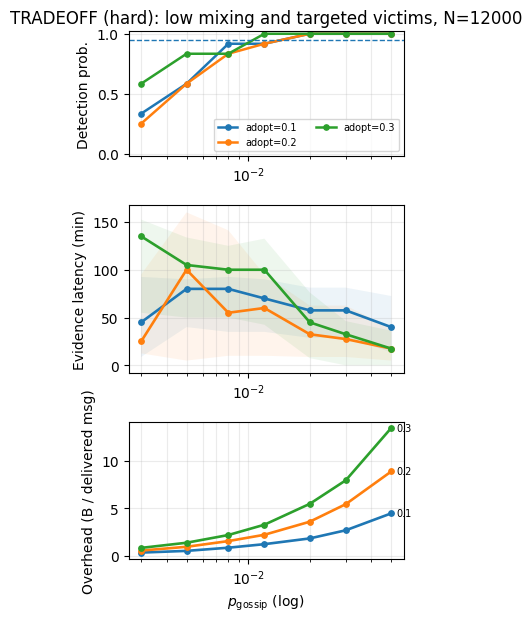

In [46]:
# =========================
# Plot final-paper TRADEOFF figure
# =========================

plot_tradeoff_hard_final(
    df_agg_tradeoff_final,
    df_agg_tradeoff_iqr_final,
    users=12000,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=DET_THR_TRADEOFF,
    outdir=PLOTS_TRADEOFF_FINAL,
    stem="fig_tradeoff_hard_three_panel_N12000_finalpaper",
)

## Alternative middle plot

In [47]:
# =========================
# Build fast-evidence summary from raw final TRADEOFF runs
# Metric: P(latency to evidence <= threshold_min)
# Uses ALL runs, not only successful ones
# =========================

import numpy as np
import pandas as pd

def build_fast_evidence_summary(
    df_raw,
    group_cols,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
):
    work = df_raw.copy()

    if lat_col not in work.columns:
        raise ValueError(f"Expected raw latency column '{lat_col}' in df_raw")

    if det_col not in work.columns:
        raise ValueError(f"Expected detection column '{det_col}' in df_raw")

    # success within threshold:
    # count as 1 only if detection occurred and evidence arrived within threshold
    work["fast_evidence"] = (
        work[det_col].astype(bool) &
        np.isfinite(work[lat_col]) &
        (work[lat_col].astype(float) <= float(threshold_min))
    ).astype(float)

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(
            fast_detect_rate=("fast_evidence", "mean"),
            reps=("run_dir", "count"),
        )
        .reset_index()
    )
    out["threshold_min"] = float(threshold_min)
    return out

GROUP_COLS_TRADEOFF_FAST = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

df_fast_tradeoff_final_60 = build_fast_evidence_summary(
    df_raw_tradeoff_final,
    GROUP_COLS_TRADEOFF_FAST,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_tradeoff_final_60.to_csv(
    OUT_TRADEOFF / "final_rerun" / "fast_evidence_60min.csv",
    index=False,
)

print("Wrote:", (OUT_TRADEOFF / "final_rerun" / "fast_evidence_60min.csv").resolve())
display(df_fast_tradeoff_final_60.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\fast_evidence_60min.csv


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,fast_detect_rate,reps,threshold_min
0,12000,0.1,0.003,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.166667,12,60.0
1,12000,0.1,0.005,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.166667,12,60.0
2,12000,0.1,0.008,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.333333,12,60.0
3,12000,0.1,0.012,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.416667,12,60.0
4,12000,0.1,0.020,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.500000,12,60.0


In [56]:
# =========================
# Build fast-evidence summary from raw final TRADEOFF runs
# Metric: P(latency to evidence <= threshold_min)
# Uses ALL runs, not only successful ones
# =========================

import numpy as np
import pandas as pd

def build_fast_evidence_summary(
    df_raw,
    group_cols,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
):
    work = df_raw.copy()

    if lat_col not in work.columns:
        raise ValueError(f"Expected raw latency column '{lat_col}' in df_raw")

    if det_col not in work.columns:
        raise ValueError(f"Expected detection column '{det_col}' in df_raw")

    # success within threshold:
    # count as 1 only if detection occurred and evidence arrived within threshold
    work["fast_evidence"] = (
        work[det_col].astype(bool) &
        np.isfinite(work[lat_col]) &
        (work[lat_col].astype(float) <= float(threshold_min))
    ).astype(float)

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(
            fast_detect_rate=("fast_evidence", "mean"),
            reps=("run_dir", "count"),
        )
        .reset_index()
    )
    out["threshold_min"] = float(threshold_min)
    return out

GROUP_COLS_TRADEOFF_FAST = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

df_fast_tradeoff_final_60 = build_fast_evidence_summary(
    df_raw_tradeoff_final,
    GROUP_COLS_TRADEOFF_FAST,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_tradeoff_final_60.to_csv(
    OUT_TRADEOFF / "final_rerun" / "fast_evidence_60min.csv",
    index=False,
)

print("Wrote:", (OUT_TRADEOFF / "final_rerun" / "fast_evidence_60min.csv").resolve())
display(df_fast_tradeoff_final_60.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\fast_evidence_60min.csv


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,fast_detect_rate,reps,threshold_min
0,12000,0.1,0.003,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.166667,12,60.0
1,12000,0.1,0.005,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.166667,12,60.0
2,12000,0.1,0.008,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.333333,12,60.0
3,12000,0.1,0.012,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.416667,12,60.0
4,12000,0.1,0.020,permanent_fork,sth_proof,0.02,0.005,0.005,0.0,0.500000,12,60.0


In [55]:
# =========================
# Final-paper TRADEOFF plotter:
# middle panel = probability of evidence within X minutes
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_TRADEOFF_FINAL_FAST = OUT_TRADEOFF / "final_rerun" / "plots_fast"
PLOTS_TRADEOFF_FINAL_FAST.mkdir(parents=True, exist_ok=True)

def plot_tradeoff_hard_final_fast(
    df_agg_final,
    df_fast_final,
    users=12000,
    threshold_min=60.0,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=0.95,
    outdir=None,
    stem="fig_tradeoff_hard_three_panel_fast_N12000_finalpaper",
):
    d1 = df_agg_final[df_agg_final["users"] == users].copy()
    d2 = df_fast_final[df_fast_final["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No final aggregated rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No fast-evidence rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())

    fig = plt.figure(figsize=(3.55, 6.85))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.2, 1.1], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection probability
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=3.8,
                label=f"adopt={a:g}",
            )

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection prob.")
    ax1.set_title(f"{title}, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # -------------------------
    # Panel 2: probability of evidence within threshold_min
    # -------------------------
    for a in adoption_order:
        s = d2[np.isclose(d2["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["fast_detect_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.9,
                markersize=3.9,
            )

    ax2.set_xscale("log")
    ax2.set_ylim(-0.02, 1.02)
    ax2.set_ylabel(f"Evidence within\n{int(threshold_min)} min")
    ax2.grid(True, alpha=0.25, which="both")

    # -------------------------
    # Panel 3: overhead
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["bpd_mean"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.9,
                markersize=3.9,
            )
            ax3.annotate(
                f"{a:g}",
                xy=(x[m][-1], y[m][-1]),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=7,
                va="center",
            )

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\3825069604.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\plots_fast\fig_tradeoff_hard_three_panel_fast60_N12000_finalpaper.pdf


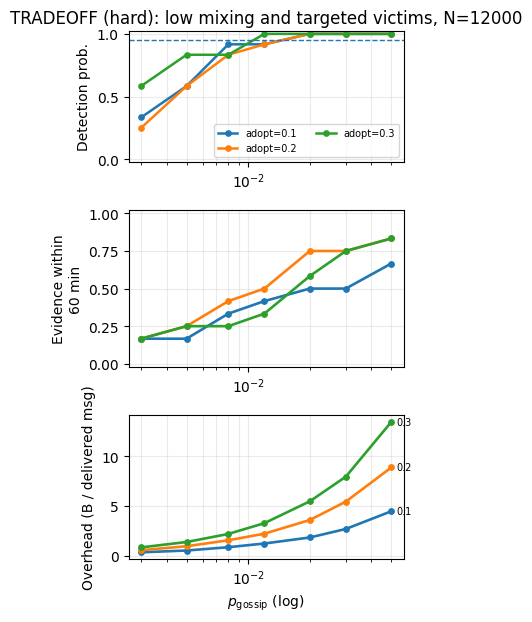

In [57]:
plot_tradeoff_hard_final_fast(
    df_agg_tradeoff_final,
    df_fast_tradeoff_final_60,
    users=12000,
    threshold_min=60.0,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=DET_THR_TRADEOFF,
    outdir=PLOTS_TRADEOFF_FINAL_FAST,
    stem="fig_tradeoff_hard_three_panel_fast60_N12000_finalpaper",
)

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\3825069604.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\final_rerun\plots_fast\fig_tradeoff_hard_three_panel_fast30_N12000_finalpaper.pdf


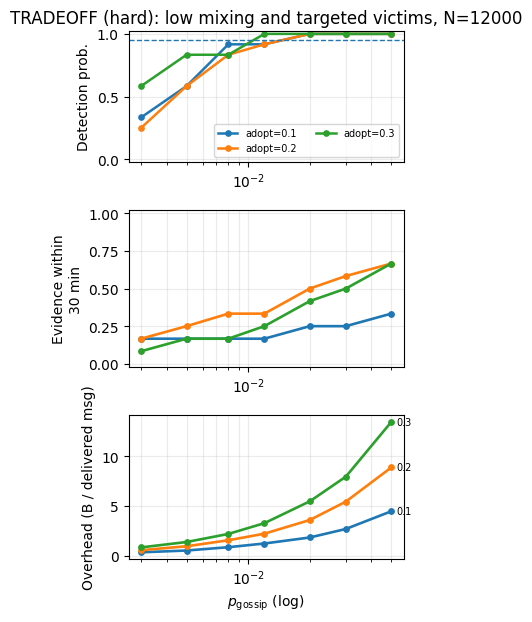

In [58]:
# =========================
# Optional: 30-minute version
# =========================

df_fast_tradeoff_final_30 = build_fast_evidence_summary(
    df_raw_tradeoff_final,
    GROUP_COLS_TRADEOFF_FAST,
    threshold_min=30.0,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_tradeoff_final_30.to_csv(
    OUT_TRADEOFF / "final_rerun" / "fast_evidence_30min.csv",
    index=False,
)

plot_tradeoff_hard_final_fast(
    df_agg_tradeoff_final,
    df_fast_tradeoff_final_30,
    users=12000,
    threshold_min=30.0,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=DET_THR_TRADEOFF,
    outdir=PLOTS_TRADEOFF_FINAL_FAST,
    stem="fig_tradeoff_hard_three_panel_fast30_N12000_finalpaper",
)

In [50]:
# =========================
# Sanity checks: TRADEOFF (hard)
# =========================

print("Unique users:", sorted(df_agg_tradeoff["users"].dropna().unique()))
print("Unique adoption:", sorted(df_agg_tradeoff["adoption"].dropna().unique()))
print("Unique p_gossip:", sorted(df_agg_tradeoff["p_gossip"].dropna().unique()))
print("Unique fork_frac:", sorted(df_agg_tradeoff["fork_frac"].dropna().unique()))
print("Unique p_contact_cross:", sorted(df_agg_tradeoff["p_contact_cross"].dropna().unique()))
print("Unique p_group_cross:", sorted(df_agg_tradeoff["p_group_cross"].dropna().unique()))

tmp_counts_tradeoff = (
    df_raw_tradeoff
    .groupby(["adoption", "p_gossip"], dropna=False)["detected"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .sort_values(["adoption", "p_gossip"])
)
print(tmp_counts_tradeoff.to_string(index=False))

Unique users: [np.int64(12000)]
Unique adoption: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]
Unique p_gossip: [np.float64(0.003), np.float64(0.005), np.float64(0.008), np.float64(0.012), np.float64(0.02), np.float64(0.03), np.float64(0.05)]
Unique fork_frac: [np.float64(0.02)]
Unique p_contact_cross: [np.float64(0.005)]
Unique p_group_cross: [np.float64(0.005)]
 adoption  p_gossip  sum  count  mean
      0.1     0.003    3      8 0.375
      0.1     0.005    5      8 0.625
      0.1     0.008    7      8 0.875
      0.1     0.012    7      8 0.875
      0.1     0.020    8      8 1.000
      0.1     0.030    8      8 1.000
      0.1     0.050    8      8 1.000
      0.2     0.003    2      8 0.250
      0.2     0.005    4      8 0.500
      0.2     0.008    6      8 0.750
      0.2     0.012    7      8 0.875
      0.2     0.020    8      8 1.000
      0.2     0.030    8      8 1.000
      0.2     0.050    8      8 1.000
      0.3     0.003    4      8 0.500
      0.3     0.005 

In [42]:
# =========================
# Plot helper: TRADEOFF (hard), paper-ready 3-panel figure
# =========================

PLOTS_TRADEOFF = OUT_TRADEOFF / "plots"
PLOTS_TRADEOFF.mkdir(parents=True, exist_ok=True)

def plot_tradeoff_hard(
    df_agg,
    df_iqr=None,
    users=12000,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=0.95,
    outdir=None,
    stem="fig_tradeoff_hard_three_panel_N12000",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    if d1.empty:
        raise ValueError(f"No rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)

    d2 = None
    if df_iqr is not None:
        d2 = df_iqr[df_iqr["users"] == users].copy()
        if not d2.empty:
            d2["adoption"] = d2["adoption"].astype(float)
            d2["p_gossip"] = d2["p_gossip"].astype(float)
        else:
            d2 = None

    adoption_order = sorted(d1["adoption"].dropna().unique())

    fig = plt.figure(figsize=(3.65, 7.0))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.4, 1.1], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection probability
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.7,
                markersize=3.8,
                label=f"adopt={a:g}",
            )

    ax1.set_xscale("log")
    ax1.axhline(det_thr, linestyle="--", linewidth=1.0)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detection prob.")
    ax1.set_title(f"{title}, N={users}")
    ax1.grid(True, alpha=0.25, which="both")
    ax1.legend(fontsize=7, frameon=True, ncol=2, loc="lower right")

    # -------------------------
    # Panel 2: evidence latency
    # -------------------------
    used_iqr = False
    if d2 is not None and {"lat_ev_med", "lat_ev_q25", "lat_ev_q75"}.issubset(d2.columns):
        for a in adoption_order:
            s = d2[np.isclose(d2["adoption"], a)].sort_values("p_gossip")

            x = s["p_gossip"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            y25 = s["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s["lat_ev_q75"].to_numpy(dtype=float)

            m_band = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
            if m_band.any():
                ax2.fill_between(x[m_band], y25[m_band], y75[m_band], alpha=0.10)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.9,
                    markersize=3.9,
                )
                used_iqr = True

    if not used_iqr and "lat_ev_med" in d1.columns:
        for a in adoption_order:
            s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
            x = s["p_gossip"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.9,
                    markersize=3.9,
                )

    ax2.set_xscale("log")
    ax2.set_ylabel("Evidence latency (min)")
    ax2.grid(True, alpha=0.25, which="both")

    # -------------------------
    # Panel 3: overhead
    # -------------------------
    for a in adoption_order:
        s = d1[np.isclose(d1["adoption"], a)].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)
        y = s["bpd_mean"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.9,
                markersize=3.9,
            )

            ax3.annotate(
                f"{a:g}",
                xy=(x[m][-1], y[m][-1]),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=7,
                va="center",
            )

    ax3.set_xscale("log")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.grid(True, alpha=0.25, which="both")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\449807907.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_tradeoff_hard\plots\fig_tradeoff_hard_three_panel_N12000.pdf


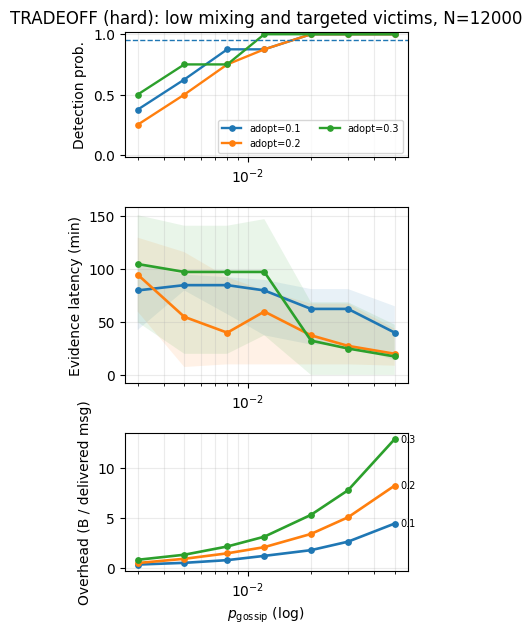

In [44]:
# =========================
# Generate TRADEOFF (hard) figure
# =========================

plot_tradeoff_hard(
    df_agg_tradeoff,
    df_agg_tradeoff_iqr,
    users=12000,
    title="TRADEOFF (hard): low mixing and targeted victims",
    det_thr=DET_THR_TRADEOFF,
    outdir=PLOTS_TRADEOFF,
    stem="fig_tradeoff_hard_three_panel_N12000",
)

##  Scenario 3: TARGET

In [74]:
# =========================
# Scenario 3: Narrow targeting definition
# =========================

OUT_TARGET = OUT_SUITE / "S3_targeting"

BASE_TARGET = dict(BASE_SMALL)
BASE_TARGET.update(
    users=N_USERS,
    hours=HOURS,
    fork_hour=FORK_HOUR,
    fork_duration=FORK_DUR,
    server_mode="permanent_fork",
    mode="sth_proof",
    msg_rate_1to1=MSG_RATE_1to1,
    msg_rate_group=MSG_RATE_GROUP,
    # representative typical mixing level for clean interpretation
    p_contact_cross=0.03,
    p_group_cross=0.03,
    sticky_victims=STICKY_VICTIMS,
    p_drop_crosscut=0.0,
)

SWEEP_TARGET = dict(
    adoption=ADOPT_GRID,
    p_gossip=PG_GRID,
    fork_frac=[0.001, 0.005, 0.01, 0.02, 0.05],
)

GROUP_COLS_TARGET = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

REPS_TARGET = REPS_EXPLORE
SEED_BASE_TARGET = SEED_BASE + 2000
DET_THR_TARGET = DET_THR

In [75]:
# =========================
# Scenario 3: Narrow targeting execution
# =========================

OUT_TARGET.mkdir(parents=True, exist_ok=True)

df_raw_target = run_grid(
    BASE_TARGET,
    SWEEP_TARGET,
    replicates=REPS_TARGET,
    seed_base=SEED_BASE_TARGET,
    outroot=OUT_TARGET,
    detection_policy="strict",
)

df_raw_target.to_csv(OUT_TARGET / "raw.csv", index=False)

df_agg_target = aggregate_iqr_safe(df_raw_target, GROUP_COLS_TARGET).sort_values(
    ["fork_frac", "adoption", "p_gossip"]
)

df_agg_target.to_csv(OUT_TARGET / "agg_iqr_safe.csv", index=False)

print("Wrote raw:", (OUT_TARGET / "raw.csv").resolve())
print("Wrote agg:", (OUT_TARGET / "agg_iqr_safe.csv").resolve())
display(df_raw_target.head())
display(df_agg_target.head(12))

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p001_s32000_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p001_s32000_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p001_s32001_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p001_s32001_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\permanent_fork_sth_proof_n12000_pg0p005_a0p1_ff0p001_s32002_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.001,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.800025,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.001,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.754737,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.001,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.767654,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.001,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.779119,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.1,0.001,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.790943,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.1,0.005,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,0.402510,0.402510,0.000000,0.000000,NaN,NaN,NaN
5,12000,0.1,0.007,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,0.500989,0.500989,0.000000,0.000000,NaN,NaN,NaN
10,12000,0.1,0.010,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,0.720708,0.720708,0.000000,0.000000,NaN,NaN,NaN
15,12000,0.1,0.015,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,1.067015,1.067015,0.000000,0.000000,NaN,NaN,NaN
20,12000,0.1,0.020,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,1.553058,1.553058,0.000000,0.000000,NaN,NaN,NaN
25,12000,0.1,0.030,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,70.0,70.0,70.0,2.528405,2.528405,0.111111,0.111111,NaN,NaN,NaN
30,12000,0.1,0.050,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,70.0,70.0,70.0,4.501622,4.501622,0.111111,0.111111,NaN,NaN,NaN
35,12000,0.2,0.005,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,0.872378,0.872378,0.000000,0.000000,NaN,NaN,NaN
40,12000,0.2,0.007,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,1.212452,1.212452,0.000000,0.000000,NaN,NaN,NaN
45,12000,0.2,0.010,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,9,...,NaN,NaN,NaN,1.677474,1.677474,0.000000,0.000000,NaN,NaN,NaN


In [35]:
# =========================
# Scenario 3: sanity checks
# =========================

print("df_raw_target columns:")
print(sorted(df_raw_target.columns))

print("\ndf_agg_target columns:")
print(sorted(df_agg_target.columns))

show_cols = [
    "fork_frac",
    "adoption",
    "p_gossip",
    "detected_rate",
    "lat_ev_med",
    "lat_ev_q25",
    "lat_ev_q75",
    "bpd_mean",
]

existing = [c for c in show_cols if c in df_agg_target.columns]
display(df_agg_target[existing].head(16))

df_raw_target columns:
['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']

df_agg_target columns:
['adoption', 'bpd_mean', 'bps_mean', 'crosscuts_mean', 'detected_rate', 'evidence_mean', 'fork_frac', 'lat_ev_med', 'lat_ev_q25', 'lat_ev_q75', 'mode', 'msgs_95_ev_med', 'msgs_95_ev_q25', 'msgs_95_ev_q75', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'reps', 'server_mode', 'users']


,fork_frac,adoption,p_gossip,detected_rate,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean
0,0.001,0.1,0.005,0.000000,NaN,NaN,NaN,0.402510
5,0.001,0.1,0.007,0.000000,NaN,NaN,NaN,0.500989
10,0.001,0.1,0.010,0.000000,NaN,NaN,NaN,0.720708
15,0.001,0.1,0.015,0.000000,NaN,NaN,NaN,1.067015
20,0.001,0.1,0.020,0.000000,NaN,NaN,NaN,1.553058
25,0.001,0.1,0.030,0.111111,70.0,70.0,70.0,2.528405
30,0.001,0.1,0.050,0.111111,70.0,70.0,70.0,4.501622
35,0.001,0.2,0.005,0.000000,NaN,NaN,NaN,0.872378
40,0.001,0.2,0.007,0.000000,NaN,NaN,NaN,1.212452
45,0.001,0.2,0.010,0.000000,NaN,NaN,NaN,1.677474


In [36]:
# =========================
# Scenario 3 plotting helper: narrow targeting
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

def plot_targeting_summary(
    df_agg,
    plots_dir,
    det_thr=0.95,
    users=None,
):
    d = df_agg.copy()

    if users is not None and "users" in d.columns:
        d = d[d["users"] == users].copy()

    d["fork_frac"] = d["fork_frac"].astype(float)
    d["adoption"] = d["adoption"].astype(float)
    d["p_gossip"] = d["p_gossip"].astype(float)

    fork_fracs = sorted(d["fork_frac"].dropna().unique())
    if len(fork_fracs) == 0:
        raise ValueError("No fork_frac values found in df_agg")

    fig, axes = plt.subplots(
        3, len(fork_fracs),
        figsize=(4.0 * len(fork_fracs), 8.6),
        sharex="col"
    )

    if len(fork_fracs) == 1:
        axes = np.array(axes).reshape(3, 1)

    for j, ff in enumerate(fork_fracs):
        sub_ff = d[np.isclose(d["fork_frac"], ff)].copy()

        ax_det = axes[0, j]
        ax_lat = axes[1, j]
        ax_thr = axes[2, j]

        # Row 1: detection vs p_gossip
        for a in sorted(sub_ff["adoption"].dropna().unique()):
            s = sub_ff[np.isclose(sub_ff["adoption"], a)].sort_values("p_gossip")
            ax_det.plot(
                s["p_gossip"],
                s["detected_rate"],
                marker="o",
                label=f"adopt={a:g}",
            )

        ax_det.axhline(det_thr, linestyle="--", linewidth=1.0)
        ax_det.set_xscale("log")
        ax_det.set_ylim(-0.02, 1.02)
        ax_det.set_title(f"fork_frac={ff:g}")
        ax_det.grid(True, alpha=0.25, which="both")
        if j == 0:
            ax_det.set_ylabel("Detection prob.")

        # Row 2: latency vs p_gossip
        for a in sorted(sub_ff["adoption"].dropna().unique()):
            s = sub_ff[np.isclose(sub_ff["adoption"], a)].sort_values("p_gossip")
            ax_lat.plot(
                s["p_gossip"],
                s["lat_ev_med"],
                marker="o",
                label=f"adopt={a:g}",
            )

            if "lat_ev_q25" in s.columns and "lat_ev_q75" in s.columns:
                y25 = s["lat_ev_q25"].to_numpy(dtype=float)
                y75 = s["lat_ev_q75"].to_numpy(dtype=float)
                x = s["p_gossip"].to_numpy(dtype=float)
                m = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
                if m.any():
                    ax_lat.fill_between(x[m], y25[m], y75[m], alpha=0.15)

        ax_lat.set_xscale("log")
        ax_lat.grid(True, alpha=0.25, which="both")
        if j == 0:
            ax_lat.set_ylabel("Evidence latency (min)")

        # Row 3: min p_gossip vs adoption at this fork fraction
        rows = []
        for a in sorted(sub_ff["adoption"].dropna().unique()):
            s = sub_ff[np.isclose(sub_ff["adoption"], a)].sort_values("p_gossip")
            good = s[s["detected_rate"] >= det_thr]
            min_pg = float(good["p_gossip"].iloc[0]) if len(good) else np.nan
            rows.append((a, min_pg))

        rows = [(a, pg) for a, pg in rows if np.isfinite(pg)]
        if rows:
            aa = [a for a, _ in rows]
            pp = [pg for _, pg in rows]
            ax_thr.plot(aa, pp, marker="o", linewidth=1.4)

        ax_thr.set_yscale("log")
        ax_thr.grid(True, alpha=0.25, which="both")
        ax_thr.set_xlabel("Adoption")
        if j == 0:
            ax_thr.set_ylabel(r"min $p_{\mathrm{gossip}}$")

    handles, labels = axes[0, -1].get_legend_handles_labels()
    if handles:
        axes[0, -1].legend(handles, labels, fontsize=7, frameon=True, loc="lower right")

    title_users = f", N={users}" if users is not None else ""
    fig.suptitle(f"Narrow targeting{title_users}", y=0.995)
    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    suffix = f"_N{users}" if users is not None else ""
    outbase = plots_dir / f"fig_targeting_summary{suffix}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

In [79]:
# =========================
# Prepare narrow-targeting summary inputs
#  based on:
#   df_raw_narrow
#   df_agg_narrow
#   OUT_NARROW
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_NARROW_SUMMARY = OUT_TARGET / "plots_summary"
PLOTS_NARROW_SUMMARY.mkdir(parents=True, exist_ok=True)

print("Available fork_frac values in df_agg_target:")
print(sorted(df_agg_target["fork_frac"].dropna().unique()))

# Recommended main-paper subset:
# exclude the most degenerate edge case (0.001) from the main figure
FORK_FRACS_NARROW_MAIN = [0.005, 0.01, 0.02, 0.05]

# Representative fixed gossip probability for summary panel(s)
PG_FIXED_NARROW = 0.01

# Reliability target for threshold summary
DET_THR_NARROW = 0.95

# Optional fast-detection threshold
FAST_THRESHOLD_MIN_NARROW = 60.0

Available fork_frac values in df_agg_target:
[np.float64(0.001), np.float64(0.005), np.float64(0.01), np.float64(0.02), np.float64(0.05)]


In [81]:
# =========================
# Build fast-evidence summary for narrow targeting
# Metric: P(latency to evidence <= threshold_min)
# =========================

def build_fast_evidence_summary(
    df_raw,
    group_cols,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
):
    work = df_raw.copy()

    if lat_col not in work.columns:
        raise ValueError(f"Expected raw latency column '{lat_col}' in df_raw")

    if det_col not in work.columns:
        raise ValueError(f"Expected detection column '{det_col}' in df_raw")

    work["fast_evidence"] = (
        work[det_col].astype(bool) &
        np.isfinite(work[lat_col]) &
        (work[lat_col].astype(float) <= float(threshold_min))
    ).astype(float)

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(
            fast_detect_rate=("fast_evidence", "mean"),
            reps=("run_dir", "count"),
        )
        .reset_index()
    )
    out["threshold_min"] = float(threshold_min)
    return out

GROUP_COLS_NARROW_FAST = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

df_fast_narrow_60 = build_fast_evidence_summary(
    df_raw_target,
    GROUP_COLS_NARROW_FAST,
    threshold_min=FAST_THRESHOLD_MIN_NARROW,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_narrow_60.to_csv(OUT_TARGET / "fast_evidence_60min.csv", index=False)

print("Wrote:", (OUT_TARGET / "fast_evidence_60min.csv").resolve())
display(df_fast_narrow_60.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\fast_evidence_60min.csv


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,fast_detect_rate,reps,threshold_min
0,12000,0.1,0.005,permanent_fork,sth_proof,0.001,0.03,0.03,0.0,0.000000,9,60.0
1,12000,0.1,0.005,permanent_fork,sth_proof,0.005,0.03,0.03,0.0,0.000000,9,60.0
2,12000,0.1,0.005,permanent_fork,sth_proof,0.010,0.03,0.03,0.0,0.111111,9,60.0
3,12000,0.1,0.005,permanent_fork,sth_proof,0.020,0.03,0.03,0.0,0.111111,9,60.0
4,12000,0.1,0.005,permanent_fork,sth_proof,0.050,0.03,0.03,0.0,0.222222,9,60.0


In [82]:
# =========================
# Helpers for narrow-targeting summary figure
# =========================

def isotonic_fit_monotone(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size == 0:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x, y = x[order], y[order]

    levels = y.copy()
    weights = np.ones_like(levels)

    i = 0
    while i < len(levels) - 1:
        if levels[i] <= levels[i + 1]:
            i += 1
            continue

        new_level = (
            levels[i] * weights[i] + levels[i + 1] * weights[i + 1]
        ) / (weights[i] + weights[i + 1])

        levels[i] = new_level
        weights[i] += weights[i + 1]

        levels = np.delete(levels, i + 1)
        weights = np.delete(weights, i + 1)
        x = np.delete(x, i + 1)

        i = max(i - 1, 0)

    return x, levels


def min_pg_for_threshold(x_step, y_step, thr=0.95):
    if len(x_step) == 0:
        return np.nan
    for xi, yi in zip(x_step, y_step):
        if yi >= thr:
            return float(xi)
    return np.nan

In [90]:
# =========================
# Narrow targeting: old-style paper figure
# Fixed adoption, vary victim fraction f, one line per p_gossip
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_NARROW_OLDSTYLE = OUT_TARGET / "plots_oldstyle"
PLOTS_NARROW_OLDSTYLE.mkdir(parents=True, exist_ok=True)

USERS_NARROW_OLDSTYLE = 12000
ADOPTION_FIXED_NARROW = 0.20

# Use the non-degenerate fork fractions that read well in a paper figure
FORK_FRACS_NARROW_OLDSTYLE = [0.01, 0.02, 0.05, 0.10]

# Representative gossip rates
PG_LINES_NARROW_OLDSTYLE = [0.01, 0.03, 0.05]

print("Available fork_frac values:", sorted(df_agg_target["fork_frac"].dropna().unique()))
print("Available p_gossip values:", sorted(df_agg_target["p_gossip"].dropna().unique()))
print("Available adoption values:", sorted(df_agg_target["adoption"].dropna().unique()))

Available fork_frac values: [np.float64(0.001), np.float64(0.005), np.float64(0.01), np.float64(0.02), np.float64(0.05)]
Available p_gossip values: [np.float64(0.005), np.float64(0.007), np.float64(0.01), np.float64(0.015), np.float64(0.02), np.float64(0.03), np.float64(0.05)]
Available adoption values: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]


In [91]:
# =========================
# Plot helper: narrow targeting old-style
# Top: detection probability vs victim fraction
# Bottom: evidence latency vs victim fraction
# =========================

def plot_narrow_oldstyle(
    df_agg,
    df_iqr=None,
    users=12000,
    adoption_fixed=0.20,
    fork_fracs=None,
    pg_lines=None,
    outdir=None,
    stem="fig_narrow_oldstyle_latency",
    title="TARGET Effect of the targeted victim fraction $f$ on split-view detection",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    if d1.empty:
        raise ValueError(f"No rows found for users={users}")

    d1["fork_frac"] = d1["fork_frac"].astype(float)
    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)

    d1 = d1[np.isclose(d1["adoption"], adoption_fixed)].copy()

    d2 = None
    if df_iqr is not None:
        d2 = df_iqr[df_iqr["users"] == users].copy()
        if not d2.empty:
            d2["fork_frac"] = d2["fork_frac"].astype(float)
            d2["adoption"] = d2["adoption"].astype(float)
            d2["p_gossip"] = d2["p_gossip"].astype(float)
            d2 = d2[np.isclose(d2["adoption"], adoption_fixed)].copy()
        else:
            d2 = None

    if fork_fracs is None:
        fork_fracs = sorted(d1["fork_frac"].dropna().unique())
    fork_fracs = [float(x) for x in fork_fracs]

    if pg_lines is None:
        pg_lines = sorted(d1["p_gossip"].dropna().unique())
    pg_lines = [float(x) for x in pg_lines]

    d1 = d1[d1["fork_frac"].isin(fork_fracs)].copy()
    if d2 is not None:
        d2 = d2[d2["fork_frac"].isin(fork_fracs)].copy()

    fig, axes = plt.subplots(2, 1, figsize=(4.1, 5.6), sharex=True)
    fig.suptitle(f"{title}, N={users}", y=1.02, fontsize=14)

    ax1, ax2 = axes

    # -------------------------
    # Top: detection probability
    # -------------------------
    for pg in pg_lines:
        s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("fork_frac")
        x = s["fork_frac"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=4.0,
                label=fr"$p_g$={pg:g}",
            )

    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detect. prob.")
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8, frameon=True, ncol=2, loc="lower left")

    # -------------------------
    # Bottom: latency (median ± IQR if available)
    # -------------------------
    used_iqr = False
    if d2 is not None and {"lat_ev_med", "lat_ev_q25", "lat_ev_q75"}.issubset(d2.columns):
        for pg in pg_lines:
            s = d2[np.isclose(d2["p_gossip"], pg)].sort_values("fork_frac")
            x = s["fork_frac"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            y25 = s["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s["lat_ev_q75"].to_numpy(dtype=float)

            m_band = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
            if m_band.any():
                ax2.fill_between(x[m_band], y25[m_band], y75[m_band], alpha=0.10)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.8,
                    markersize=4.0,
                )
                used_iqr = True

    if not used_iqr and "lat_ev_med" in d1.columns:
        for pg in pg_lines:
            s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("fork_frac")
            x = s["fork_frac"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.8,
                    markersize=4.0,
                )

    ax2.set_ylabel("Latency (min)")
    ax2.set_xlabel(r"Victim fraction $f$")
    ax2.grid(True, alpha=0.25)

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\plots_oldstyle\fig_narrow_oldstyle_latency_N12000_a02.pdf


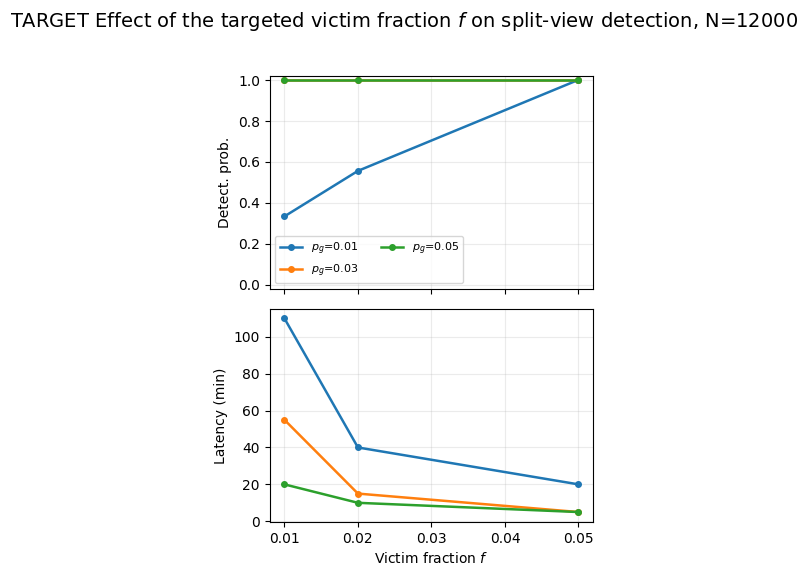

In [93]:
# =========================
# Generate old-style narrow-target figure
# =========================

plot_narrow_oldstyle(
    df_agg_target,
    df_agg_target_iqr if "df_agg_narrow_iqr" in globals() else None,
    users=USERS_NARROW_OLDSTYLE,
    adoption_fixed=ADOPTION_FIXED_NARROW,
    fork_fracs=FORK_FRACS_NARROW_OLDSTYLE,
    pg_lines=PG_LINES_NARROW_OLDSTYLE,
    outdir=PLOTS_NARROW_OLDSTYLE,
    stem="fig_narrow_oldstyle_latency_N12000_a02",
)

In [94]:
# =========================
# Optional: old-style narrow-target figure with fast-evidence bottom panel
# Assumes df_fast_narrow_60 already exists
# =========================

def plot_narrow_oldstyle_fast(
    df_agg,
    df_fast,
    users=12000,
    adoption_fixed=0.20,
    fork_fracs=None,
    pg_lines=None,
    threshold_min=60.0,
    outdir=None,
    stem="fig_narrow_oldstyle_fast60",
    title="TARGET Effect of the targeted victim fraction $f$ on split-view detection",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_fast[df_fast["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No fast-evidence rows found for users={users}")

    d1["fork_frac"] = d1["fork_frac"].astype(float)
    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1 = d1[np.isclose(d1["adoption"], adoption_fixed)].copy()

    d2["fork_frac"] = d2["fork_frac"].astype(float)
    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2 = d2[np.isclose(d2["adoption"], adoption_fixed)].copy()

    if fork_fracs is None:
        fork_fracs = sorted(d1["fork_frac"].dropna().unique())
    fork_fracs = [float(x) for x in fork_fracs]

    if pg_lines is None:
        pg_lines = sorted(d1["p_gossip"].dropna().unique())
    pg_lines = [float(x) for x in pg_lines]

    d1 = d1[d1["fork_frac"].isin(fork_fracs)].copy()
    d2 = d2[d2["fork_frac"].isin(fork_fracs)].copy()

    fig, axes = plt.subplots(2, 1, figsize=(4.1, 5.6), sharex=True)
    fig.suptitle(f"{title}, N={users}", y=1.02, fontsize=14)

    ax1, ax2 = axes

    for pg in pg_lines:
        s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("fork_frac")
        x = s["fork_frac"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=4.0,
                label=fr"$p_g$={pg:g}",
            )

    ax1.set_ylim(-0.02, 1.02)
    ax1.set_ylabel("Detect. prob.")
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8, frameon=True, ncol=2, loc="lower left")

    for pg in pg_lines:
        s = d2[np.isclose(d2["p_gossip"], pg)].sort_values("fork_frac")
        x = s["fork_frac"].to_numpy(dtype=float)
        y = s["fast_detect_rate"].to_numpy(dtype=float)
        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax2.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=4.0,
            )

    ax2.set_ylim(-0.02, 1.02)
    ax2.set_ylabel(f"Evidence within\n{int(threshold_min)} min")
    ax2.set_xlabel(r"Victim fraction $f$")
    ax2.grid(True, alpha=0.25)

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_targeting\plots_oldstyle\fig_narrow_oldstyle_fast60_N12000_a02.pdf


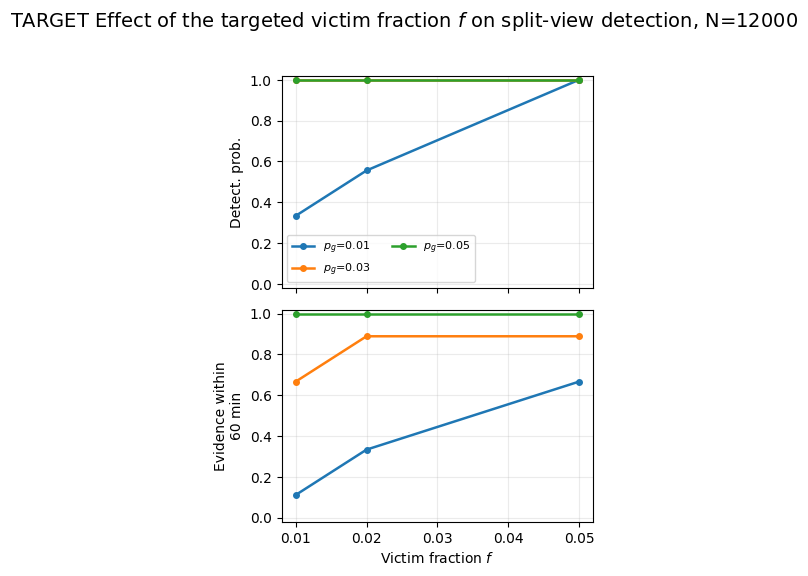

In [95]:
# Call this only if df_fast_narrow_60 exists
if "df_fast_narrow_60" in globals():
    plot_narrow_oldstyle_fast(
        df_agg_target,
        df_fast_narrow_60,
        users=USERS_NARROW_OLDSTYLE,
        adoption_fixed=ADOPTION_FIXED_NARROW,
        fork_fracs=FORK_FRACS_NARROW_OLDSTYLE,
        pg_lines=PG_LINES_NARROW_OLDSTYLE,
        threshold_min=60.0,
        outdir=PLOTS_NARROW_OLDSTYLE,
        stem="fig_narrow_oldstyle_fast60_N12000_a02",
    )
else:
    print("df_fast_narrow_60 is not defined yet.")

## SCENARIO 4 CENSOR

In [66]:
# =========================
# Scenario 4: Censorship / cross-cut suppression definition
# =========================

OUT_CENSOR = OUT_SUITE / "S4_censor"

BASE_CENSOR = dict(BASE_SMALL)
BASE_CENSOR.update(
    users=N_USERS,
    hours=HOURS,
    fork_hour=FORK_HOUR,
    fork_duration=FORK_DUR,
    server_mode="permanent_fork",
    mode="sth_proof",
    msg_rate_1to1=MSG_RATE_1to1,
    msg_rate_group=MSG_RATE_GROUP,
    fork_frac=FORK_FRAC_TYP,
    sticky_victims=STICKY_VICTIMS,
    # representative typical mixing, so the censorship effect is isolated
    p_contact_cross=0.03,
    p_group_cross=0.03,
)

SWEEP_CENSOR = dict(
    adoption=[0.10, 0.20, 0.30],
    p_gossip=[0.01, 0.02, 0.03, 0.05],
    p_drop_crosscut=[0.0, 0.25, 0.50, 0.75, 1.0],
)

GROUP_COLS_CENSOR = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

REPS_CENSOR = REPS_EXPLORE
SEED_BASE_CENSOR = SEED_BASE + 3000
DET_THR_CENSOR = DET_THR

In [68]:
# =========================
# Scenario 4: Censorship / cross-cut suppression execution
# =========================

OUT_CENSOR.mkdir(parents=True, exist_ok=True)

df_raw_censor = run_grid(
    BASE_CENSOR,
    SWEEP_CENSOR,
    replicates=REPS_CENSOR,
    seed_base=SEED_BASE_CENSOR,
    outroot=OUT_CENSOR,
    detection_policy="strict",
)

df_raw_censor.to_csv(OUT_CENSOR / "raw.csv", index=False)

df_agg_censor = aggregate_iqr_safe(df_raw_censor, GROUP_COLS_CENSOR).sort_values(
    ["p_drop_crosscut", "adoption", "p_gossip"]
)

df_agg_censor.to_csv(OUT_CENSOR / "agg_iqr_safe.csv", index=False)

print("Wrote raw:", (OUT_CENSOR / "raw.csv").resolve())
print("Wrote agg:", (OUT_CENSOR / "agg_iqr_safe.csv").resolve())
display(df_raw_censor.head())
display(df_agg_censor.head(12))

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\permanent_fork_sth_proof_n12000_pg0p01_a0p1_ff0p05_s33000_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\permanent_fork_sth_proof_n12000_pg0p01_a0p1_ff0p05_s33000_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\permanent_fork_sth_proof_n12000_pg0p01_a0p1_ff0p05_s33001_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\permanent_fork_sth_proof_n12000_pg0p01_a0p1_ff0p05_s33001_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\permanent_fork_sth_proof_n12000_pg0p01_a0p1_ff0p05_s33002_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_inc

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.873165,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.842370,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.813998,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.832701,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.1,0.05,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.834575,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,30.0,15.0,60.0,0.902232,0.902232,3.888889,3.888889,NaN,NaN,NaN
5,12000,0.1,0.02,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,15.0,10.0,30.0,1.815334,1.815334,6.000000,6.000000,NaN,NaN,NaN
10,12000,0.1,0.03,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,15.0,10.0,30.0,2.685191,2.685191,7.777778,7.777778,NaN,NaN,NaN
15,12000,0.1,0.05,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,15.0,10.0,30.0,4.652905,4.652905,15.222222,15.222222,NaN,NaN,NaN
20,12000,0.2,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,35.0,25.0,45.0,1.898209,1.898209,7.222222,7.222222,NaN,NaN,NaN
25,12000,0.2,0.02,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,15.0,0.0,25.0,3.772784,3.772784,15.666667,15.666667,NaN,NaN,NaN
30,12000,0.2,0.03,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,10.0,0.0,20.0,5.928344,5.928344,26.333333,26.333333,NaN,NaN,NaN
35,12000,0.2,0.05,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,0.0,0.0,15.0,9.707473,9.707473,40.444444,40.444444,NaN,NaN,NaN
40,12000,0.3,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,40.0,25.0,50.0,2.884164,2.884164,10.888889,10.888889,NaN,NaN,NaN
45,12000,0.3,0.02,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,9,...,25.0,20.0,25.0,5.727821,5.727821,23.888889,23.888889,NaN,NaN,NaN


In [14]:
# =========================
# Scenario 4: sanity checks
# =========================

print("df_raw_censor columns:")
print(sorted(df_raw_censor.columns))

print("\ndf_agg_censor columns:")
print(sorted(df_agg_censor.columns))

show_cols = [
    "p_drop_crosscut",
    "adoption",
    "p_gossip",
    "detected_rate",
    "lat_ev_med",
    "lat_ev_q25",
    "lat_ev_q75",
    "bpd_mean",
    "crosscuts_mean",
]

existing = [c for c in show_cols if c in df_agg_censor.columns]
display(df_agg_censor[existing].head(16))

df_raw_censor columns:
['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']

df_agg_censor columns:
['adoption', 'bpd_mean', 'bps_mean', 'crosscuts_mean', 'detected_rate', 'evidence_mean', 'fork_frac', 'lat_ev_med', 'lat_ev_q25', 'lat_ev_q75', 'mode', 'msgs_95_ev_med', 'msgs_95_ev_q25', 'msgs_95_ev_q75', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'reps', 'server_mode', 'users']


,p_drop_crosscut,adoption,p_gossip,detected_rate,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,crosscuts_mean
0,0.00,0.1,0.01,1.000000,30.0,15.0,60.00,0.902232,3.888889
5,0.00,0.1,0.02,1.000000,15.0,10.0,30.00,1.815334,6.000000
10,0.00,0.1,0.03,1.000000,15.0,10.0,30.00,2.685191,7.777778
15,0.00,0.1,0.05,1.000000,15.0,10.0,30.00,4.652905,15.222222
20,0.00,0.2,0.01,1.000000,35.0,25.0,45.00,1.898209,7.222222
25,0.00,0.2,0.02,1.000000,15.0,0.0,25.00,3.772784,15.666667
30,0.00,0.2,0.03,1.000000,10.0,0.0,20.00,5.928344,26.333333
35,0.00,0.2,0.05,1.000000,0.0,0.0,15.00,9.707473,40.444444
40,0.00,0.3,0.01,1.000000,40.0,25.0,50.00,2.884164,10.888889
45,0.00,0.3,0.02,1.000000,25.0,20.0,25.00,5.727821,23.888889


In [17]:
# =========================
# Scenario 4 plotting helper: censorship / cross-cut suppression
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def plot_censor_for_users(
    df_agg,
    users,
    plots_dir,
    adoption_order=None,
):
    dU = df_agg[df_agg["users"] == users].copy()
    dU["adoption"] = dU["adoption"].astype(float)
    dU["p_gossip"] = dU["p_gossip"].astype(float)
    dU["p_drop_crosscut"] = dU["p_drop_crosscut"].astype(float)

    if adoption_order is None:
        adoption_order = sorted(dU["adoption"].dropna().unique())

    fig, axes = plt.subplots(
        3, len(adoption_order),
        figsize=(4.1 * len(adoption_order), 8.0),
        sharex="col"
    )

    if len(adoption_order) == 1:
        axes = np.array(axes).reshape(3, 1)

    for j, a in enumerate(adoption_order):
        sub_a = dU[np.isclose(dU["adoption"], a)].copy()

        ax_det = axes[0, j]
        ax_lat = axes[1, j]
        ax_ovh = axes[2, j]

        # Row 1: detection vs censorship
        for pg in sorted(sub_a["p_gossip"].dropna().unique()):
            s = sub_a[np.isclose(sub_a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            ax_det.plot(
                s["p_drop_crosscut"],
                s["detected_rate"],
                marker="o",
                label=fr"$p_g$={pg:g}",
            )

        ax_det.set_ylim(-0.02, 1.02)
        ax_det.set_title(f"adoption={a:g}")
        ax_det.grid(True, alpha=0.25)
        if j == 0:
            ax_det.set_ylabel("Detection probability")

        # Row 2: latency vs censorship
        for pg in sorted(sub_a["p_gossip"].dropna().unique()):
            s = sub_a[np.isclose(sub_a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            ax_lat.plot(
                s["p_drop_crosscut"],
                s["lat_ev_med"],
                marker="o",
                label=fr"$p_g$={pg:g}",
            )

            if "lat_ev_q25" in s.columns and "lat_ev_q75" in s.columns:
                x = s["p_drop_crosscut"].to_numpy(dtype=float)
                y25 = s["lat_ev_q25"].to_numpy(dtype=float)
                y75 = s["lat_ev_q75"].to_numpy(dtype=float)
                m = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
                if m.any():
                    ax_lat.fill_between(x[m], y25[m], y75[m], alpha=0.15)

        ax_lat.grid(True, alpha=0.25)
        if j == 0:
            ax_lat.set_ylabel("Evidence latency (min)")

        # Row 3: overhead vs censorship
        for pg in sorted(sub_a["p_gossip"].dropna().unique()):
            s = sub_a[np.isclose(sub_a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            ax_ovh.plot(
                s["p_drop_crosscut"],
                s["bpd_mean"],
                marker="o",
                label=fr"$p_g$={pg:g}",
            )

        ax_ovh.grid(True, alpha=0.25)
        ax_ovh.set_xlabel("Crosscut drop prob.")
        if j == 0:
            ax_ovh.set_ylabel("Overhead (B / delivered msg)")

    handles, labels = axes[0, -1].get_legend_handles_labels()
    if handles:
        axes[0, -1].legend(handles, labels, fontsize=7, frameon=True, loc="lower left")

    fig.suptitle(f"Censorship / cross-cut suppression, N={users}", y=0.995)
    fig.tight_layout()

    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)
    outbase = plots_dir / f"fig_censor_N{users}"

    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

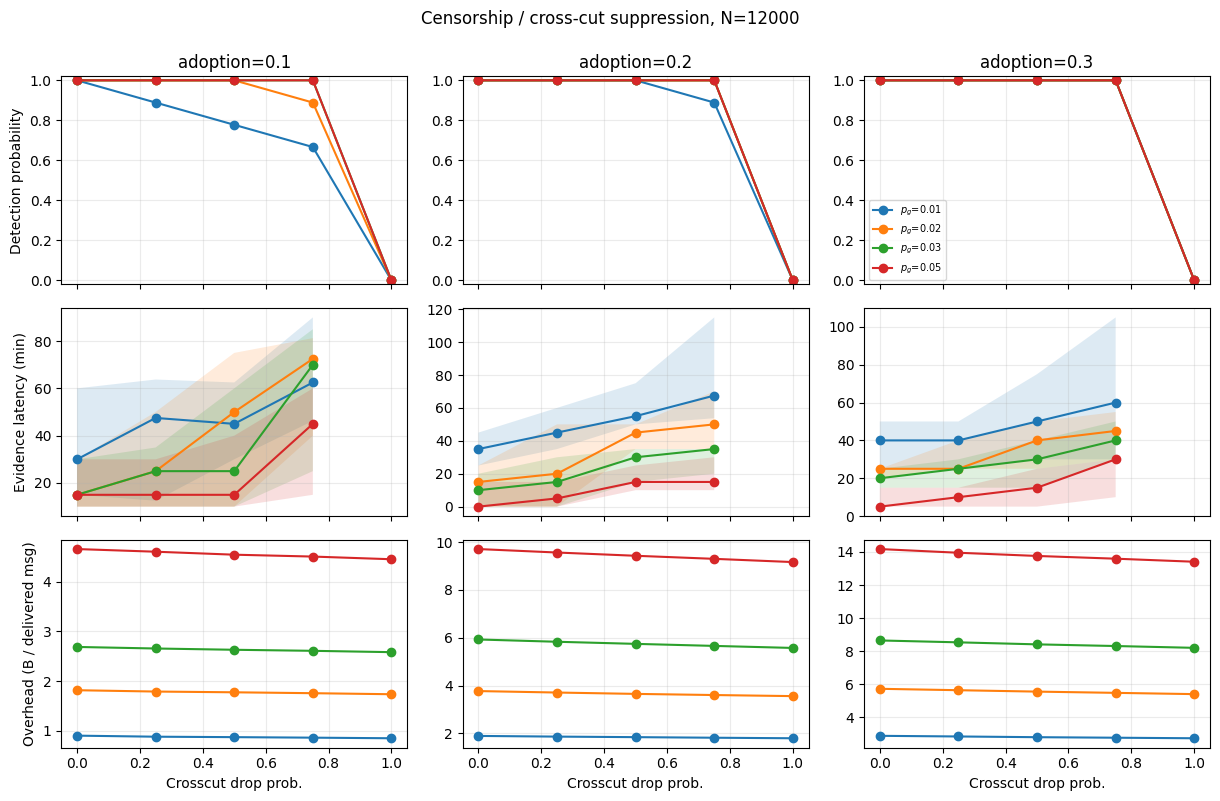

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots\fig_censor_N12000.pdf


In [42]:
# =========================
# Scenario 4: censorship / cross-cut suppression plots
# =========================

PLOTS_CENSOR = OUT_CENSOR / "plots"
PLOTS_CENSOR.mkdir(parents=True, exist_ok=True)

for U in sorted(df_agg_censor["users"].dropna().unique()):
    plot_censor_for_users(
        df_agg_censor,
        users=int(U),
        plots_dir=PLOTS_CENSOR,
    )

In [106]:
# =========================
# Build censored-latency summary for censorship scenario
# latency_censored_min =
#   lat_ev_min if detected
#   timeout_min otherwise
# =========================

import numpy as np
import pandas as pd

def build_censored_latency_summary(
    df_raw,
    group_cols,
    timeout_min=120.0,
    lat_col="lat_ev_min",
    det_col="detected",
):
    work = df_raw.copy()

    if lat_col not in work.columns:
        raise ValueError(f"Expected raw latency column '{lat_col}' in df_raw")
    if det_col not in work.columns:
        raise ValueError(f"Expected detection column '{det_col}' in df_raw")

    work["latency_censored_min"] = np.where(
        work[det_col].astype(bool) & np.isfinite(work[lat_col]),
        work[lat_col].astype(float),
        float(timeout_min),
    )

    def q25(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return float(np.quantile(x, 0.25)) if x.size else np.nan

    def q75(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return float(np.quantile(x, 0.75)) if x.size else np.nan

    def med(x):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        return float(np.median(x)) if x.size else np.nan

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(
            lat_cens_med=("latency_censored_min", med),
            lat_cens_q25=("latency_censored_min", q25),
            lat_cens_q75=("latency_censored_min", q75),
            reps=("run_dir", "count"),
        )
        .reset_index()
    )
    out["timeout_min"] = float(timeout_min)
    return out

GROUP_COLS_CENSOR_CENS = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

# choose one:
# timeout_min = 120 for "during the fork"
# timeout_min = 180 for "by end of run" if fork at 3h and run ends at 6h
TIMEOUT_MIN_CENSOR = 120.0

df_censlat_censor = build_censored_latency_summary(
    df_raw_censor,
    GROUP_COLS_CENSOR_CENS,
    timeout_min=TIMEOUT_MIN_CENSOR,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_censlat_censor.to_csv(
    OUT_CENSOR / f"censored_latency_{int(TIMEOUT_MIN_CENSOR)}min.csv",
    index=False,
)

print("Wrote:", (OUT_CENSOR / f"censored_latency_{int(TIMEOUT_MIN_CENSOR)}min.csv").resolve())
display(df_censlat_censor.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\censored_latency_120min.csv


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,lat_cens_med,lat_cens_q25,lat_cens_q75,reps,timeout_min
0,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.00,30.0,15.0,60.0,9,120.0
1,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.25,50.0,15.0,75.0,9,120.0
2,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.50,50.0,45.0,95.0,9,120.0
3,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.75,95.0,50.0,120.0,9,120.0
4,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,1.00,120.0,120.0,120.0,9,120.0


In [107]:
# =========================
# Censorship figure with censored-latency middle row
# Full x-axis lines in the middle panel
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_CENSOR_CENSLAT = OUT_CENSOR / "plots_censored_latency"
PLOTS_CENSOR_CENSLAT.mkdir(parents=True, exist_ok=True)

def plot_censor_censored_latency(
    df_agg,
    df_censlat,
    users=12000,
    timeout_min=120.0,
    title="Censorship via cross-cut suppression",
    outdir=None,
    stem="fig_censor_censored_latency",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_censlat[df_censlat["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No aggregated rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No censored-latency rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())
    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.5, 8.0), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption"], a)].copy()
        d2a = d2[np.isclose(d2["adoption"], a)].copy()

        for pg in pg_order:
            s1 = d1a[np.isclose(d1a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            s2 = d2a[np.isclose(d2a["p_gossip"], pg)].sort_values("p_drop_crosscut")

            x1 = s1["p_drop_crosscut"].to_numpy(dtype=float)
            y_det = s1["detected_rate"].to_numpy(dtype=float)
            y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

            x2 = s2["p_drop_crosscut"].to_numpy(dtype=float)
            y_lat = s2["lat_cens_med"].to_numpy(dtype=float)
            y25 = s2["lat_cens_q25"].to_numpy(dtype=float)
            y75 = s2["lat_cens_q75"].to_numpy(dtype=float)

            lab = fr"$p_g$={pg:g}"

            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
            if m_band.any():
                ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.10)

            m_lat = np.isfinite(x2) & np.isfinite(y_lat)
            if m_lat.any():
                ax_mid.plot(x2[m_lat], y_lat[m_lat], marker="o", linewidth=1.8, markersize=5)

            m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
            if m_ovh.any():
                ax_bot.plot(x1[m_ovh], y_ovh[m_ovh], marker="o", linewidth=1.8, markersize=5)

        for ax in (ax_top, ax_mid, ax_bot):
            ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
            ax.grid(True, alpha=0.25)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)

        ax_mid.set_ylim(-2, timeout_min + 5)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel(f"Censored latency\n(min, cap={int(timeout_min)})")
            ax_bot.set_ylabel("Overhead (B / delivered msg)")

        ax_bot.set_xlabel("Cross-cut drop probability")

    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower left")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_censored_latency\fig_censor_censored_latency_120min_N12000.pdf


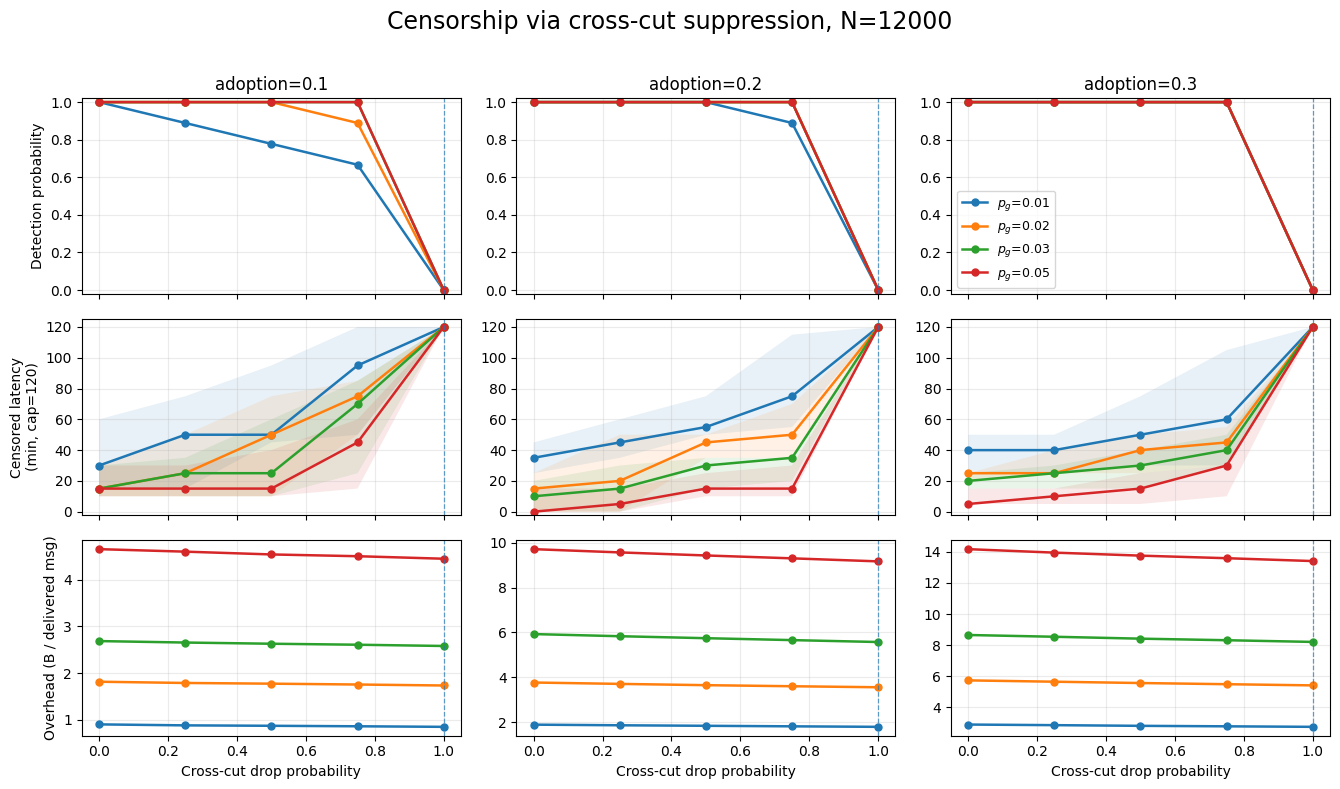

In [108]:
# =========================
# Generate censorship figure with full-x-axis middle row
# =========================

plot_censor_censored_latency(
    df_agg_censor,
    df_censlat_censor,
    users=12000,
    timeout_min=TIMEOUT_MIN_CENSOR,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_CENSLAT,
    stem=f"fig_censor_censored_latency_{int(TIMEOUT_MIN_CENSOR)}min_N12000",
)

In [109]:
# =========================
# Single-adoption censorship figure
# adoption fixed (default 0.1)
# Panels: detection / evidence within 60 min / overhead
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_CENSOR_SINGLE = OUT_CENSOR / "plots_single_adoption"
PLOTS_CENSOR_SINGLE.mkdir(parents=True, exist_ok=True)

def plot_censor_single_adoption(
    df_agg,
    df_fast,
    users=12000,
    adoption_fixed=0.10,
    threshold_min=60.0,
    title="Censorship via cross-cut suppression",
    outdir=None,
    stem="fig_censor_single_adoption_fast60",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_fast[df_fast["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No aggregated rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No fast-evidence rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)

    d1 = d1[np.isclose(d1["adoption"], adoption_fixed)].copy()
    d2 = d2[np.isclose(d2["adoption"], adoption_fixed)].copy()

    if d1.empty or d2.empty:
        raise ValueError(f"No rows found for adoption={adoption_fixed}")

    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig = plt.figure(figsize=(3.7, 6.8))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.1, 1.0], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    for pg in pg_order:
        s1 = d1[np.isclose(d1["p_gossip"], pg)].sort_values("p_drop_crosscut")
        s2 = d2[np.isclose(d2["p_gossip"], pg)].sort_values("p_drop_crosscut")

        x1 = s1["p_drop_crosscut"].to_numpy(dtype=float)
        y_det = s1["detected_rate"].to_numpy(dtype=float)
        y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

        x2 = s2["p_drop_crosscut"].to_numpy(dtype=float)
        y_fast = s2["fast_detect_rate"].to_numpy(dtype=float)

        lab = fr"$p_g$={pg:g}"

        m1 = np.isfinite(x1) & np.isfinite(y_det)
        if m1.any():
            ax1.plot(x1[m1], y_det[m1], marker="o", linewidth=1.8, markersize=4.5, label=lab)

        m2 = np.isfinite(x2) & np.isfinite(y_fast)
        if m2.any():
            ax2.plot(x2[m2], y_fast[m2], marker="o", linewidth=1.8, markersize=4.5)

        m3 = np.isfinite(x1) & np.isfinite(y_ovh)
        if m3.any():
            ax3.plot(x1[m3], y_ovh[m3], marker="o", linewidth=1.8, markersize=4.5)

    for ax in (ax1, ax2, ax3):
        ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
        ax.grid(True, alpha=0.25)

    ax1.set_ylim(-0.02, 1.02)
    ax2.set_ylim(-0.02, 1.02)

    ax1.set_title(f"{title}, N={users}, adoption={adoption_fixed:g}")
    ax1.set_ylabel("Detection probability")
    ax2.set_ylabel(f"Evidence within\n{int(threshold_min)} min")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.set_xlabel("Cross-cut drop probability")

    ax1.legend(fontsize=8, frameon=True, loc="lower left")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\2888850066.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_single_adoption\fig_censor_single_adoption_a01_fast60.pdf


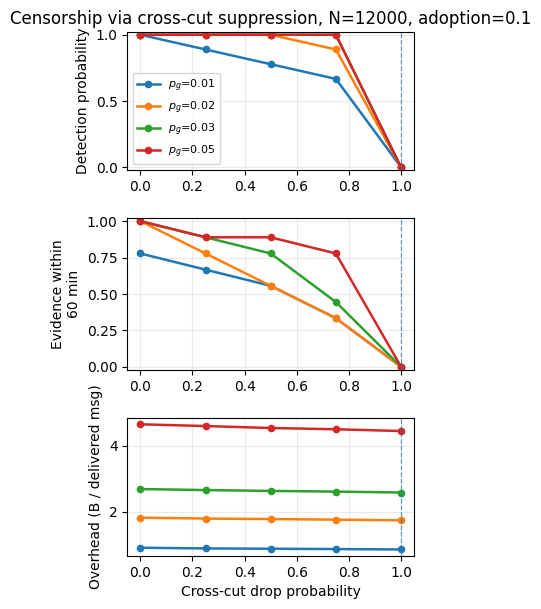

In [110]:
plot_censor_single_adoption(
    df_agg_censor,
    df_fast_censor_60,
    users=12000,
    adoption_fixed=0.10,
    threshold_min=60.0,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_SINGLE,
    stem="fig_censor_single_adoption_a01_fast60",
)

In [111]:
# =========================
# Single-adoption censorship figure
# Panels: detection / latency / overhead
# adoption fixed (default 0.1)
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_CENSOR_SINGLE_LAT = OUT_CENSOR / "plots_single_adoption_latency"
PLOTS_CENSOR_SINGLE_LAT.mkdir(parents=True, exist_ok=True)

def plot_censor_single_adoption_latency(
    df_agg,
    df_iqr=None,
    users=12000,
    adoption_fixed=0.10,
    title="Censorship via cross-cut suppression",
    outdir=None,
    stem="fig_censor_single_adoption_latency",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    if d1.empty:
        raise ValueError(f"No aggregated rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)
    d1 = d1[np.isclose(d1["adoption"], adoption_fixed)].copy()

    if d1.empty:
        raise ValueError(f"No rows found for adoption={adoption_fixed}")

    d2 = None
    if df_iqr is not None:
        d2 = df_iqr[df_iqr["users"] == users].copy()
        if not d2.empty:
            d2["adoption"] = d2["adoption"].astype(float)
            d2["p_gossip"] = d2["p_gossip"].astype(float)
            d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)
            d2 = d2[np.isclose(d2["adoption"], adoption_fixed)].copy()
        else:
            d2 = None

    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig = plt.figure(figsize=(3.75, 6.95))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.25, 1.0], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    # -------------------------
    # Panel 1: detection probability
    # -------------------------
    for pg in pg_order:
        s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("p_drop_crosscut")
        x = s["p_drop_crosscut"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=4.5,
                label=fr"$p_g$={pg:g}",
            )

    # -------------------------
    # Panel 2: latency
    # -------------------------
    used_iqr = False
    if d2 is not None and {"lat_ev_med", "lat_ev_q25", "lat_ev_q75"}.issubset(d2.columns):
        for pg in pg_order:
            s = d2[np.isclose(d2["p_gossip"], pg)].sort_values("p_drop_crosscut")
            x = s["p_drop_crosscut"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)
            y25 = s["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s["lat_ev_q75"].to_numpy(dtype=float)

            m_band = np.isfinite(x) & np.isfinite(y25) & np.isfinite(y75)
            if m_band.any():
                ax2.fill_between(x[m_band], y25[m_band], y75[m_band], alpha=0.10)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.8,
                    markersize=4.5,
                )
                used_iqr = True

    if not used_iqr and "lat_ev_med" in d1.columns:
        for pg in pg_order:
            s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("p_drop_crosscut")
            x = s["p_drop_crosscut"].to_numpy(dtype=float)
            y = s["lat_ev_med"].to_numpy(dtype=float)

            m = np.isfinite(x) & np.isfinite(y)
            if m.any():
                ax2.plot(
                    x[m], y[m],
                    marker="o",
                    linewidth=1.8,
                    markersize=4.5,
                )

    # -------------------------
    # Panel 3: overhead
    # -------------------------
    for pg in pg_order:
        s = d1[np.isclose(d1["p_gossip"], pg)].sort_values("p_drop_crosscut")
        x = s["p_drop_crosscut"].to_numpy(dtype=float)
        y = s["bpd_mean"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax3.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.8,
                markersize=4.5,
            )

    for ax in (ax1, ax2, ax3):
        ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
        ax.grid(True, alpha=0.25)

    ax1.set_ylim(-0.02, 1.02)
    ax1.set_title(f"{title}, N={users}, adoption={adoption_fixed:g}")
    ax1.set_ylabel("Detection probability")
    ax2.set_ylabel("Evidence latency (min)")
    ax3.set_ylabel("Overhead (B / delivered msg)")
    ax3.set_xlabel("Cross-cut drop probability")

    ax1.legend(fontsize=8, frameon=True, loc="lower left")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\586866572.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_single_adoption_latency\fig_censor_single_adoption_a01_latency.pdf


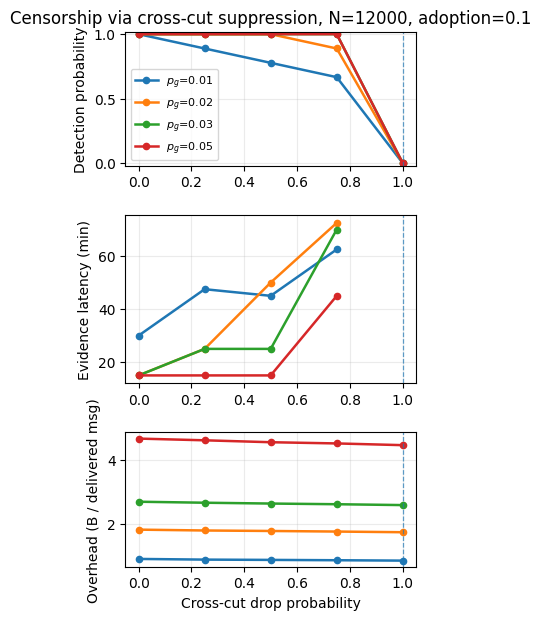

In [112]:
# =========================
# Plot single-adoption censorship figure with raw latency
# =========================

plot_censor_single_adoption_latency(
    df_agg_censor,
    df_agg_censor_iqr if "df_agg_censor_iqr" in globals() else None,
    users=12000,
    adoption_fixed=0.10,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_SINGLE_LAT,
    stem="fig_censor_single_adoption_a01_latency",
)

In [113]:
# =========================
# Single-adoption censorship figure
# Extracted from the censored-latency 3xN plotter
# Panels: detection / censored latency / overhead
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_CENSOR_CENSLAT_SINGLE = OUT_CENSOR / "plots_censored_latency_single"
PLOTS_CENSOR_CENSLAT_SINGLE.mkdir(parents=True, exist_ok=True)

def plot_censor_censored_latency_single(
    df_agg,
    df_censlat,
    users=12000,
    adoption_fixed=0.10,
    timeout_min=120.0,
    title="Censorship via cross-cut suppression",
    outdir=None,
    stem="fig_censor_censored_latency_single",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_censlat[df_censlat["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No aggregated rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No censored-latency rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)

    d1 = d1[np.isclose(d1["adoption"], adoption_fixed)].copy()
    d2 = d2[np.isclose(d2["adoption"], adoption_fixed)].copy()

    if d1.empty:
        raise ValueError(f"No aggregated rows found for adoption={adoption_fixed}")
    if d2.empty:
        raise ValueError(f"No censored-latency rows found for adoption={adoption_fixed}")

    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig = plt.figure(figsize=(3.8, 6.9))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.25, 1.0], hspace=0.34)

    ax_top = fig.add_subplot(gs[0, 0])
    ax_mid = fig.add_subplot(gs[1, 0])
    ax_bot = fig.add_subplot(gs[2, 0])

    for pg in pg_order:
        s1 = d1[np.isclose(d1["p_gossip"], pg)].sort_values("p_drop_crosscut")
        s2 = d2[np.isclose(d2["p_gossip"], pg)].sort_values("p_drop_crosscut")

        x1 = s1["p_drop_crosscut"].to_numpy(dtype=float)
        y_det = s1["detected_rate"].to_numpy(dtype=float)
        y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

        x2 = s2["p_drop_crosscut"].to_numpy(dtype=float)
        y_lat = s2["lat_cens_med"].to_numpy(dtype=float)
        y25 = s2["lat_cens_q25"].to_numpy(dtype=float)
        y75 = s2["lat_cens_q75"].to_numpy(dtype=float)

        lab = fr"$p_g$={pg:g}"

        m_det = np.isfinite(x1) & np.isfinite(y_det)
        if m_det.any():
            ax_top.plot(
                x1[m_det], y_det[m_det],
                marker="o", linewidth=1.8, markersize=4.5, label=lab
            )

        m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
        if m_band.any():
            ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.10)

        m_lat = np.isfinite(x2) & np.isfinite(y_lat)
        if m_lat.any():
            ax_mid.plot(
                x2[m_lat], y_lat[m_lat],
                marker="o", linewidth=1.8, markersize=4.5
            )

        m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
        if m_ovh.any():
            ax_bot.plot(
                x1[m_ovh], y_ovh[m_ovh],
                marker="o", linewidth=1.8, markersize=4.5
            )

    for ax in (ax_top, ax_mid, ax_bot):
        ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
        ax.grid(True, alpha=0.25)

    ax_top.set_ylim(-0.02, 1.02)
    ax_mid.set_ylim(-2, timeout_min + 5)

    ax_top.set_title(f"{title}, N={users}, adoption={adoption_fixed:g}")
    ax_top.set_ylabel("Detection probability")
    ax_mid.set_ylabel(f"Censored latency\n(min, cap={int(timeout_min)})")
    ax_bot.set_ylabel("Overhead (B / delivered msg)")
    ax_bot.set_xlabel("Cross-cut drop probability")

    ax_top.legend(fontsize=8, frameon=True, loc="lower left")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\2166951056.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_censored_latency_single\fig_censor_censored_latency_single_a01.pdf


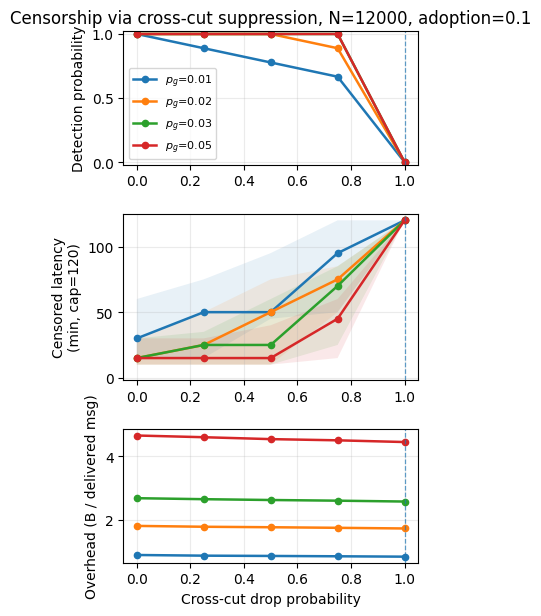

In [114]:
plot_censor_censored_latency_single(
    df_agg_censor,
    df_censlat_censor,
    users=12000,
    adoption_fixed=0.10,
    timeout_min=TIMEOUT_MIN_CENSOR,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_CENSLAT_SINGLE,
    stem="fig_censor_censored_latency_single_a01",
)

In [69]:
# =========================
# Build fast-evidence summary for censorship scenario
# Metric: P(latency to evidence <= threshold_min)
# =========================

import numpy as np
import pandas as pd

def build_fast_evidence_summary(
    df_raw,
    group_cols,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
):
    work = df_raw.copy()

    if lat_col not in work.columns:
        raise ValueError(f"Expected raw latency column '{lat_col}' in df_raw")

    if det_col not in work.columns:
        raise ValueError(f"Expected detection column '{det_col}' in df_raw")

    work["fast_evidence"] = (
        work[det_col].astype(bool) &
        np.isfinite(work[lat_col]) &
        (work[lat_col].astype(float) <= float(threshold_min))
    ).astype(float)

    out = (
        work.groupby(group_cols, dropna=False)
        .agg(
            fast_detect_rate=("fast_evidence", "mean"),
            reps=("run_dir", "count"),
        )
        .reset_index()
    )
    out["threshold_min"] = float(threshold_min)
    return out

GROUP_COLS_CENSOR_FAST = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

df_fast_censor_60 = build_fast_evidence_summary(
    df_raw_censor,
    GROUP_COLS_CENSOR_FAST,
    threshold_min=60.0,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_censor_60.to_csv(OUT_CENSOR / "fast_evidence_60min.csv", index=False)

print("Wrote:", (OUT_CENSOR / "fast_evidence_60min.csv").resolve())
display(df_fast_censor_60.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\fast_evidence_60min.csv


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,fast_detect_rate,reps,threshold_min
0,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.00,0.777778,9,60.0
1,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.25,0.666667,9,60.0
2,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.50,0.555556,9,60.0
3,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,0.75,0.333333,9,60.0
4,12000,0.1,0.01,permanent_fork,sth_proof,0.05,0.03,0.03,1.00,0.000000,9,60.0


In [70]:
# =========================
# Paper-ready censorship figure
# Columns: adoption
# Rows: detection / evidence within 60 min / overhead
# =========================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PLOTS_CENSOR_PAPER = OUT_CENSOR / "plots_paper"
PLOTS_CENSOR_PAPER.mkdir(parents=True, exist_ok=True)

def plot_censor_paper(
    df_agg,
    df_fast,
    users=12000,
    threshold_min=60.0,
    title="Censorship via cross-cut suppression",
    outdir=None,
    stem="fig_censor_paper_fast60_N12000",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_fast[df_fast["users"] == users].copy()

    if d1.empty:
        raise ValueError(f"No aggregated rows found for users={users}")
    if d2.empty:
        raise ValueError(f"No fast-evidence rows found for users={users}")

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())
    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.5, 8.0), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption"], a)].copy()
        d2a = d2[np.isclose(d2["adoption"], a)].copy()

        for pg in pg_order:
            s1 = d1a[np.isclose(d1a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            s2 = d2a[np.isclose(d2a["p_gossip"], pg)].sort_values("p_drop_crosscut")

            x1 = s1["p_drop_crosscut"].to_numpy(dtype=float)
            y_det = s1["detected_rate"].to_numpy(dtype=float)
            y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

            x2 = s2["p_drop_crosscut"].to_numpy(dtype=float)
            y_fast = s2["fast_detect_rate"].to_numpy(dtype=float)

            lab = fr"$p_g$={pg:g}"

            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            m_fast = np.isfinite(x2) & np.isfinite(y_fast)
            if m_fast.any():
                ax_mid.plot(x2[m_fast], y_fast[m_fast], marker="o", linewidth=1.8, markersize=5)

            m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
            if m_ovh.any():
                ax_bot.plot(x1[m_ovh], y_ovh[m_ovh], marker="o", linewidth=1.8, markersize=5)

        for ax in (ax_top, ax_mid, ax_bot):
            ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
            ax.grid(True, alpha=0.25)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)

        ax_mid.set_ylim(-0.02, 1.02)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel(f"Evidence within\n{int(threshold_min)} min")
            ax_bot.set_ylabel("Overhead (B / delivered msg)")

        ax_bot.set_xlabel("Cross-cut drop probability")

        ax_bot.annotate(
            "full\nsuppression",
            xy=(1.0, ax_bot.get_ylim()[1] if ax_bot.get_ylim()[1] > 0 else 1.0),
            xytext=(-6, -6),
            textcoords="offset points",
            fontsize=7,
            ha="right",
            va="top",
        )

    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower left")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_paper\fig_censor_paper_fast60_N12000.pdf


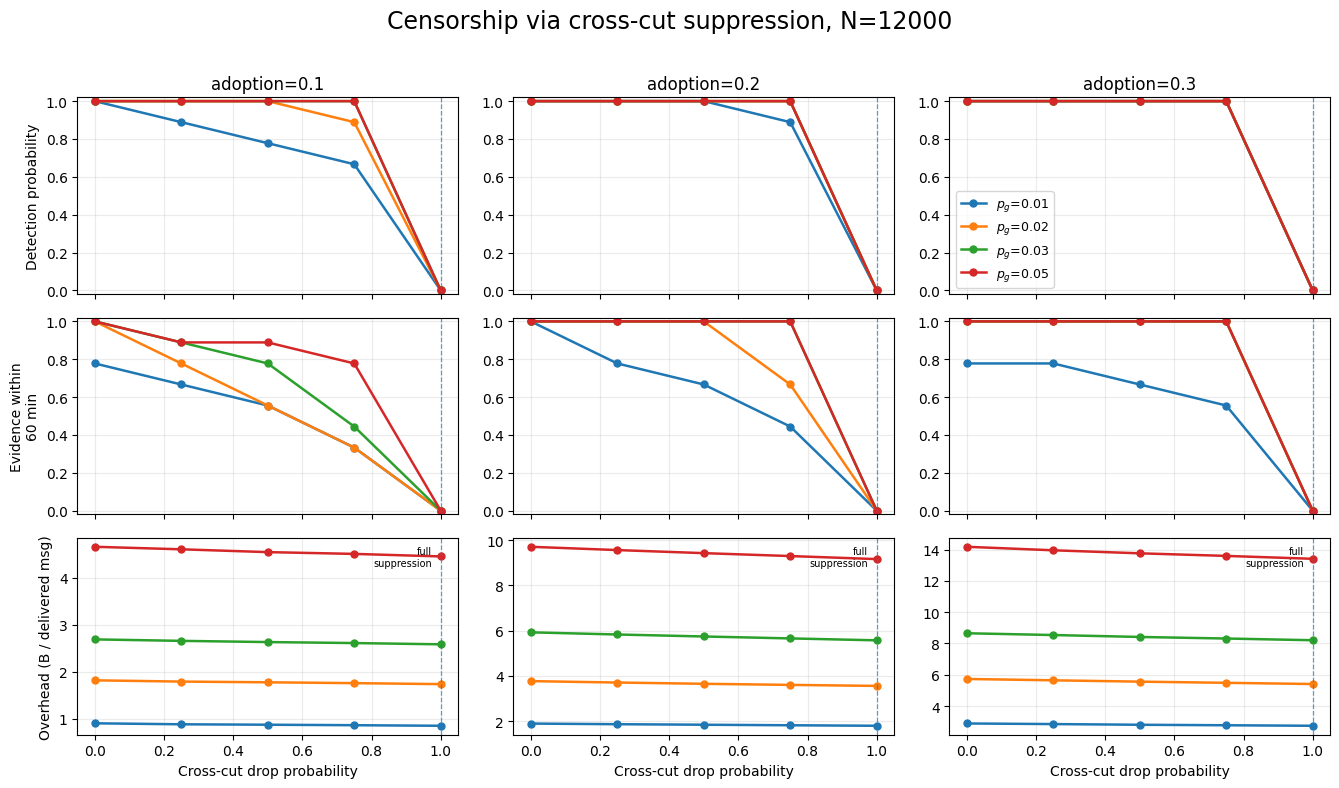

In [71]:
# =========================
# Plot censorship figure with fast-evidence middle row
# =========================

plot_censor_paper(
    df_agg_censor,
    df_fast_censor_60,
    users=12000,
    threshold_min=60.0,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_PAPER,
    stem="fig_censor_paper_fast60_N12000",
)

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S4_censor\plots_paper\fig_censor_paper_fast30_N12000.pdf


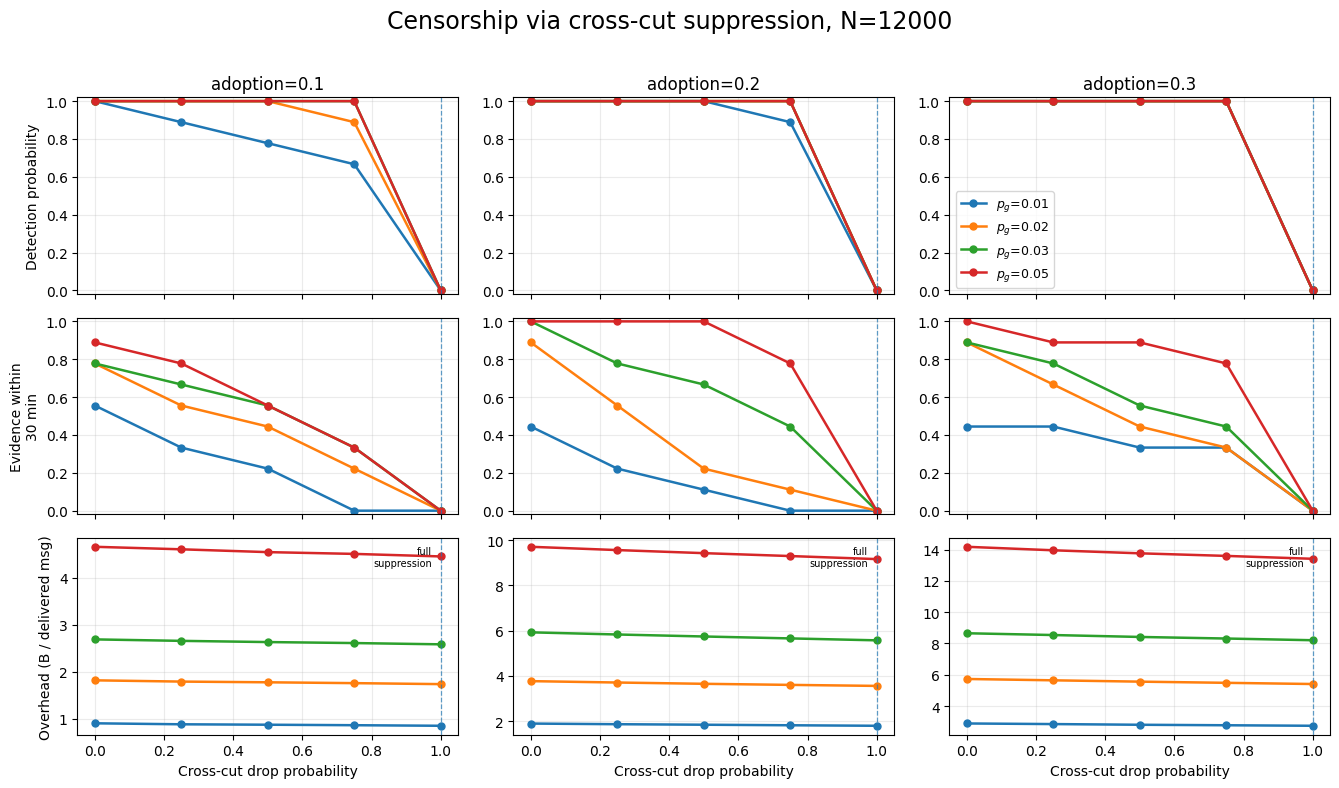

In [72]:
df_fast_censor_30 = build_fast_evidence_summary(
    df_raw_censor,
    GROUP_COLS_CENSOR_FAST,
    threshold_min=30.0,
    lat_col="lat_ev_min",
    det_col="detected",
)

df_fast_censor_30.to_csv(OUT_CENSOR / "fast_evidence_30min.csv", index=False)

plot_censor_paper(
    df_agg_censor,
    df_fast_censor_30,
    users=12000,
    threshold_min=30.0,
    title="Censorship via cross-cut suppression",
    outdir=PLOTS_CENSOR_PAPER,
    stem="fig_censor_paper_fast30_N12000",
)

## Scratch / diagnostics

Put temporary debugging cells below this section only.
That keeps the top of the notebook stable and linear.

In [51]:
# =========================
# S3: Interaction structure sensitivity — definition
# =========================

OUT_INTERACT = OUT_SUITE / "S3_interaction_structure"

BASE_INTERACT = dict(BASE_SMALL)
BASE_INTERACT.update(
    users=N_USERS,
    hours=6.0,
    fork_hour=FORK_HOUR,
    fork_duration=FORK_DUR,
    server_mode="permanent_fork",
    mode="sth_proof",
    fork_frac=FORK_FRAC_TYP,
    sticky_victims=STICKY_VICTIMS,
    p_contact_cross=0.03,
    p_group_cross=0.03,
    p_drop_crosscut=0.0,
)

# Three traffic regimes:
#  - one-to-one heavy
#  - balanced
#  - group-heavy
INTERACTION_REGIMES = {
    "one_to_one_heavy": dict(msg_rate_1to1=0.25, msg_rate_group=0.04),
    "balanced":         dict(msg_rate_1to1=0.20, msg_rate_group=0.08),
    "group_heavy":      dict(msg_rate_1to1=0.10, msg_rate_group=0.16),
}

SWEEP_INTERACT = dict(
    adoption=[0.05, 0.10, 0.20, 0.30],
    p_gossip=PG_GRID,   # truncate to PG_GRID[:...] later if needed for speed
)

GROUP_COLS_INTERACT = [
    "users",
    "adoption",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "msg_rate_1to1",
    "msg_rate_group",
]

REPS_INTERACT = 10
SEED_BASE_INTERACT = SEED_BASE + 4000
DET_THR_INTERACT = DET_THR

In [52]:
# =========================
# S3: Interaction structure sensitivity — execution
# =========================

OUT_INTERACT.mkdir(parents=True, exist_ok=True)

raw_parts = []

for i, (regime_name, regime_cfg) in enumerate(INTERACTION_REGIMES.items()):
    outdir_regime = OUT_INTERACT / regime_name
    outdir_regime.mkdir(parents=True, exist_ok=True)

    base_regime = dict(BASE_INTERACT)
    base_regime.update(regime_cfg)

    df_raw_regime = run_grid(
        base_regime,
        SWEEP_INTERACT,
        replicates=REPS_INTERACT,
        seed_base=SEED_BASE_INTERACT + i * 1000,
        outroot=outdir_regime,
        detection_policy="strict",
    )

    df_raw_regime["interaction_regime"] = regime_name
    raw_parts.append(df_raw_regime)

df_raw_interact = pd.concat(raw_parts, ignore_index=True)
df_raw_interact.to_csv(OUT_INTERACT / "raw.csv", index=False)

df_agg_interact = aggregate_runs(df_raw_interact, GROUP_COLS_INTERACT).sort_values(
    ["msg_rate_1to1", "msg_rate_group", "adoption", "p_gossip"]
)

# Add readable regime labels back
def label_interaction_regime(row):
    for name, cfg in INTERACTION_REGIMES.items():
        if (
            np.isclose(row["msg_rate_1to1"], cfg["msg_rate_1to1"])
            and np.isclose(row["msg_rate_group"], cfg["msg_rate_group"])
        ):
            return name
    return "unknown"

df_agg_interact["interaction_regime"] = df_agg_interact.apply(label_interaction_regime, axis=1)

df_agg_interact.to_csv(OUT_INTERACT / "agg.csv", index=False)

print("Wrote raw:", (OUT_INTERACT / "raw.csv").resolve())
print("Wrote agg:", (OUT_INTERACT / "agg.csv").resolve())
display(df_raw_interact.head())
display(df_agg_interact.head(12))

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction_structure\one_to_one_heavy\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s34000_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction_structure\one_to_one_heavy\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s34000_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction_structure\one_to_one_heavy\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s34001_drop0_pc0p03_pgc0p03/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction_structure\one_to_one_heavy\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s34001_drop0_pc0p03_pgc0p03/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir,interaction_regime
0,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,True,...,0.25,0.04,800,10,0.0,0.0,0.0,1.007188,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,one_to_one_heavy
1,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,True,...,0.25,0.04,800,10,0.0,0.0,0.0,0.957570,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,one_to_one_heavy
2,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.25,0.04,800,10,0.0,0.0,0.0,0.987784,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,one_to_one_heavy
3,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,True,...,0.25,0.04,800,10,0.0,0.0,0.0,0.983305,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,one_to_one_heavy
4,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,True,...,0.25,0.04,800,10,0.0,0.0,0.0,0.975333,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,one_to_one_heavy


,users,adoption,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,msg_rate_1to1,...,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean,interaction_regime
0,12000,0.05,0.005,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,60860.0,NaN,NaN,0.247067,0.247067,2.1,2.1,group_heavy
3,12000,0.05,0.007,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,60969.0,NaN,NaN,0.372502,0.372502,2.6,2.6,group_heavy
6,12000,0.05,0.010,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,60914.5,NaN,NaN,0.497059,0.497059,3.5,3.5,group_heavy
9,12000,0.05,0.015,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,48637.0,NaN,NaN,0.787380,0.787380,8.2,8.2,group_heavy
12,12000,0.05,0.020,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,48637.0,NaN,NaN,1.102246,1.102246,10.2,10.2,group_heavy
15,12000,0.05,0.030,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,48637.0,NaN,NaN,1.600175,1.600175,13.8,13.8,group_heavy
18,12000,0.05,0.050,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,46349.5,NaN,NaN,2.591338,2.591338,20.6,20.6,group_heavy
21,12000,0.10,0.005,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,50158.0,NaN,NaN,0.456348,0.456348,1.8,1.8,group_heavy
24,12000,0.10,0.007,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,52292.0,NaN,NaN,0.697769,0.697769,3.0,3.0,group_heavy
27,12000,0.10,0.010,permanent_fork,sth_proof,0.05,0.03,0.03,0.0,0.1,...,NaN,NaN,50642.0,NaN,NaN,0.960493,0.960493,6.5,6.5,group_heavy


In [53]:
# =========================
# S3: Interaction structure sensitivity — sanity check
# =========================

print("df_raw_interact columns:")
print(sorted(df_raw_interact.columns))

print("\ndf_agg_interact columns:")
print(sorted(df_agg_interact.columns))

display(
    df_agg_interact[
        [
            "interaction_regime",
            "adoption",
            "p_gossip",
            "detected_rate",
            "lat_ev_med",
            "bpd_mean",
            "msgs_first_ev_med",
        ]
    ].head(18)
)

print("\nInteraction regimes in agg:")
print(sorted(df_agg_interact["interaction_regime"].dropna().unique()))

df_raw_interact columns:
['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'interaction_regime', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']

df_agg_interact columns:
['adoption', 'aware_cov_end_mean', 'bpd_mean', 'bps_mean', 'crosscuts_mean', 'detected_rate', 'evid_cov_end_mean', 'evidence_mean', 'fork_frac', 'interaction_regime', 'lat_aw_med', 'lat_ev_med', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_50_ev_med', 'msgs_95_ev_med', 'msgs_first_ev_med', 'p_contact_cros

,interaction_regime,adoption,p_gossip,detected_rate,lat_ev_med,bpd_mean,msgs_first_ev_med
0,group_heavy,0.05,0.005,0.7,80.0,0.247067,60860.0
3,group_heavy,0.05,0.007,0.9,80.0,0.372502,60969.0
6,group_heavy,0.05,0.010,1.0,77.5,0.497059,60914.5
9,group_heavy,0.05,0.015,1.0,30.0,0.787380,48637.0
12,group_heavy,0.05,0.020,1.0,30.0,1.102246,48637.0
15,group_heavy,0.05,0.030,1.0,30.0,1.600175,48637.0
18,group_heavy,0.05,0.050,1.0,25.0,2.591338,46349.5
21,group_heavy,0.10,0.005,0.6,45.0,0.456348,50158.0
24,group_heavy,0.10,0.007,0.9,50.0,0.697769,52292.0
27,group_heavy,0.10,0.010,1.0,50.0,0.960493,50642.0



Interaction regimes in agg:
['balanced', 'group_heavy', 'one_to_one_heavy']


In [54]:
# =========================
# S3: Interaction structure sensitivity — plotting helper
# =========================

def min_pg_by_regime_and_adoption(df, det_thr=0.95):
    rows = []
    for regime in sorted(df["interaction_regime"].dropna().unique()):
        sub_r = df[df["interaction_regime"] == regime].copy()
        for a in sorted(sub_r["adoption"].dropna().unique()):
            s = sub_r[np.isclose(sub_r["adoption"], a)].sort_values("p_gossip")
            good = s[s["detected_rate"] >= det_thr]
            min_pg = float(good["p_gossip"].iloc[0]) if len(good) else np.nan
            rows.append({
                "interaction_regime": regime,
                "adoption": float(a),
                "min_p_gossip": min_pg,
            })
    return pd.DataFrame(rows)


def plot_interaction_structure(df_agg, det_thr=0.95, users=None, outdir=None):
    d = df_agg.copy()
    if users is not None and "users" in d.columns:
        d = d[d["users"] == users].copy()

    d["adoption"] = d["adoption"].astype(float)
    d["p_gossip"] = d["p_gossip"].astype(float)

    regime_styles = {
        "one_to_one_heavy": "--",
        "balanced": "-",
        "group_heavy": ":",
    }
    regime_markers = {
        "one_to_one_heavy": "o",
        "balanced": "s",
        "group_heavy": "^",
    }

    fig, axes = plt.subplots(3, 1, figsize=(4.1, 8.6))

    # Panel 1: detection vs p_gossip
    for regime in sorted(d["interaction_regime"].dropna().unique()):
        sub_r = d[d["interaction_regime"] == regime].copy()
        for a in sorted(sub_r["adoption"].dropna().unique()):
            s = sub_r[np.isclose(sub_r["adoption"], a)].sort_values("p_gossip")
            axes[0].plot(
                s["p_gossip"],
                s["detected_rate"],
                linestyle=regime_styles.get(regime, "-"),
                marker=regime_markers.get(regime, "o"),
                label=f"{regime}, a={a:g}",
            )

    axes[0].axhline(det_thr, linestyle="--", linewidth=1.0)
    axes[0].set_xscale("log")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].set_ylabel("Detection probability")
    axes[0].set_title(f"Interaction structure sensitivity{', N=' + str(users) if users is not None else ''}")
    axes[0].grid(True, alpha=0.25, which="both")
    axes[0].legend(fontsize=6, frameon=True, ncol=2)

    # Panel 2: latency vs overhead
    for regime in sorted(d["interaction_regime"].dropna().unique()):
        sub_r = d[d["interaction_regime"] == regime].copy()
        for a in sorted(sub_r["adoption"].dropna().unique()):
            s = sub_r[np.isclose(sub_r["adoption"], a)].copy()
            axes[1].scatter(
                s["bpd_mean"],
                s["lat_ev_med"],
                marker=regime_markers.get(regime, "o"),
                s=26,
                alpha=0.8,
                label=f"{regime}, a={a:g}",
            )

    axes[1].set_xlabel("Overhead (B / delivered msg)")
    axes[1].set_ylabel("Evidence latency (min)")
    axes[1].grid(True, alpha=0.25)

    # Panel 3: min p_gossip vs adoption by regime
    mins = min_pg_by_regime_and_adoption(d, det_thr=det_thr)
    for regime in sorted(mins["interaction_regime"].dropna().unique()):
        s = mins[mins["interaction_regime"] == regime].sort_values("adoption")
        axes[2].plot(
            s["adoption"],
            s["min_p_gossip"],
            linestyle=regime_styles.get(regime, "-"),
            marker=regime_markers.get(regime, "o"),
            linewidth=1.4,
            label=regime,
        )

    axes[2].set_yscale("log")
    axes[2].set_xlabel("Adoption")
    axes[2].set_ylabel(r"min $p_{\mathrm{gossip}}$")
    axes[2].grid(True, alpha=0.25, which="both")
    axes[2].legend(fontsize=7, frameon=True)

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        suffix = f"_N{users}" if users is not None else ""
        outbase = outdir / f"fig_interaction_structure{suffix}"
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\eval_suite_clean\S3_interaction_structure\plots\fig_interaction_structure_N12000.pdf


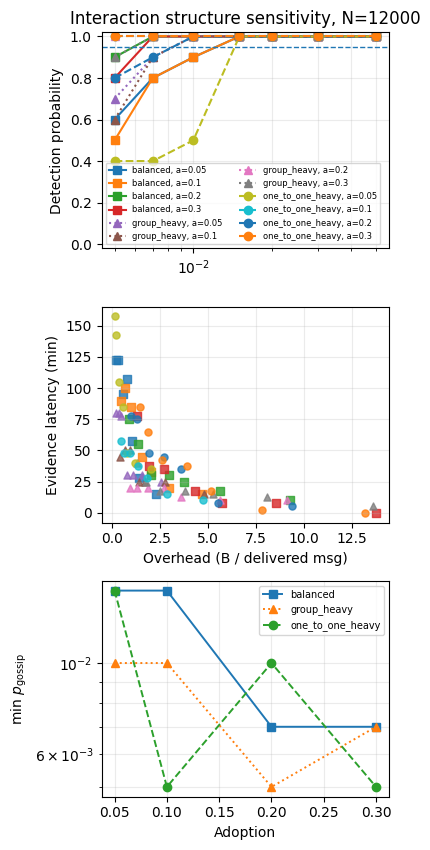

In [55]:
# =========================
# S3: Interaction structure sensitivity — plotting
# =========================

PLOTS_INTERACT = OUT_INTERACT / "plots"
PLOTS_INTERACT.mkdir(parents=True, exist_ok=True)

plot_interaction_structure(
    df_agg_interact,
    det_thr=DET_THR_INTERACT,
    users=N_USERS,
    outdir=PLOTS_INTERACT,
)

In [ ]:

# Example scratch cell:
# run_dir = df_raw_typ.iloc[0]["run_dir"]
# tl = pd.read_csv(Path(run_dir) / "timeline.csv")
# display(tl.head())

In [17]:
## Diagnostics Total messages 95_ev_med being NAN
run_dir = Path(df_raw_typical.iloc[0]["run_dir"])
summary = json.loads((run_dir / "summary.json").read_text())
tl = pd.read_csv(run_dir / "timeline.csv")
print("RUN:", run_dir)
print("\nSUMMARY KEYS:")
print(sorted(summary.keys()))
print("\nTIMELINE COLUMNS:")
print(list(tl.columns))
if "messages_this_tick" in tl.columns:
   print("\nmessages_this_tick sum:", tl["messages_this_tick"].sum())
   print("messages_this_tick nonzero rows:", (tl["messages_this_tick"] > 0).sum())
if "evidence_users" in tl.columns:
   users = int(summary.get("users", df_raw_typical.iloc[0]["users"]))
   print("max evidence_users:", tl["evidence_users"].max())
   print("max evidence fraction:", tl["evidence_users"].max() / users)


RUN: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\paper_sweeps_typical_showcase\permanent_fork_sth_proof_n2000_pg0p002_a0p05_ff0p05_s20000_drop0_pc0p05_pgc0p05

SUMMARY KEYS:
['adoption', 'avg_contacts', 'avg_group_size', 'aware_end', 'crosscut_delivered', 'crosscut_deliveries', 'crosscut_dropped', 'dt_min', 'evidence_end', 'first_awareness_tick', 'first_evidence_tick', 'fork_duration', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'mode', 'p_drop_crosscut', 'p_equiv', 'p_gossip', 'proof_inconsistent', 'proof_ok', 'proof_timeout', 'proof_timeout_rate', 'proof_withhold', 'proof_withhold_rate', 'server_mode', 'sth_period_hours', 'total_gossip_bytes', 'total_messages', 'users', 'witness_required']

TIMELINE COLUMNS:
['tick', 'aware_users', 'detectors', 'evidence_users', 'gossip_bytes_this_tick', 'proofs_ok', 'proofs_inconsistent', 'proofs_withhold', 'proofs_timeout', 'crosscut_deliveries', 'crosscut_dropped', 'messages_this_tick']

messages_this_tick

In [18]:
## Diagnostic 2 Total Messages evidence user 0
display(
   df_raw_typical[
       [
           "users",
           "adoption",
           "p_gossip",
           "detected",
           "evid_cov_end",
           "proof_inconsistent",
           "evidence_events",
           "msgs_95_ev",
       ]
   ].head(20)
)


,users,adoption,p_gossip,detected,evid_cov_end,proof_inconsistent,evidence_events,msgs_95_ev
0,2000,0.05,0.002,False,0.0,0,0,NaN
1,2000,0.05,0.002,False,0.0,0,0,NaN
2,2000,0.05,0.002,False,0.0,0,0,NaN
3,2000,0.05,0.002,False,0.0,0,0,NaN
4,2000,0.05,0.002,True,0.0,1,1,NaN
5,2000,0.05,0.002,False,0.0,0,0,NaN
6,2000,0.05,0.002,False,0.0,0,0,NaN
7,2000,0.05,0.002,False,0.0,0,0,NaN
8,2000,0.05,0.002,False,0.0,0,0,NaN
9,2000,0.05,0.002,False,0.0,0,0,NaN


In [57]:
##Low-mix Panel 1 diagnostics
display(
    df_agg_lowmix[
        ["users", "adoption", "p_gossip", "detected_rate"]
    ]
    .query("users == 12000")
    .sort_values(["adoption", "p_gossip"])
)


,users,adoption,p_gossip,detected_rate
0,12000,0.1,0.005,0.888889
5,12000,0.1,0.005,0.888889
10,12000,0.1,0.005,0.888889
15,12000,0.1,0.005,0.888889
16,12000,0.1,0.007,1.000000
...,...,...,...,...
319,12000,0.3,0.030,1.000000
320,12000,0.3,0.050,1.000000
325,12000,0.3,0.050,1.000000
330,12000,0.3,0.050,1.000000


In [58]:
##Low-mix Panel 1 diagnostics raw values

display(
    df_raw_lowmix[
        ["users", "adoption", "p_gossip", "seed", "detected"]
    ]
    .query("users == 12000")
    .sort_values(["adoption", "p_gossip", "seed"])
)

,users,adoption,p_gossip,seed,detected
0,12000,0.1,0.005,31000,True
9,12000,0.1,0.005,31000,True
18,12000,0.1,0.005,31000,True
27,12000,0.1,0.005,31000,True
36,12000,0.1,0.005,31000,True
...,...,...,...,...,...
2987,12000,0.3,0.050,31008,True
2996,12000,0.3,0.050,31008,True
3005,12000,0.3,0.050,31008,True
3014,12000,0.3,0.050,31008,True


## Interaction Structure Effect (groups)

In [11]:
# =========================
# Scenario: Interaction structure effect (groups)
# Same layout style as censorship figure
# Columns = adoption
# Rows = detection / latency / overhead
# x-axis = avg_group_size
# lines = msg_rate_group
# =========================

OUT_GROUPS = OUT_ROOT / "scenario_groups_effect"

BASE_GROUPS = dict(BASE_SMALL)
BASE_GROUPS.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # keep 1:1 traffic fixed, vary group interaction structure
    msg_rate_1to1=0.20,

    # moderate mixing (typical-ish, not low-mix or censorship)
    p_contact_cross=0.05,
    p_group_cross=0.05,

    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,

    # keep number of groups fixed; vary average group size
    groups=800,
)

ADOPTION_GRID_GROUPS = [0.1, 0.2, 0.3]
AVG_GROUP_SIZE_GRID = [8, 16, 32, 64, 96]
MSG_RATE_GROUP_GRID = [0.00, 0.04, 0.08, 0.12]

SWEEP_GROUPS = dict(
    adoption=ADOPTION_GRID_GROUPS,
    avg_group_size=AVG_GROUP_SIZE_GRID,
    msg_rate_group=MSG_RATE_GROUP_GRID,
)

REPS_GROUPS = 15
SEED_BASE_GROUPS = 41000
DET_THR_GROUPS = 0.95

GROUP_COLS_GROUPS = [
    "users",
    "adoption",
    "avg_group_size",
    "msg_rate_group",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "groups",
]

In [12]:
# =========================
# Run interaction-structure / groups scenario
# =========================

OUT_GROUPS.mkdir(parents=True, exist_ok=True)

df_raw_groups = run_grid(
    BASE_GROUPS,
    SWEEP_GROUPS,
    replicates=REPS_GROUPS,
    seed_base=SEED_BASE_GROUPS,
    outroot=OUT_GROUPS,
    detection_policy="strict",
)

df_raw_groups.to_csv(OUT_GROUPS / "raw.csv", index=False)

df_agg_groups = aggregate_runs(df_raw_groups, GROUP_COLS_GROUPS)
df_agg_groups.to_csv(OUT_GROUPS / "agg.csv", index=False)

df_agg_groups_iqr = aggregate_iqr_safe(df_raw_groups, GROUP_COLS_GROUPS)
df_agg_groups_iqr.to_csv(OUT_GROUPS / "agg_iqr.csv", index=False)

print("Wrote raw:", (OUT_GROUPS / "raw.csv").resolve())
print("Wrote agg:", (OUT_GROUPS / "agg.csv").resolve())
print("Wrote agg_iqr:", (OUT_GROUPS / "agg_iqr.csv").resolve())

display(df_raw_groups.head())
display(df_agg_groups.head())
display(df_agg_groups_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\permanent_fork_sth_proof_n12000_pg0p2_a0p1_ff0p05_s41000_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\permanent_fork_sth_proof_n12000_pg0p2_a0p1_ff0p05_s41000_drop0_pc0p05_pgc0p05/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\permanent_fork_sth_proof_n12000_pg0p2_a0p1_ff0p05_s41001_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\permanent_fork_sth_proof_n12000_pg0p2_a0p1_ff0p05_s41001_drop0_pc0p05_pgc0p05/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\permanent_fork_sth_proof_n12000_pg0p2_a0p1_ff0p05_s41002_drop0_pc0p05_pgc0p05/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenar

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,12000,6.0,5.0,0.2,0.1,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.767266,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_proof,12000,6.0,5.0,0.2,0.1,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.795500,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_proof,12000,6.0,5.0,0.2,0.1,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.767655,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_proof,12000,6.0,5.0,0.2,0.1,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.756915,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_proof,12000,6.0,5.0,0.2,0.1,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.757769,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


,users,adoption,avg_group_size,msg_rate_group,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.1,8,0.00,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,NaN,NaN,NaN,8628.0,NaN,NaN,17.740825,17.740825,27.133333,27.133333
1,12000,0.1,8,0.04,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,NaN,NaN,NaN,15533.0,NaN,NaN,18.107782,18.107782,45.400000,45.400000
2,12000,0.1,8,0.08,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,NaN,NaN,NaN,22166.0,NaN,NaN,18.137204,18.137204,60.666667,60.666667
3,12000,0.1,8,0.12,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,NaN,NaN,NaN,27777.0,NaN,NaN,17.475021,17.475021,81.933333,81.933333
4,12000,0.1,16,0.00,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,NaN,NaN,NaN,8797.0,NaN,NaN,17.627748,17.627748,22.933333,22.933333


,users,adoption,avg_group_size,msg_rate_group,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.1,8,0.00,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,0.0,0.0,5.0,17.740825,17.740825,27.133333,27.133333,NaN,NaN,NaN
1,12000,0.1,8,0.04,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,5.0,0.0,10.0,18.107782,18.107782,45.400000,45.400000,NaN,NaN,NaN
2,12000,0.1,8,0.08,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,5.0,2.5,10.0,18.137204,18.137204,60.666667,60.666667,NaN,NaN,NaN
3,12000,0.1,8,0.12,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,0.0,0.0,5.0,17.475021,17.475021,81.933333,81.933333,NaN,NaN,NaN
4,12000,0.1,16,0.00,permanent_fork,sth_proof,0.05,0.05,0.05,0.0,...,5.0,0.0,17.5,17.627748,17.627748,22.933333,22.933333,NaN,NaN,NaN


In [14]:
# =========================
# Sanity checks for interaction structure scenario
# =========================

print("Unique adoption:", sorted(df_agg_groups["adoption"].dropna().unique()))
print("Unique avg_group_size:", sorted(df_agg_groups["avg_group_size"].dropna().unique()))
print("Unique msg_rate_group:", sorted(df_agg_groups["msg_rate_group"].dropna().unique()))
print("Unique groups:", sorted(df_agg_groups["groups"].dropna().unique()))
print("Unique users:", sorted(df_agg_groups["users"].dropna().unique()))

print("\nDetection counts by adoption / avg_group_size / msg_rate_group:")
tmp_counts_groups = (
    df_raw_groups.groupby(["adoption", "avg_group_size", "msg_rate_group"], dropna=False)["detected"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .sort_values(["adoption", "avg_group_size", "msg_rate_group"])
)
print(tmp_counts_groups.to_string(index=False))

Unique adoption: [np.float64(0.1), np.float64(0.2), np.float64(0.3)]
Unique avg_group_size: [np.int64(8), np.int64(16), np.int64(32), np.int64(64), np.int64(96)]
Unique msg_rate_group: [np.float64(0.0), np.float64(0.04), np.float64(0.08), np.float64(0.12)]
Unique groups: [np.int64(800)]
Unique users: [np.int64(12000)]

Detection counts by adoption / avg_group_size / msg_rate_group:
 adoption  avg_group_size  msg_rate_group  sum  count  mean
      0.1               8            0.00   15     15   1.0
      0.1               8            0.04   15     15   1.0
      0.1               8            0.08   15     15   1.0
      0.1               8            0.12   15     15   1.0
      0.1              16            0.00   15     15   1.0
      0.1              16            0.04   15     15   1.0
      0.1              16            0.08   15     15   1.0
      0.1              16            0.12   15     15   1.0
      0.1              32            0.00   15     15   1.0
      0.1      

In [15]:
# =========================
# Plot helper: same layout as censorship figure
# columns = adoption
# rows = detection / latency / overhead
# x-axis = avg_group_size
# lines = msg_rate_group
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_GROUPS = OUT_GROUPS / "plots"
PLOTS_GROUPS.mkdir(parents=True, exist_ok=True)

def plot_groups_effect_grid(
    df_agg,
    df_iqr,
    users=12000,
    x_col="avg_group_size",
    line_col="msg_rate_group",
    title="Interaction structure effect (groups)",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    d1["adoption"] = d1["adoption"].astype(float)
    d1[x_col] = d1[x_col].astype(float)
    d1[line_col] = d1[line_col].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2[x_col] = d2[x_col].astype(float)
    d2[line_col] = d2[line_col].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())
    line_order = sorted(d1[line_col].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.5, 8.2), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption"], a)].copy()
        d2a = d2[np.isclose(d2["adoption"], a)].copy()

        for lv in line_order:
            s1 = d1a[np.isclose(d1a[line_col], lv)].sort_values(x_col)
            s2 = d2a[np.isclose(d2a[line_col], lv)].sort_values(x_col)

            x1 = s1[x_col].to_numpy(dtype=float)
            y_det = s1["detected_rate"].to_numpy(dtype=float)
            y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

            x2 = s2[x_col].to_numpy(dtype=float)
            y_lat = s2["lat_ev_med"].to_numpy(dtype=float)
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float) if "lat_ev_q25" in s2.columns else None
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float) if "lat_ev_q75" in s2.columns else None

            lab = fr"$r_g$={lv:g}"

            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            if y25 is not None and y75 is not None:
                m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
                if m_band.any():
                    ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.12)

            m_lat = np.isfinite(x2) & np.isfinite(y_lat)
            if m_lat.any():
                ax_mid.plot(x2[m_lat], y_lat[m_lat], marker="o", linewidth=1.8, markersize=5)

            m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
            if m_ovh.any():
                ax_bot.plot(x1[m_ovh], y_ovh[m_ovh], marker="o", linewidth=1.8, markersize=5, label=lab)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)
        ax_top.grid(True, alpha=0.25)
        ax_mid.grid(True, alpha=0.25)
        ax_bot.grid(True, alpha=0.25)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel("Evidence latency (min)")
            ax_bot.set_ylabel("Overhead (B / delivered msg)")

        ax_bot.set_xlabel("Average group size")

    # Put legend only once, in the top-right panel
    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower right")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_GROUPS / f"fig_groups_effect_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

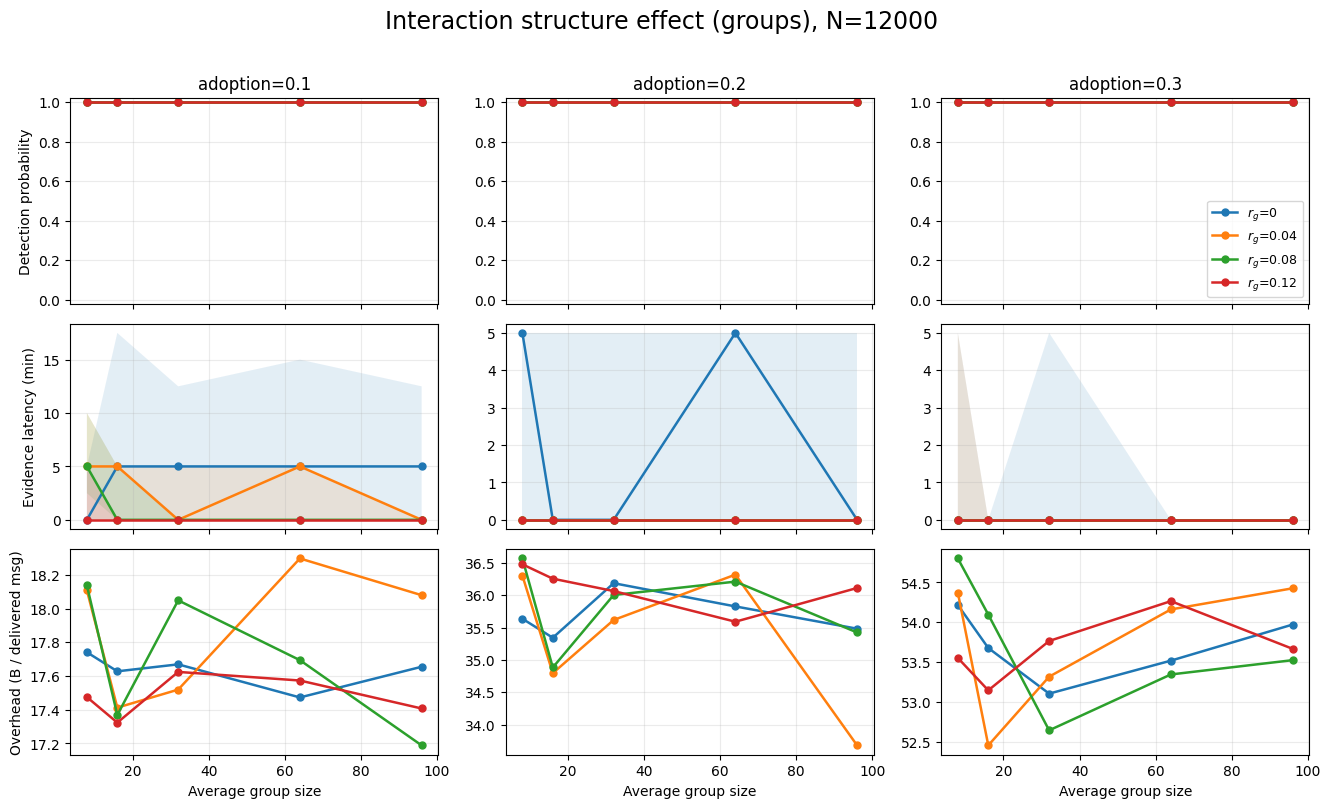

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_effect\plots\fig_groups_effect_N12000.pdf


In [16]:
# =========================
# Generate interaction-structure / groups figure
# =========================
plot_groups_effect_grid(
    df_agg_groups,
    df_agg_groups_iqr,
    users=12000,
    x_col="avg_group_size",
    line_col="msg_rate_group",
    title="Interaction structure effect (groups)",
)

In [17]:
display(
    df_raw_groups[
        [
            "adoption",
            "avg_group_size",
            "msg_rate_group",
            "bytes_per_delivery",
            "bytes_per_send",
            "evidence_events",
            "detected",
        ]
    ].sort_values(["adoption", "avg_group_size", "msg_rate_group"])
)

,adoption,avg_group_size,msg_rate_group,bytes_per_delivery,bytes_per_send,evidence_events,detected
0,0.1,8,0.00,16.436948,16.436948,26,True
1,0.1,8,0.00,16.641811,16.641811,33,True
2,0.1,8,0.00,17.597448,17.597448,20,True
3,0.1,8,0.00,17.121567,17.121567,27,True
4,0.1,8,0.00,16.909720,16.909720,30,True
...,...,...,...,...,...,...,...
895,0.3,96,0.12,53.757406,53.757406,4373,True
896,0.3,96,0.12,55.803235,55.803235,4543,True
897,0.3,96,0.12,53.405068,53.405068,3499,True
898,0.3,96,0.12,54.749203,54.749203,4371,True


## Interaction Structure Scenario 2

In [19]:
# =========================
# Scenario: Interaction structure effect v2 (harder / near-threshold)
# x-axis = msg_rate_group
# lines = avg_group_size
# columns = adoption
# rows = detection / latency / overhead
# =========================

OUT_GROUP_ACTIVITY_V2 = OUT_ROOT / "scenario_groups_activity_effect_v2"

BASE_GROUP_ACTIVITY_V2 = dict(BASE_SMALL)
BASE_GROUP_ACTIVITY_V2.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # keep 1:1 traffic fixed
    msg_rate_1to1=0.20,

    # harder than the earlier version: lower mixing
    p_contact_cross=0.02,
    p_group_cross=0.02,

    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,

    groups=800,

    # key: fix a near-threshold gossip level
    p_gossip=0.005,
)

ADOPTION_GRID_GACT_V2 = [0.05, 0.10, 0.20]
MSG_RATE_GROUP_GRID_GACT_V2 = [0.00, 0.02, 0.04, 0.08, 0.12, 0.16]
AVG_GROUP_SIZE_GRID_GACT_V2 = [8, 32, 64]

SWEEP_GROUP_ACTIVITY_V2 = dict(
    adoption=ADOPTION_GRID_GACT_V2,
    msg_rate_group=MSG_RATE_GROUP_GRID_GACT_V2,
    avg_group_size=AVG_GROUP_SIZE_GRID_GACT_V2,
)

REPS_GROUP_ACTIVITY_V2 = 15
SEED_BASE_GROUP_ACTIVITY_V2 = 44000

GROUP_COLS_GROUP_ACTIVITY_V2 = [
    "users",
    "adoption",
    "msg_rate_group",
    "avg_group_size",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "groups",
]

In [20]:
# =========================
# Run interaction-structure scenario v2
# =========================

OUT_GROUP_ACTIVITY_V2.mkdir(parents=True, exist_ok=True)

df_raw_group_activity_v2 = run_grid(
    BASE_GROUP_ACTIVITY_V2,
    SWEEP_GROUP_ACTIVITY_V2,
    replicates=REPS_GROUP_ACTIVITY_V2,
    seed_base=SEED_BASE_GROUP_ACTIVITY_V2,
    outroot=OUT_GROUP_ACTIVITY_V2,
    detection_policy="strict",
)

df_raw_group_activity_v2.to_csv(OUT_GROUP_ACTIVITY_V2 / "raw.csv", index=False)

df_agg_group_activity_v2 = aggregate_runs(
    df_raw_group_activity_v2,
    GROUP_COLS_GROUP_ACTIVITY_V2,
)
df_agg_group_activity_v2.to_csv(OUT_GROUP_ACTIVITY_V2 / "agg.csv", index=False)

df_agg_group_activity_v2_iqr = aggregate_iqr_safe(
    df_raw_group_activity_v2,
    GROUP_COLS_GROUP_ACTIVITY_V2,
)
df_agg_group_activity_v2_iqr.to_csv(OUT_GROUP_ACTIVITY_V2 / "agg_iqr.csv", index=False)

print("Wrote raw:", (OUT_GROUP_ACTIVITY_V2 / "raw.csv").resolve())
print("Wrote agg:", (OUT_GROUP_ACTIVITY_V2 / "agg.csv").resolve())
print("Wrote agg_iqr:", (OUT_GROUP_ACTIVITY_V2 / "agg_iqr.csv").resolve())

display(df_raw_group_activity_v2.head())
display(df_agg_group_activity_v2.head())
display(df_agg_group_activity_v2_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s44000_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s44000_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s44001_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s44001_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s44002_drop0_pc0p02_pgc0p02/summary.jso

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.976520,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,True,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.916021,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.955076,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.938277,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,True,0.2,0.0,800,8,0.0,0.0,0.0,0.915357,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


,users,adoption,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.05,0.00,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,17689.0,NaN,NaN,0.236606,0.236606,0.133333,0.133333
1,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,13783.0,NaN,NaN,0.188394,0.188394,0.333333,0.333333
2,12000,0.05,0.00,64,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,10576.5,NaN,NaN,0.199910,0.199910,0.133333,0.133333
3,12000,0.05,0.02,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,26201.5,NaN,NaN,0.255684,0.255684,0.133333,0.133333
4,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,42842.5,NaN,NaN,0.375292,0.375292,1.333333,1.333333


,users,adoption,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.05,0.00,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,140.0,130.00,150.00,0.236606,0.236606,0.133333,0.133333,NaN,NaN,NaN
1,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,90.0,87.50,97.50,0.188394,0.188394,0.333333,0.333333,NaN,NaN,NaN
2,12000,0.05,0.00,64,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,42.5,26.25,58.75,0.199910,0.199910,0.133333,0.133333,NaN,NaN,NaN
3,12000,0.05,0.02,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,155.0,150.00,160.00,0.255684,0.255684,0.133333,0.133333,NaN,NaN,NaN
4,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,47.5,40.00,70.00,0.375292,0.375292,1.333333,1.333333,NaN,NaN,NaN


In [21]:
# =========================
# Sanity checks for interaction-structure scenario v2
# =========================

print("Unique adoption:", sorted(df_agg_group_activity_v2["adoption"].dropna().unique()))
print("Unique msg_rate_group:", sorted(df_agg_group_activity_v2["msg_rate_group"].dropna().unique()))
print("Unique avg_group_size:", sorted(df_agg_group_activity_v2["avg_group_size"].dropna().unique()))
print("Unique p_gossip:", sorted(df_agg_group_activity_v2["p_gossip"].dropna().unique()))
print("Unique p_contact_cross:", sorted(df_agg_group_activity_v2["p_contact_cross"].dropna().unique()))
print("Unique p_group_cross:", sorted(df_agg_group_activity_v2["p_group_cross"].dropna().unique()))

print("\nDetection counts by adoption / msg_rate_group / avg_group_size:")
tmp_counts_group_activity_v2 = (
    df_raw_group_activity_v2
    .groupby(["adoption", "msg_rate_group", "avg_group_size"], dropna=False)["detected"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .sort_values(["adoption", "msg_rate_group", "avg_group_size"])
)
print(tmp_counts_group_activity_v2.to_string(index=False))

Unique adoption: [np.float64(0.05), np.float64(0.1), np.float64(0.2)]
Unique msg_rate_group: [np.float64(0.0), np.float64(0.02), np.float64(0.04), np.float64(0.08), np.float64(0.12), np.float64(0.16)]
Unique avg_group_size: [np.int64(8), np.int64(32), np.int64(64)]
Unique p_gossip: [np.float64(0.005)]
Unique p_contact_cross: [np.float64(0.02)]
Unique p_group_cross: [np.float64(0.02)]

Detection counts by adoption / msg_rate_group / avg_group_size:
 adoption  msg_rate_group  avg_group_size  sum  count     mean
     0.05            0.00               8    2     15 0.133333
     0.05            0.00              32    3     15 0.200000
     0.05            0.00              64    2     15 0.133333
     0.05            0.02               8    2     15 0.133333
     0.05            0.02              32    8     15 0.533333
     0.05            0.02              64    7     15 0.466667
     0.05            0.04               8    3     15 0.200000
     0.05            0.04              32   

In [22]:
# =========================
# Plot helper: interaction-structure scenario v2
# columns = adoption
# rows = detection / latency / overhead
# x-axis = msg_rate_group
# lines = avg_group_size
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_GROUP_ACTIVITY_V2 = OUT_GROUP_ACTIVITY_V2 / "plots"
PLOTS_GROUP_ACTIVITY_V2.mkdir(parents=True, exist_ok=True)

def plot_group_activity_effect_grid_v2(
    df_agg,
    df_iqr,
    users=12000,
    x_col="msg_rate_group",
    line_col="avg_group_size",
    title="Interaction structure effect (group activity, near-threshold)",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    d1["adoption"] = d1["adoption"].astype(float)
    d1[x_col] = d1[x_col].astype(float)
    d1[line_col] = d1[line_col].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2[x_col] = d2[x_col].astype(float)
    d2[line_col] = d2[line_col].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())
    line_order = sorted(d1[line_col].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.5, 8.2), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption"], a)].copy()
        d2a = d2[np.isclose(d2["adoption"], a)].copy()

        for lv in line_order:
            s1 = d1a[np.isclose(d1a[line_col], lv)].sort_values(x_col)
            s2 = d2a[np.isclose(d2a[line_col], lv)].sort_values(x_col)

            x1 = s1[x_col].to_numpy(dtype=float)
            y_det = s1["detected_rate"].to_numpy(dtype=float)
            y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

            x2 = s2[x_col].to_numpy(dtype=float)
            y_lat = s2["lat_ev_med"].to_numpy(dtype=float)
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float) if "lat_ev_q25" in s2.columns else None
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float) if "lat_ev_q75" in s2.columns else None

            lab = f"group size={int(lv)}"

            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            if y25 is not None and y75 is not None:
                m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
                if m_band.any():
                    ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.12)

            m_lat = np.isfinite(x2) & np.isfinite(y_lat)
            if m_lat.any():
                ax_mid.plot(x2[m_lat], y_lat[m_lat], marker="o", linewidth=1.8, markersize=5)

            m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
            if m_ovh.any():
                ax_bot.plot(x1[m_ovh], y_ovh[m_ovh], marker="o", linewidth=1.8, markersize=5, label=lab)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)
        ax_top.grid(True, alpha=0.25)
        ax_mid.grid(True, alpha=0.25)
        ax_bot.grid(True, alpha=0.25)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel("Evidence latency (min)")
            ax_bot.set_ylabel("Overhead (B / delivered msg)")

        ax_bot.set_xlabel("Group message rate")

    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower right")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_GROUP_ACTIVITY_V2 / f"fig_group_activity_effect_v2_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

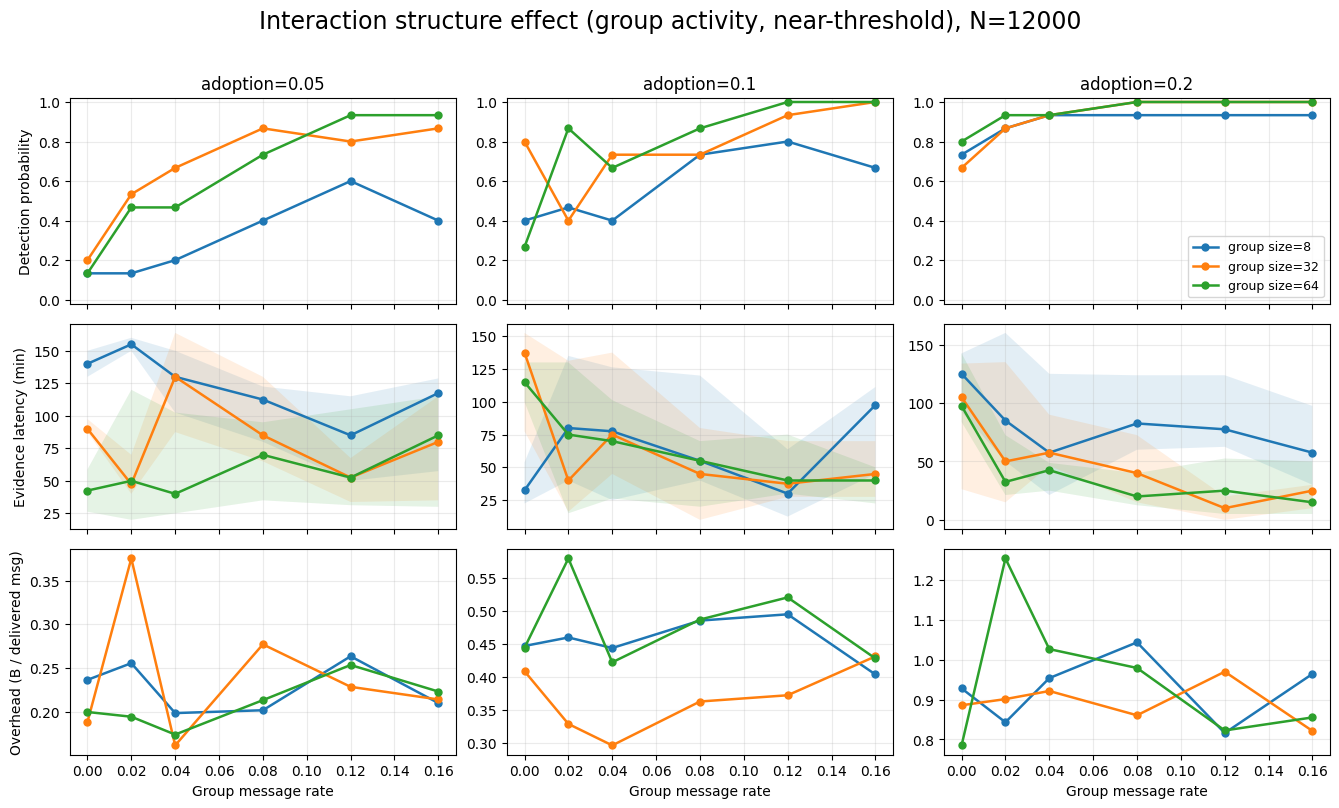

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_activity_effect_v2\plots\fig_group_activity_effect_v2_N12000.pdf


In [23]:
# =========================
# Generate corrected interaction-structure figure
# =========================
plot_group_activity_effect_grid_v2(
    df_agg_group_activity_v2,
    df_agg_group_activity_v2_iqr,
    users=12000,
    x_col="msg_rate_group",
    line_col="avg_group_size",
    title="Interaction structure effect (group activity, near-threshold)",
)

## Pure gossip-message-rate Effect

In [24]:
# =========================
# Scenario: Pure group-message-rate effect
# Fix avg_group_size, vary msg_rate_group
# =========================

OUT_GMRATE = OUT_ROOT / "scenario_pure_group_message_rate"

BASE_GMRATE = dict(BASE_SMALL)
BASE_GMRATE.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    msg_rate_1to1=0.20,

    # near-threshold baseline
    p_contact_cross=0.02,
    p_group_cross=0.02,
    p_gossip=0.005,

    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,

    groups=800,
    avg_group_size=32,   # fixed
)

ADOPTION_GRID_GMRATE = [0.05, 0.10, 0.20]
MSG_RATE_GROUP_GRID_GMRATE = [0.00, 0.02, 0.04, 0.08, 0.12, 0.16]

SWEEP_GMRATE = dict(
    adoption=ADOPTION_GRID_GMRATE,
    msg_rate_group=MSG_RATE_GROUP_GRID_GMRATE,
)

REPS_GMRATE = 15
SEED_BASE_GMRATE = 45000

GROUP_COLS_GMRATE = [
    "users",
    "adoption",
    "msg_rate_group",
    "avg_group_size",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "groups",
]

In [25]:
OUT_GMRATE.mkdir(parents=True, exist_ok=True)

df_raw_gmrate = run_grid(
    BASE_GMRATE,
    SWEEP_GMRATE,
    replicates=REPS_GMRATE,
    seed_base=SEED_BASE_GMRATE,
    outroot=OUT_GMRATE,
    detection_policy="strict",
)

df_raw_gmrate.to_csv(OUT_GMRATE / "raw.csv", index=False)

df_agg_gmrate = aggregate_runs(df_raw_gmrate, GROUP_COLS_GMRATE)
df_agg_gmrate.to_csv(OUT_GMRATE / "agg.csv", index=False)

df_agg_gmrate_iqr = aggregate_iqr_safe(df_raw_gmrate, GROUP_COLS_GMRATE)
df_agg_gmrate_iqr.to_csv(OUT_GMRATE / "agg_iqr.csv", index=False)

display(df_agg_gmrate.head())
display(df_agg_gmrate_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s45000_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s45000_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s45001_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s45001_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s45002_drop0_pc0p02_pgc0p02/summary.json and C:\U

,users,adoption,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,14664.0,NaN,NaN,0.230445,0.230445,0.266667,0.266667
1,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,46427.0,NaN,NaN,0.190109,0.190109,0.666667,0.666667
2,12000,0.05,0.04,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,87899.5,NaN,NaN,0.123129,0.123129,0.600000,0.600000
3,12000,0.05,0.08,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,173936.0,NaN,NaN,0.286146,0.286146,5.266667,5.266667
4,12000,0.05,0.12,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,193590.5,NaN,NaN,0.220830,0.220830,5.533333,5.533333


,users,adoption,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,100.0,71.25,121.25,0.230445,0.230445,0.266667,0.266667,NaN,NaN,NaN
1,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,62.5,25.00,117.50,0.190109,0.190109,0.666667,0.666667,NaN,NaN,NaN
2,12000,0.05,0.04,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,90.0,68.75,130.00,0.123129,0.123129,0.600000,0.600000,NaN,NaN,NaN
3,12000,0.05,0.08,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,95.0,70.00,125.00,0.286146,0.286146,5.266667,5.266667,NaN,NaN,NaN
4,12000,0.05,0.12,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,40.0,22.50,66.25,0.220830,0.220830,5.533333,5.533333,NaN,NaN,NaN


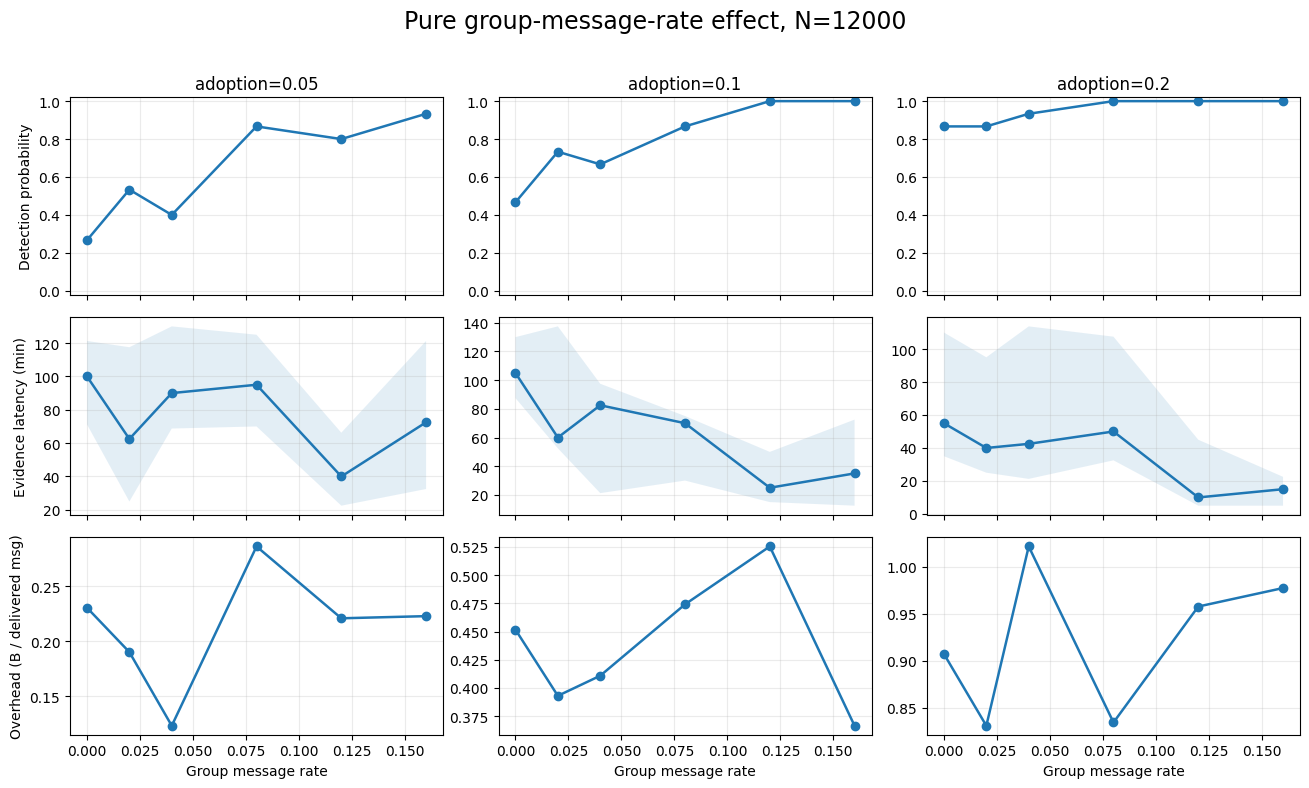

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_message_rate\plots\fig_pure_group_message_rate_N12000.pdf


In [26]:
# =========================
# Plot: pure group-message-rate effect
# =========================
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

PLOTS_GMRATE = OUT_GMRATE / "plots"
PLOTS_GMRATE.mkdir(parents=True, exist_ok=True)

def plot_pure_group_message_rate(df_agg, df_iqr, users=12000):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    adoption_order = sorted(d1["adoption"].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.2, 8.0), sharex="col")
    fig.suptitle(f"Pure group-message-rate effect, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        s1 = d1[np.isclose(d1["adoption"], a)].sort_values("msg_rate_group")
        s2 = d2[np.isclose(d2["adoption"], a)].sort_values("msg_rate_group")

        x1 = s1["msg_rate_group"].to_numpy(dtype=float)
        x2 = s2["msg_rate_group"].to_numpy(dtype=float)

        axes[0, j].plot(x1, s1["detected_rate"].to_numpy(dtype=float), marker="o", linewidth=1.8)
        axes[1, j].plot(x2, s2["lat_ev_med"].to_numpy(dtype=float), marker="o", linewidth=1.8)
        if "lat_ev_q25" in s2.columns and "lat_ev_q75" in s2.columns:
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float)
            m = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
            if m.any():
                axes[1, j].fill_between(x2[m], y25[m], y75[m], alpha=0.12)
        axes[2, j].plot(x1, s1["bpd_mean"].to_numpy(dtype=float), marker="o", linewidth=1.8)

        axes[0, j].set_title(f"adoption={a:g}")
        axes[0, j].set_ylim(-0.02, 1.02)
        axes[0, j].grid(True, alpha=0.25)
        axes[1, j].grid(True, alpha=0.25)
        axes[2, j].grid(True, alpha=0.25)
        axes[2, j].set_xlabel("Group message rate")

    axes[0, 0].set_ylabel("Detection probability")
    axes[1, 0].set_ylabel("Evidence latency (min)")
    axes[2, 0].set_ylabel("Overhead (B / delivered msg)")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_GMRATE / f"fig_pure_group_message_rate_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

plot_pure_group_message_rate(df_agg_gmrate, df_agg_gmrate_iqr, users=12000)

## Pure group-size effect

In [27]:
# =========================
# Scenario: Pure group-size effect
# Fix msg_rate_group, vary avg_group_size
# =========================

OUT_GSIZE = OUT_ROOT / "scenario_pure_group_size"

BASE_GSIZE = dict(BASE_SMALL)
BASE_GSIZE.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    msg_rate_1to1=0.20,
    msg_rate_group=0.08,  # fixed

    # near-threshold baseline
    p_contact_cross=0.02,
    p_group_cross=0.02,
    p_gossip=0.005,

    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,

    groups=800,
)

ADOPTION_GRID_GSIZE = [0.05, 0.10, 0.20]
AVG_GROUP_SIZE_GRID_GSIZE = [8, 16, 32, 64, 96]

SWEEP_GSIZE = dict(
    adoption=ADOPTION_GRID_GSIZE,
    avg_group_size=AVG_GROUP_SIZE_GRID_GSIZE,
)

REPS_GSIZE = 15
SEED_BASE_GSIZE = 46000

GROUP_COLS_GSIZE = [
    "users",
    "adoption",
    "avg_group_size",
    "msg_rate_group",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "groups",
]

In [28]:
OUT_GSIZE.mkdir(parents=True, exist_ok=True)

df_raw_gsize = run_grid(
    BASE_GSIZE,
    SWEEP_GSIZE,
    replicates=REPS_GSIZE,
    seed_base=SEED_BASE_GSIZE,
    outroot=OUT_GSIZE,
    detection_policy="strict",
)

df_raw_gsize.to_csv(OUT_GSIZE / "raw.csv", index=False)

df_agg_gsize = aggregate_runs(df_raw_gsize, GROUP_COLS_GSIZE)
df_agg_gsize.to_csv(OUT_GSIZE / "agg.csv", index=False)

df_agg_gsize_iqr = aggregate_iqr_safe(df_raw_gsize, GROUP_COLS_GSIZE)
df_agg_gsize_iqr.to_csv(OUT_GSIZE / "agg_iqr.csv", index=False)

display(df_agg_gsize.head())
display(df_agg_gsize_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s46000_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s46000_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s46001_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s46001_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s46002_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_inc

,users,adoption,avg_group_size,msg_rate_group,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.05,8,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,28098.5,NaN,NaN,0.230407,0.230407,0.800000,0.800000
1,12000,0.05,16,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,79976.5,NaN,NaN,0.242961,0.242961,1.466667,1.466667
2,12000,0.05,32,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,168593.0,NaN,NaN,0.245376,0.245376,6.666667,6.666667
3,12000,0.05,64,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,397018.0,NaN,NaN,0.162253,0.162253,2.400000,2.400000
4,12000,0.05,96,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,482869.5,NaN,NaN,0.212875,0.212875,8.000000,8.000000


,users,adoption,avg_group_size,msg_rate_group,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.05,8,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,47.5,31.25,108.75,0.230407,0.230407,0.800000,0.800000,NaN,NaN,NaN
1,12000,0.05,16,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,100.0,48.75,136.25,0.242961,0.242961,1.466667,1.466667,NaN,NaN,NaN
2,12000,0.05,32,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,85.0,25.00,110.00,0.245376,0.245376,6.666667,6.666667,NaN,NaN,NaN
3,12000,0.05,64,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,110.0,50.00,147.50,0.162253,0.162253,2.400000,2.400000,NaN,NaN,NaN
4,12000,0.05,96,0.08,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,67.5,40.00,83.75,0.212875,0.212875,8.000000,8.000000,NaN,NaN,NaN


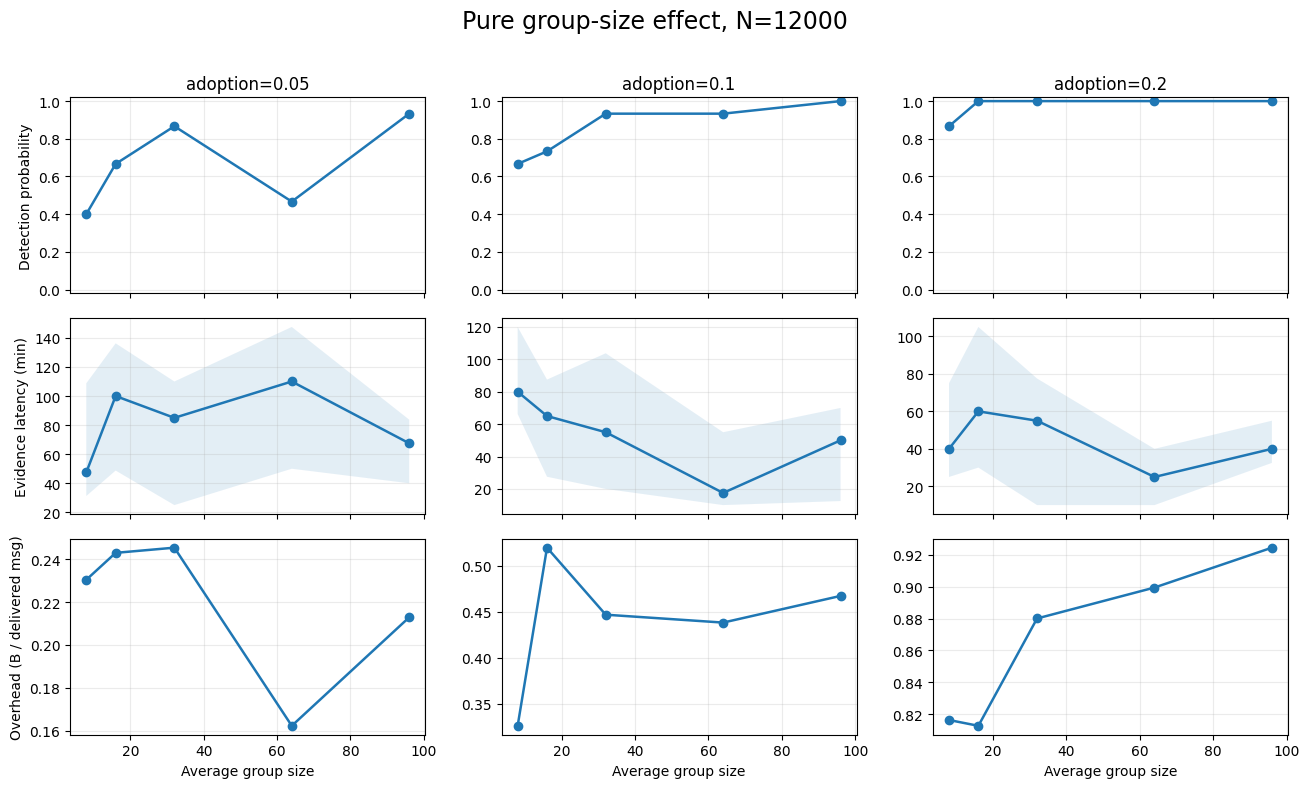

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_pure_group_size\plots\fig_pure_group_size_N12000.pdf


In [29]:
# =========================
# Plot: pure group-size effect
# =========================
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

PLOTS_GSIZE = OUT_GSIZE / "plots"
PLOTS_GSIZE.mkdir(parents=True, exist_ok=True)

def plot_pure_group_size(df_agg, df_iqr, users=12000):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    adoption_order = sorted(d1["adoption"].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.2, 8.0), sharex="col")
    fig.suptitle(f"Pure group-size effect, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        s1 = d1[np.isclose(d1["adoption"], a)].sort_values("avg_group_size")
        s2 = d2[np.isclose(d2["adoption"], a)].sort_values("avg_group_size")

        x1 = s1["avg_group_size"].to_numpy(dtype=float)
        x2 = s2["avg_group_size"].to_numpy(dtype=float)

        axes[0, j].plot(x1, s1["detected_rate"].to_numpy(dtype=float), marker="o", linewidth=1.8)
        axes[1, j].plot(x2, s2["lat_ev_med"].to_numpy(dtype=float), marker="o", linewidth=1.8)
        if "lat_ev_q25" in s2.columns and "lat_ev_q75" in s2.columns:
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float)
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float)
            m = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
            if m.any():
                axes[1, j].fill_between(x2[m], y25[m], y75[m], alpha=0.12)
        axes[2, j].plot(x1, s1["bpd_mean"].to_numpy(dtype=float), marker="o", linewidth=1.8)

        axes[0, j].set_title(f"adoption={a:g}")
        axes[0, j].set_ylim(-0.02, 1.02)
        axes[0, j].grid(True, alpha=0.25)
        axes[1, j].grid(True, alpha=0.25)
        axes[2, j].grid(True, alpha=0.25)
        axes[2, j].set_xlabel("Average group size")

    axes[0, 0].set_ylabel("Detection probability")
    axes[1, 0].set_ylabel("Evidence latency (min)")
    axes[2, 0].set_ylabel("Overhead (B / delivered msg)")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_GSIZE / f"fig_pure_group_size_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

plot_pure_group_size(df_agg_gsize, df_agg_gsize_iqr, users=12000)

## Another attempt at showcasing groups effect

In [30]:
# =========================
# Dedicated figure: Group chats as high-fanout cross-partition gossip events
# x-axis = msg_rate_group
# lines = avg_group_size
# panels = detection / latency / cross-partition deliveries
# =========================

OUT_GROUP_HIFAN = OUT_ROOT / "scenario_group_highfanout_connectivity"

BASE_GROUP_HIFAN = dict(BASE_SMALL)
BASE_GROUP_HIFAN.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # keep 1:1 traffic fixed
    msg_rate_1to1=0.20,

    # near-threshold regime so the effect is visible
    p_contact_cross=0.02,
    p_group_cross=0.02,
    p_gossip=0.005,

    fork_frac=0.05,
    sticky_victims=True,
    p_drop_crosscut=0.0,

    # keep number of groups fixed
    groups=800,
)

# Use low/moderate adoption so group effects remain visible.
ADOPTION_GRID_GROUP_HIFAN = [0.05, 0.10, 0.20]

# Main x-axis
MSG_RATE_GROUP_GRID_GROUP_HIFAN = [0.00, 0.02, 0.04, 0.08, 0.12, 0.16]

# Structural modifier (line color)
AVG_GROUP_SIZE_GRID_GROUP_HIFAN = [8, 32, 64]

REPS_GROUP_HIFAN = 15
SEED_BASE_GROUP_HIFAN = 47000

# We will run one adoption at a time and append a label so the resulting
# dataframe stays easy to plot in a faceted grid.

In [31]:
# =========================
# Run dedicated group-connectivity scenario
# =========================

OUT_GROUP_HIFAN.mkdir(parents=True, exist_ok=True)

rows_group_hifan = []

for a in ADOPTION_GRID_GROUP_HIFAN:
    base_cfg = dict(BASE_GROUP_HIFAN)
    base_cfg["adoption"] = a

    sweep_cfg = dict(
        msg_rate_group=MSG_RATE_GROUP_GRID_GROUP_HIFAN,
        avg_group_size=AVG_GROUP_SIZE_GRID_GROUP_HIFAN,
    )

    df_part = run_grid(
        base_cfg,
        sweep_cfg,
        replicates=REPS_GROUP_HIFAN,
        seed_base=SEED_BASE_GROUP_HIFAN,
        outroot=OUT_GROUP_HIFAN / f"adoption_{a:g}",
        detection_policy="strict",
    ).copy()

    df_part["adoption_fixed"] = a
    rows_group_hifan.append(df_part)

df_raw_group_hifan = pd.concat(rows_group_hifan, ignore_index=True)
df_raw_group_hifan.to_csv(OUT_GROUP_HIFAN / "raw.csv", index=False)

GROUP_COLS_GROUP_HIFAN = [
    "users",
    "adoption_fixed",
    "msg_rate_group",
    "avg_group_size",
    "p_gossip",
    "server_mode",
    "mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
    "groups",
]

df_agg_group_hifan = aggregate_runs(df_raw_group_hifan, GROUP_COLS_GROUP_HIFAN)
df_agg_group_hifan.to_csv(OUT_GROUP_HIFAN / "agg.csv", index=False)

df_agg_group_hifan_iqr = aggregate_iqr_safe(df_raw_group_hifan, GROUP_COLS_GROUP_HIFAN)
df_agg_group_hifan_iqr.to_csv(OUT_GROUP_HIFAN / "agg_iqr.csv", index=False)

print("Wrote raw:", (OUT_GROUP_HIFAN / "raw.csv").resolve())
print("Wrote agg:", (OUT_GROUP_HIFAN / "agg.csv").resolve())
print("Wrote agg_iqr:", (OUT_GROUP_HIFAN / "agg_iqr.csv").resolve())

display(df_raw_group_hifan.head())
display(df_agg_group_hifan.head())
display(df_agg_group_hifan_iqr.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\adoption_0.05\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s47000_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\adoption_0.05\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s47000_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\adoption_0.05\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s47001_drop0_pc0p02_pgc0p02/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\adoption_0.05\permanent_fork_sth_proof_n12000_pg0p005_a0p05_ff0p05_s47001_drop0_pc0p02_pgc0p02/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\adoption_0.05\pe

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir,adoption_fixed
0,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.2,0.0,800,8,0.0,0.0,0.0,0.805647,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0.05
1,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.2,0.0,800,8,0.0,0.0,0.0,0.816302,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0.05
2,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.2,0.0,800,8,0.0,0.0,0.0,0.765813,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0.05
3,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.2,0.0,800,8,0.0,0.0,0.0,0.751494,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0.05
4,permanent_fork,sth_proof,12000,6.0,5.0,0.005,0.05,0.05,3.0,False,...,0.2,0.0,800,8,0.0,0.0,0.0,0.879600,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0.05


,users,adoption_fixed,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,t50_aw_med,t10_ev_med,t50_ev_med,msgs_first_ev_med,msgs_50_ev_med,msgs_95_ev_med,bpd_mean,bps_mean,crosscuts_mean,evidence_mean
0,12000,0.05,0.00,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,15766.0,NaN,NaN,0.227634,0.227634,0.266667,0.266667
1,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,12587.0,NaN,NaN,0.240980,0.240980,0.333333,0.333333
2,12000,0.05,0.00,64,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,15992.0,NaN,NaN,0.245877,0.245877,0.400000,0.400000
3,12000,0.05,0.02,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,20254.0,NaN,NaN,0.232628,0.232628,0.333333,0.333333
4,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,NaN,NaN,NaN,58473.0,NaN,NaN,0.166402,0.166402,2.400000,2.400000


,users,adoption_fixed,msg_rate_group,avg_group_size,p_gossip,server_mode,mode,fork_frac,p_contact_cross,p_group_cross,...,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,bps_mean,evidence_mean,crosscuts_mean,msgs_95_ev_med,msgs_95_ev_q25,msgs_95_ev_q75
0,12000,0.05,0.00,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,125.0,117.50,130.00,0.227634,0.227634,0.266667,0.266667,NaN,NaN,NaN
1,12000,0.05,0.00,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,80.0,40.00,125.00,0.240980,0.240980,0.333333,0.333333,NaN,NaN,NaN
2,12000,0.05,0.00,64,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,122.5,117.50,136.25,0.245877,0.245877,0.400000,0.400000,NaN,NaN,NaN
3,12000,0.05,0.02,8,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,105.0,58.75,143.75,0.232628,0.232628,0.333333,0.333333,NaN,NaN,NaN
4,12000,0.05,0.02,32,0.005,permanent_fork,sth_proof,0.05,0.02,0.02,...,105.0,40.00,120.00,0.166402,0.166402,2.400000,2.400000,NaN,NaN,NaN


In [ ]:
# =========================
# Sanity checks for dedicated group-connectivity scenario
# =========================

print("Unique adoption_fixed:", sorted(df_agg_group_hifan["adoption_fixed"].dropna().unique()))
print("Unique msg_rate_group:", sorted(df_agg_group_hifan["msg_rate_group"].dropna().unique()))
print("Unique avg_group_size:", sorted(df_agg_group_hifan["avg_group_size"].dropna().unique()))
print("Unique p_gossip:", sorted(df_agg_group_hifan["p_gossip"].dropna().unique()))
print("Unique p_contact_cross:", sorted(df_agg_group_hifan["p_contact_cross"].dropna().unique()))
print("Unique p_group_cross:", sorted(df_agg_group_hifan["p_group_cross"].dropna().unique()))

tmp_counts_group_hifan = (
    df_raw_group_hifan
    .groupby(["adoption_fixed", "msg_rate_group", "avg_group_size"], dropna=False)["detected"]
    .agg(["sum", "count", "mean"])
    .reset_index()
    .sort_values(["adoption_fixed", "msg_rate_group", "avg_group_size"])
)
print(tmp_counts_group_hifan.to_string(index=False))

In [32]:
# =========================
# Plot helper: group chats as high-fanout cross-partition events
# columns = adoption
# rows = detection / latency / cross-partition deliveries
# x-axis = group message rate
# lines = avg_group_size
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_GROUP_HIFAN = OUT_GROUP_HIFAN / "plots"
PLOTS_GROUP_HIFAN.mkdir(parents=True, exist_ok=True)

def plot_group_highfanout_connectivity(
    df_agg,
    df_iqr,
    users=12000,
    x_col="msg_rate_group",
    line_col="avg_group_size",
    title="Group chats as high-fanout cross-partition gossip events",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    d1["adoption_fixed"] = d1["adoption_fixed"].astype(float)
    d1[x_col] = d1[x_col].astype(float)
    d1[line_col] = d1[line_col].astype(float)

    d2["adoption_fixed"] = d2["adoption_fixed"].astype(float)
    d2[x_col] = d2[x_col].astype(float)
    d2[line_col] = d2[line_col].astype(float)

    adoption_order = sorted(d1["adoption_fixed"].dropna().unique())
    line_order = sorted(d1[line_col].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.8, 8.3), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption_fixed"], a)].copy()
        d2a = d2[np.isclose(d2["adoption_fixed"], a)].copy()

        for lv in line_order:
            s1 = d1a[np.isclose(d1a[line_col], lv)].sort_values(x_col)
            s2 = d2a[np.isclose(d2a[line_col], lv)].sort_values(x_col)

            x1 = s1[x_col].to_numpy(dtype=float)

            # Top: detection
            y_det = s1["detected_rate"].to_numpy(dtype=float)

            # Middle: latency median + IQR
            x2 = s2[x_col].to_numpy(dtype=float)
            y_lat = s2["lat_ev_med"].to_numpy(dtype=float)
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float) if "lat_ev_q25" in s2.columns else None
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float) if "lat_ev_q75" in s2.columns else None

            # Bottom: use mean cross-partition deliveries as proxy for
            # cross-partition opportunities
            y_cross = s1["crosscuts_mean"].to_numpy(dtype=float) if "crosscuts_mean" in s1.columns else None

            lab = f"group size={int(lv)}"

            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            if y25 is not None and y75 is not None:
                m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
                if m_band.any():
                    ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.12)

            m_lat = np.isfinite(x2) & np.isfinite(y_lat)
            if m_lat.any():
                ax_mid.plot(x2[m_lat], y_lat[m_lat], marker="o", linewidth=1.8, markersize=5)

            if y_cross is not None:
                m_cross = np.isfinite(x1) & np.isfinite(y_cross)
                if m_cross.any():
                    ax_bot.plot(x1[m_cross], y_cross[m_cross], marker="o", linewidth=1.8, markersize=5, label=lab)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)
        ax_top.grid(True, alpha=0.25)
        ax_mid.grid(True, alpha=0.25)
        ax_bot.grid(True, alpha=0.25)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel("Evidence latency (min)")
            ax_bot.set_ylabel("Cross-partition deliveries")

        ax_bot.set_xlabel("Group message rate")

    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower right")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_GROUP_HIFAN / f"fig_group_highfanout_connectivity_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())

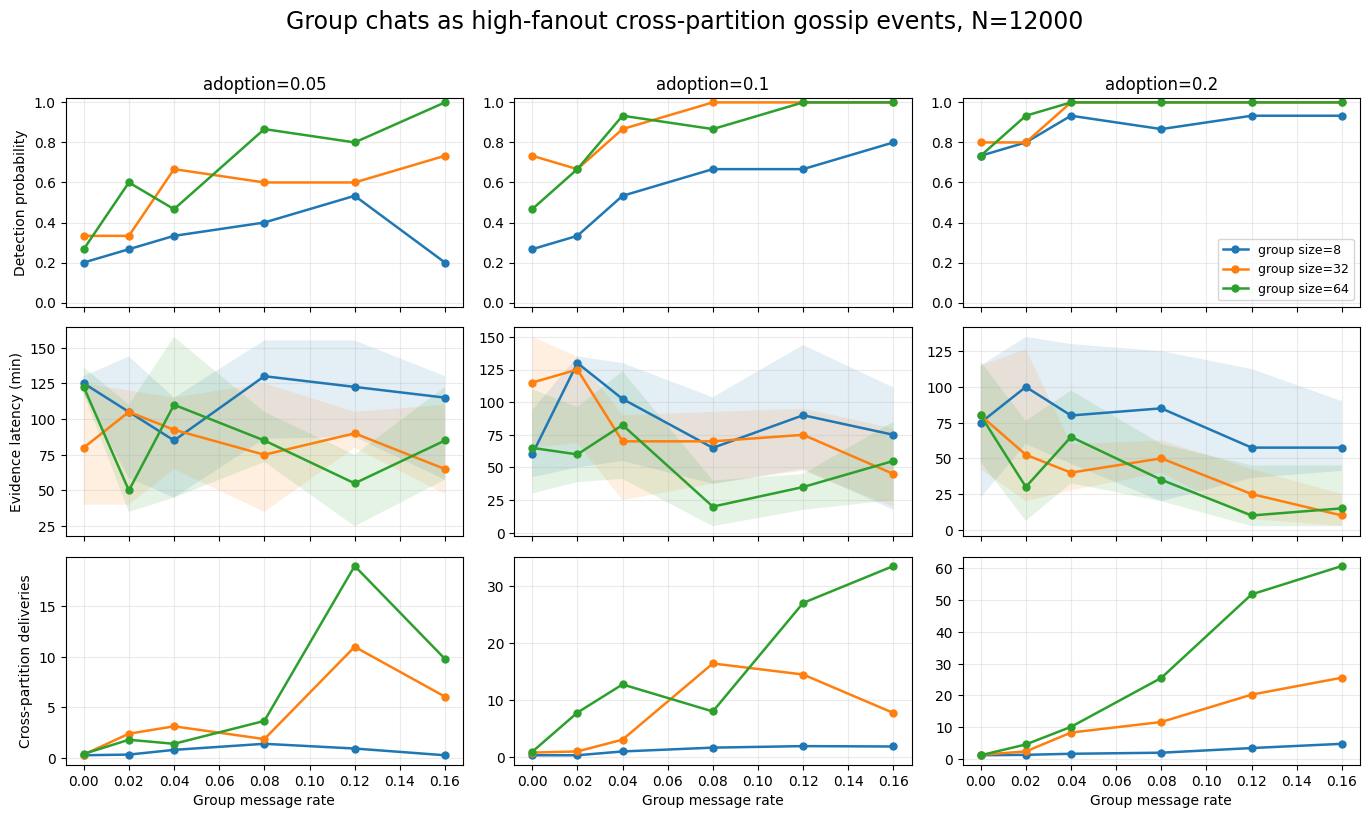

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_highfanout_connectivity\plots\fig_group_highfanout_connectivity_N12000.pdf


In [33]:
# =========================
# Generate dedicated group-connectivity figure
# =========================
plot_group_highfanout_connectivity(
    df_agg_group_hifan,
    df_agg_group_hifan_iqr,
    users=12000,
    x_col="msg_rate_group",
    line_col="avg_group_size",
    title="Group chats as high-fanout cross-partition gossip events",
)

In [18]:
# =========================
# Extra plot: improved censorship figure
# - clearer title
# - vertical guide at full suppression
# - explicit "no evidence" marking in latency row when undefined
# - lighter IQR shading
# =========================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PLOTS_CENSOR_EXTRA = OUT_CENSOR / "plots_extra"
PLOTS_CENSOR_EXTRA.mkdir(parents=True, exist_ok=True)

def plot_censor_improved(
    df_agg,
    df_iqr,
    users=12000,
    title="Censorship via cross-cut suppression",
):
    d1 = df_agg[df_agg["users"] == users].copy()
    d2 = df_iqr[df_iqr["users"] == users].copy()

    d1["adoption"] = d1["adoption"].astype(float)
    d1["p_gossip"] = d1["p_gossip"].astype(float)
    d1["p_drop_crosscut"] = d1["p_drop_crosscut"].astype(float)

    d2["adoption"] = d2["adoption"].astype(float)
    d2["p_gossip"] = d2["p_gossip"].astype(float)
    d2["p_drop_crosscut"] = d2["p_drop_crosscut"].astype(float)

    adoption_order = sorted(d1["adoption"].dropna().unique())
    pg_order = sorted(d1["p_gossip"].dropna().unique())

    fig, axes = plt.subplots(3, len(adoption_order), figsize=(13.5, 8.0), sharex="col")
    fig.suptitle(f"{title}, N={users}", y=0.98, fontsize=17)

    for j, a in enumerate(adoption_order):
        ax_top = axes[0, j]
        ax_mid = axes[1, j]
        ax_bot = axes[2, j]

        d1a = d1[np.isclose(d1["adoption"], a)].copy()
        d2a = d2[np.isclose(d2["adoption"], a)].copy()

        for pg in pg_order:
            s1 = d1a[np.isclose(d1a["p_gossip"], pg)].sort_values("p_drop_crosscut")
            s2 = d2a[np.isclose(d2a["p_gossip"], pg)].sort_values("p_drop_crosscut")

            x1 = s1["p_drop_crosscut"].to_numpy(dtype=float)
            y_det = s1["detected_rate"].to_numpy(dtype=float)
            y_ovh = s1["bpd_mean"].to_numpy(dtype=float)

            x2 = s2["p_drop_crosscut"].to_numpy(dtype=float)
            y_lat = s2["lat_ev_med"].to_numpy(dtype=float)
            y25 = s2["lat_ev_q25"].to_numpy(dtype=float) if "lat_ev_q25" in s2.columns else None
            y75 = s2["lat_ev_q75"].to_numpy(dtype=float) if "lat_ev_q75" in s2.columns else None

            lab = fr"$p_g$={pg:g}"

            # Top: detection
            m_det = np.isfinite(x1) & np.isfinite(y_det)
            if m_det.any():
                ax_top.plot(x1[m_det], y_det[m_det], marker="o", linewidth=1.8, markersize=5, label=lab)

            # Middle: latency + IQR
            if y25 is not None and y75 is not None:
                m_band = np.isfinite(x2) & np.isfinite(y25) & np.isfinite(y75)
                if m_band.any():
                    ax_mid.fill_between(x2[m_band], y25[m_band], y75[m_band], alpha=0.10)

            m_lat = np.isfinite(x2) & np.isfinite(y_lat)
            if m_lat.any():
                ax_mid.plot(x2[m_lat], y_lat[m_lat], marker="o", linewidth=1.8, markersize=5)

            # Explicitly mark "no evidence" at full suppression if last point is undefined
            if len(x2) > 0:
                full_mask = np.isclose(x2, 1.0)
                if full_mask.any():
                    idx = np.where(full_mask)[0][0]
                    if not np.isfinite(y_lat[idx]):
                        y_anchor = ax_mid.get_ylim()[1] if ax_mid.get_ylim()[1] > 0 else 1.0
                        ax_mid.plot([1.0], [0.92 * y_anchor], marker="x", markersize=7, linestyle="None")
                        ax_mid.annotate(
                            "no evidence",
                            xy=(1.0, 0.92 * y_anchor),
                            xytext=(-8, 4),
                            textcoords="offset points",
                            fontsize=7,
                            ha="right",
                        )

            # Bottom: overhead
            m_ovh = np.isfinite(x1) & np.isfinite(y_ovh)
            if m_ovh.any():
                ax_bot.plot(x1[m_ovh], y_ovh[m_ovh], marker="o", linewidth=1.8, markersize=5, label=lab)

        # Common formatting per column
        for ax in (ax_top, ax_mid, ax_bot):
            ax.axvline(1.0, linestyle="--", linewidth=0.9, alpha=0.7)
            ax.grid(True, alpha=0.25)

        ax_top.set_title(f"adoption={a:g}")
        ax_top.set_ylim(-0.02, 1.02)

        if j == 0:
            ax_top.set_ylabel("Detection probability")
            ax_mid.set_ylabel("Evidence latency (min)")
            ax_bot.set_ylabel("Overhead (B / delivered msg)")

        ax_bot.set_xlabel("Cross-cut drop probability")
        ax_bot.annotate(
            "full\nsuppression",
            xy=(1.0, ax_bot.get_ylim()[1] if ax_bot.get_ylim()[1] > 0 else 1.0),
            xytext=(-6, -6),
            textcoords="offset points",
            fontsize=7,
            ha="right",
            va="top",
        )

    axes[0, -1].legend(fontsize=9, frameon=True, loc="lower left")

    fig.tight_layout(rect=[0, 0, 1, 0.965])

    outbase = PLOTS_CENSOR_EXTRA / f"fig_censor_improved_N{users}"
    fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

    plt.show()
    print("Wrote:", outbase.with_suffix(".pdf").resolve())


plot_censor_improved(
    df_agg_censor,
    df_agg_censor_iqr,
    users=12000,
    title="Censorship via cross-cut suppression",
)

NameError: name 'df_agg_censor_iqr' is not defined

## Protocol Mode Comparison

In [116]:
# =========================
# Scenario: KT server cost comparison
# root-only vs root+consistency-proof
# Representative regime, fixed adoption
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_SERVERCMP = OUT_ROOT / "scenario_server_cost_compare"

# IMPORTANT:
# Replace ROOT_ONLY_MODE with the exact mode string from HELP_TEXT / your simulator.
ROOT_ONLY_MODE = "sth_only"   # <-- EDIT THIS if needed
PROOF_MODE = "sth_proof"

BASE_SERVERCMP = dict(BASE_SMALL)
BASE_SERVERCMP.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",

    msg_rate_1to1=0.20,
    msg_rate_group=0.08,

    # moderately hard but non-degenerate regime
    fork_frac=0.02,
    p_contact_cross=0.01,
    p_group_cross=0.01,

    p_drop_crosscut=0.0,
    sticky_victims=True,

    adoption=0.20,
)

MODE_GRID_SERVERCMP = [ROOT_ONLY_MODE, PROOF_MODE]
P_GOSSIP_GRID_SERVERCMP = [0.003, 0.005, 0.008, 0.012, 0.020, 0.030, 0.050]

REPS_SERVERCMP = 10
SEED_BASE_SERVERCMP = 55000

GROUP_COLS_SERVERCMP = [
    "users",
    "mode",
    "adoption",
    "p_gossip",
    "server_mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

In [117]:
# =========================
# Scenario: KT server cost comparison
# root-only vs root+consistency-proof
# Representative regime, fixed adoption
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_SERVERCMP = OUT_ROOT / "scenario_server_cost_compare"

# IMPORTANT:
# Replace ROOT_ONLY_MODE with the exact mode string from HELP_TEXT / your simulator.
ROOT_ONLY_MODE = "sth_only"   # <-- EDIT THIS if needed
PROOF_MODE = "sth_proof"

BASE_SERVERCMP = dict(BASE_SMALL)
BASE_SERVERCMP.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",

    msg_rate_1to1=0.20,
    msg_rate_group=0.08,

    # moderately hard but non-degenerate regime
    fork_frac=0.02,
    p_contact_cross=0.01,
    p_group_cross=0.01,

    p_drop_crosscut=0.0,
    sticky_victims=True,

    adoption=0.20,
)

MODE_GRID_SERVERCMP = [ROOT_ONLY_MODE, PROOF_MODE]
P_GOSSIP_GRID_SERVERCMP = [0.003, 0.005, 0.008, 0.012, 0.020, 0.030, 0.050]

REPS_SERVERCMP = 10
SEED_BASE_SERVERCMP = 55000

GROUP_COLS_SERVERCMP = [
    "users",
    "mode",
    "adoption",
    "p_gossip",
    "server_mode",
    "fork_frac",
    "p_contact_cross",
    "p_group_cross",
    "p_drop_crosscut",
]

In [118]:
# =========================
# Run KT server cost comparison
# =========================

OUT_SERVERCMP.mkdir(parents=True, exist_ok=True)

SWEEP_SERVERCMP = dict(
    mode=MODE_GRID_SERVERCMP,
    p_gossip=P_GOSSIP_GRID_SERVERCMP,
)

df_raw_servercmp = run_grid(
    BASE_SERVERCMP,
    SWEEP_SERVERCMP,
    replicates=REPS_SERVERCMP,
    seed_base=SEED_BASE_SERVERCMP,
    outroot=OUT_SERVERCMP,
    detection_policy="strict",
).copy()

df_raw_servercmp.to_csv(OUT_SERVERCMP / "raw.csv", index=False)

print("Wrote:", (OUT_SERVERCMP / "raw.csv").resolve())
display(df_raw_servercmp.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\permanent_fork_sth_only_n12000_pg0p003_a0p2_ff0p02_s55000_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\permanent_fork_sth_only_n12000_pg0p003_a0p2_ff0p02_s55000_drop0_pc0p01_pgc0p01/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\permanent_fork_sth_only_n12000_pg0p003_a0p2_ff0p02_s55001_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\permanent_fork_sth_only_n12000_pg0p003_a0p2_ff0p02_s55001_drop0_pc0p01_pgc0p01/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\permanent_fork_sth_only_n12000_pg0p003_a0p2_ff0p02_s55002_drop0_pc0p01_pgc0p01/summary.json and C:\Users\efasllija\dev\gossip-poc\

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,sticky_victims,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir
0,permanent_fork,sth_only,12000,6.0,5.0,0.003,0.2,0.02,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,1.022943,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
1,permanent_fork,sth_only,12000,6.0,5.0,0.003,0.2,0.02,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,1.014830,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
2,permanent_fork,sth_only,12000,6.0,5.0,0.003,0.2,0.02,3.0,False,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.944978,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
3,permanent_fork,sth_only,12000,6.0,5.0,0.003,0.2,0.02,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,1.006072,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...
4,permanent_fork,sth_only,12000,6.0,5.0,0.003,0.2,0.02,3.0,True,...,True,0.2,0.08,800,10,0.0,0.0,0.0,0.969263,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...


In [119]:
# =========================
# Build KT-server cost summary
# Focus on proof-related server work
# =========================

PROOF_COLS = ["proof_ok", "proof_inconsistent", "proof_withhold", "proof_timeout"]

missing = [c for c in PROOF_COLS if c not in df_raw_servercmp.columns]
if missing:
    raise ValueError(
        f"Missing proof-related columns in raw dataframe: {missing}. "
        "This comparison requires proof counters in the simulator output."
    )

work = df_raw_servercmp.copy()

work["proof_requests"] = (
    work["proof_ok"].fillna(0).astype(float)
    + work["proof_inconsistent"].fillna(0).astype(float)
    + work["proof_withhold"].fillna(0).astype(float)
    + work["proof_timeout"].fillna(0).astype(float)
)

work["proof_successes"] = (
    work["proof_ok"].fillna(0).astype(float)
    + work["proof_inconsistent"].fillna(0).astype(float)
)

work["proof_failures"] = (
    work["proof_withhold"].fillna(0).astype(float)
    + work["proof_timeout"].fillna(0).astype(float)
)

if "total_messages" in work.columns:
    denom = work["total_messages"].replace(0, np.nan).astype(float)
    work["proof_requests_per_msg"] = work["proof_requests"] / denom
else:
    work["proof_requests_per_msg"] = np.nan

if {"adoption", "users", "hours"}.issubset(work.columns):
    denom = (
        work["adoption"].astype(float)
        * work["users"].astype(float)
        * work["hours"].astype(float)
    ).replace(0, np.nan)
    work["proof_requests_per_adopted_user_hour"] = work["proof_requests"] / denom
else:
    work["proof_requests_per_adopted_user_hour"] = np.nan

df_agg_servercmp = (
    work.groupby(GROUP_COLS_SERVERCMP, dropna=False)
    .agg(
        reps=("run_dir", "count"),
        proof_requests_mean=("proof_requests", "mean"),
        proof_successes_mean=("proof_successes", "mean"),
        proof_failures_mean=("proof_failures", "mean"),
        proof_requests_per_msg_mean=("proof_requests_per_msg", "mean"),
        proof_requests_per_adopted_user_hour_mean=("proof_requests_per_adopted_user_hour", "mean"),
        detected_rate=("detected", "mean"),
        bpd_mean=("bytes_per_delivery", "mean"),
    )
    .reset_index()
)

df_agg_servercmp.to_csv(OUT_SERVERCMP / "agg_server_cost.csv", index=False)

print("Wrote:", (OUT_SERVERCMP / "agg_server_cost.csv").resolve())
display(df_agg_servercmp.head())

ValueError: Missing proof-related columns in raw dataframe: ['proof_ok', 'proof_withhold', 'proof_timeout']. This comparison requires proof counters in the simulator output.

In [124]:
# =========================
# Plotter: KT server cost comparison
# =========================

PLOTS_SERVERCMP = OUT_SERVERCMP / "plots"
PLOTS_SERVERCMP.mkdir(parents=True, exist_ok=True)

def plot_server_cost_compare(
    df_agg,
    users=12000,
    adoption_fixed=0.20,
    outdir=None,
    stem="fig_server_cost_compare_a02",
    title="KT server cost: root-only vs root+consistency proof",
):
    d = df_agg[df_agg["users"] == users].copy()
    if d.empty:
        raise ValueError(f"No rows found for users={users}")

    d["mode"] = d["mode"].astype(str)
    d["adoption"] = d["adoption"].astype(float)
    d["p_gossip"] = d["p_gossip"].astype(float)

    d = d[np.isclose(d["adoption"], adoption_fixed)].copy()
    if d.empty:
        raise ValueError(f"No rows found for adoption={adoption_fixed}")

    mode_order = list(d["mode"].dropna().unique())

    fig = plt.figure(figsize=(3.95, 6.95))
    gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 1.0, 1.0], hspace=0.34)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[2, 0])

    for mode in mode_order:
        s = d[d["mode"] == mode].sort_values("p_gossip")
        x = s["p_gossip"].to_numpy(dtype=float)

        y1 = s["proof_requests_mean"].to_numpy(dtype=float)
        m1 = np.isfinite(x) & np.isfinite(y1)
        if m1.any():
            ax1.plot(x[m1], y1[m1], marker="o", linewidth=1.8, markersize=4.2, label=mode)

        y2 = s["proof_requests_per_msg_mean"].to_numpy(dtype=float)
        m2 = np.isfinite(x) & np.isfinite(y2)
        if m2.any():
            ax2.plot(x[m2], y2[m2], marker="o", linewidth=1.8, markersize=4.2)

        y3 = s["detected_rate"].to_numpy(dtype=float)
        m3 = np.isfinite(x) & np.isfinite(y3)
        if m3.any():
            ax3.plot(x[m3], y3[m3], marker="o", linewidth=1.8, markersize=4.2)

    for ax in (ax1, ax2, ax3):
        ax.set_xscale("log")
        ax.grid(True, alpha=0.25, which="both")

    ax1.set_title(f"{title}, N={users}, adoption={adoption_fixed:g}")
    ax1.set_ylabel("Proof requests\nper run")
    ax2.set_ylabel("Proof requests /\ndelivered msg")
    ax3.set_ylabel("Detection\nprobability")
    ax3.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")
    ax3.set_ylim(-0.02, 1.02)

    ax1.legend(fontsize=8, frameon=True, loc="upper left")

    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

In [120]:
print(sorted(df_raw_servercmp.columns))

['adoption', 'avg_group_size', 'aware_cov_end', 'bytes_per_delivery', 'bytes_per_send', 'crosscut_rate', 'crosscuts', 'detected', 'dt_min', 'evid_cov_end', 'evidence_events', 'fork_frac', 'fork_hour', 'groups', 'hours', 'invalid_proof_rate', 'lat_aw_min', 'lat_ev_min', 'mode', 'msg_rate_1to1', 'msg_rate_group', 'msgs_10_ev', 'msgs_50_ev', 'msgs_95_ev', 'msgs_first_ev', 'p_contact_cross', 'p_drop_crosscut', 'p_gossip', 'p_group_cross', 'proof_inconsistent', 'proof_timeout_rate', 'proof_withhold_rate', 'run_dir', 'seed', 'server_mode', 'sticky_victims', 't10_aw', 't10_ev', 't50_aw', 't50_ev', 'users', 'wall_s']


In [121]:
# =========================
# Patch df_raw_servercmp with proof counters from each run's summary.json
# =========================

import json
from pathlib import Path
import pandas as pd
import numpy as np

SUMMARY_KEYS_TO_PULL = [
    "proof_ok",
    "proof_inconsistent",
    "proof_withhold",
    "proof_timeout",
    "total_messages",
    "total_gossip_bytes",
]

if "run_dir" not in df_raw_servercmp.columns:
    raise ValueError("df_raw_servercmp has no 'run_dir' column, so I cannot patch from per-run summaries.")

rows = []

for rd in df_raw_servercmp["run_dir"].astype(str):
    run_path = Path(rd)
    summary_path = run_path / "summary.json"

    rec = {"run_dir": rd}

    if summary_path.exists():
        with open(summary_path, "r") as f:
            summ = json.load(f)

        for k in SUMMARY_KEYS_TO_PULL:
            rec[k] = summ.get(k, np.nan)
    else:
        # keep row so merge still works; values remain NaN
        for k in SUMMARY_KEYS_TO_PULL:
            rec[k] = np.nan

    rows.append(rec)

df_summary_patch = pd.DataFrame(rows)

# merge only missing columns or overwrite NaN-only columns safely
df_raw_servercmp = df_raw_servercmp.drop(columns=[c for c in SUMMARY_KEYS_TO_PULL if c in df_raw_servercmp.columns], errors="ignore")
df_raw_servercmp = df_raw_servercmp.merge(df_summary_patch, on="run_dir", how="left")

print("Patched columns now available:")
print([c for c in SUMMARY_KEYS_TO_PULL if c in df_raw_servercmp.columns])
display(df_raw_servercmp[["run_dir"] + [c for c in SUMMARY_KEYS_TO_PULL if c in df_raw_servercmp.columns]].head())

Patched columns now available:
['proof_ok', 'proof_inconsistent', 'proof_withhold', 'proof_timeout', 'total_messages', 'total_gossip_bytes']


,run_dir,proof_ok,proof_inconsistent,proof_withhold,proof_timeout,total_messages,total_gossip_bytes
0,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0,1,0,0,64751,11648
1,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0,1,0,0,66850,5760
2,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0,0,0,0,64192,4096
3,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0,2,0,0,69153,7808
4,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,0,1,0,0,66382,7936


In [122]:
# =========================
# Recompute KT-server-cost summary after patching proof counters
# =========================

PROOF_COLS = ["proof_ok", "proof_inconsistent", "proof_withhold", "proof_timeout"]
missing = [c for c in PROOF_COLS if c not in df_raw_servercmp.columns]

if missing:
    raise ValueError(f"Still missing proof-related columns after patch: {missing}")

work = df_raw_servercmp.copy()

for c in PROOF_COLS:
    work[c] = pd.to_numeric(work[c], errors="coerce").fillna(0)

work["proof_requests"] = (
    work["proof_ok"]
    + work["proof_inconsistent"]
    + work["proof_withhold"]
    + work["proof_timeout"]
)

work["proof_successes"] = work["proof_ok"] + work["proof_inconsistent"]
work["proof_failures"] = work["proof_withhold"] + work["proof_timeout"]

if "total_messages" in work.columns:
    work["proof_requests_per_msg"] = work["proof_requests"] / pd.to_numeric(work["total_messages"], errors="coerce").replace(0, np.nan)
else:
    work["proof_requests_per_msg"] = np.nan

if {"adoption", "users", "hours"}.issubset(work.columns):
    denom = (
        pd.to_numeric(work["adoption"], errors="coerce")
        * pd.to_numeric(work["users"], errors="coerce")
        * pd.to_numeric(work["hours"], errors="coerce")
    ).replace(0, np.nan)
    work["proof_requests_per_adopted_user_hour"] = work["proof_requests"] / denom
else:
    work["proof_requests_per_adopted_user_hour"] = np.nan

df_agg_servercmp = (
    work.groupby(GROUP_COLS_SERVERCMP, dropna=False)
    .agg(
        reps=("run_dir", "count"),
        proof_requests_mean=("proof_requests", "mean"),
        proof_successes_mean=("proof_successes", "mean"),
        proof_failures_mean=("proof_failures", "mean"),
        proof_requests_per_msg_mean=("proof_requests_per_msg", "mean"),
        proof_requests_per_adopted_user_hour_mean=("proof_requests_per_adopted_user_hour", "mean"),
        detected_rate=("detected", "mean"),
        bpd_mean=("bytes_per_delivery", "mean"),
    )
    .reset_index()
)

df_agg_servercmp.to_csv(OUT_SERVERCMP / "agg_server_cost.csv", index=False)

print("Wrote:", (OUT_SERVERCMP / "agg_server_cost.csv").resolve())
display(df_agg_servercmp.head())

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\agg_server_cost.csv


,users,mode,adoption,p_gossip,server_mode,fork_frac,p_contact_cross,p_group_cross,p_drop_crosscut,reps,proof_requests_mean,proof_successes_mean,proof_failures_mean,proof_requests_per_msg_mean,proof_requests_per_adopted_user_hour_mean,detected_rate,bpd_mean
0,12000,sth_only,0.2,0.003,permanent_fork,0.02,0.01,0.01,0.0,10,1.4,1.4,0.0,0.000021,0.000097,0.6,0.087869
1,12000,sth_only,0.2,0.005,permanent_fork,0.02,0.01,0.01,0.0,10,2.0,2.0,0.0,0.000030,0.000139,0.8,0.159071
2,12000,sth_only,0.2,0.008,permanent_fork,0.02,0.01,0.01,0.0,10,3.3,3.3,0.0,0.000050,0.000229,0.9,0.232797
3,12000,sth_only,0.2,0.012,permanent_fork,0.02,0.01,0.01,0.0,10,5.5,5.5,0.0,0.000084,0.000382,1.0,0.325473
4,12000,sth_only,0.2,0.020,permanent_fork,0.02,0.01,0.01,0.0,10,8.8,8.8,0.0,0.000133,0.000611,1.0,0.514136


C:\Users\efasllija\AppData\Local\Temp\ipykernel_25244\4080831210.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\plots\fig_server_cost_compare_a02.pdf


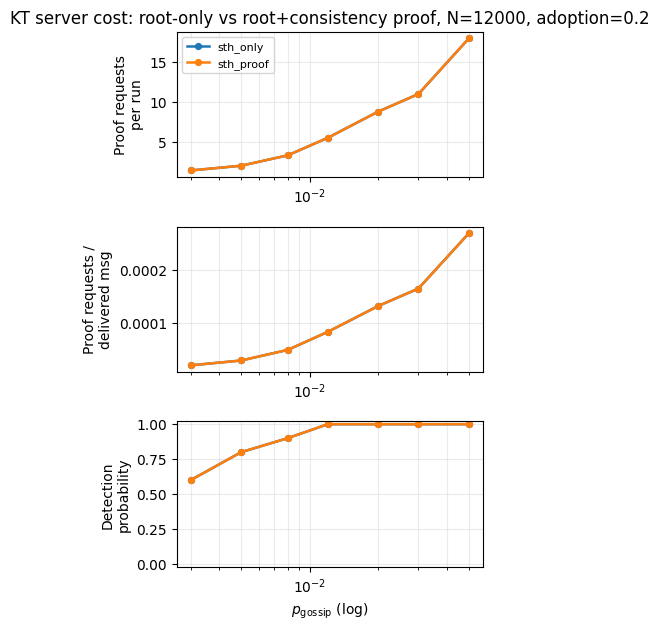

In [125]:
plot_server_cost_compare(
    df_agg_servercmp,
    users=12000,
    adoption_fixed=0.20,
    outdir=PLOTS_SERVERCMP,
    stem="fig_server_cost_compare_a02",
)

In [126]:
# =========================
# KT-server cost table at selected operating points
# Uses df_agg_servercmp already computed
# =========================

import numpy as np
import pandas as pd
from pathlib import Path

TABLES_SERVERCMP = OUT_SERVERCMP / "tables"
TABLES_SERVERCMP.mkdir(parents=True, exist_ok=True)

# Edit only if your mode names differ
ROOT_ONLY_MODE = "sth_only"
PROOF_MODE = "sth_proof"

USERS_SERVERCMP = 12000
ADOPTION_SERVERCMP = 0.20

# Representative operating points to report in the paper
PG_REPORT = [0.005, 0.01, 0.02]

req_cols = [
    "users", "mode", "adoption", "p_gossip",
    "proof_requests_mean",
    "proof_requests_per_msg_mean",
    "proof_requests_per_adopted_user_hour_mean",
    "detected_rate",
]

missing = [c for c in req_cols if c not in df_agg_servercmp.columns]
if missing:
    raise ValueError(f"df_agg_servercmp is missing required columns: {missing}")

d = df_agg_servercmp.copy()
d["users"] = pd.to_numeric(d["users"], errors="coerce")
d["adoption"] = pd.to_numeric(d["adoption"], errors="coerce")
d["p_gossip"] = pd.to_numeric(d["p_gossip"], errors="coerce")
d["mode"] = d["mode"].astype(str)

d = d[
    np.isclose(d["users"], USERS_SERVERCMP) &
    np.isclose(d["adoption"], ADOPTION_SERVERCMP)
].copy()

# keep only requested p_g values
d = d[d["p_gossip"].isin(PG_REPORT)].copy()

proof = (
    d[d["mode"] == PROOF_MODE][[
        "p_gossip",
        "detected_rate",
        "proof_requests_mean",
        "proof_requests_per_msg_mean",
        "proof_requests_per_adopted_user_hour_mean",
    ]]
    .rename(columns={
        "detected_rate": "det_prob_proof",
        "proof_requests_mean": "proof_req_per_run",
        "proof_requests_per_msg_mean": "proof_req_per_msg",
        "proof_requests_per_adopted_user_hour_mean": "proof_req_per_adopted_user_hour",
    })
)

root = (
    d[d["mode"] == ROOT_ONLY_MODE][["p_gossip", "detected_rate"]]
    .rename(columns={"detected_rate": "det_prob_root_only"})
)

tbl_servercmp = (
    proof.merge(root, on="p_gossip", how="left")
    .sort_values("p_gossip")
    .reset_index(drop=True)
)

# More readable normalization
tbl_servercmp["proof_req_per_1000_msgs"] = 1000.0 * tbl_servercmp["proof_req_per_msg"]

# Incremental server cost over root-only
# (root-only proof-serving cost is expected to be ~0)
tbl_servercmp["added_proof_req_per_run"] = tbl_servercmp["proof_req_per_run"]
tbl_servercmp["added_proof_req_per_1000_msgs"] = tbl_servercmp["proof_req_per_1000_msgs"]
tbl_servercmp["added_proof_req_per_adopted_user_hour"] = tbl_servercmp["proof_req_per_adopted_user_hour"]

# Reorder / round for paper readability
tbl_servercmp_paper = tbl_servercmp[[
    "p_gossip",
    "det_prob_root_only",
    "det_prob_proof",
    "added_proof_req_per_run",
    "added_proof_req_per_1000_msgs",
    "added_proof_req_per_adopted_user_hour",
]].copy()

tbl_servercmp_paper = tbl_servercmp_paper.rename(columns={
    "p_gossip": "p_gossip",
    "det_prob_root_only": "det_root_only",
    "det_prob_proof": "det_proof",
    "added_proof_req_per_run": "added_req_run",
    "added_proof_req_per_1000_msgs": "added_req_1k_msgs",
    "added_proof_req_per_adopted_user_hour": "added_req_user_hr",
})

tbl_servercmp_paper["det_root_only"] = tbl_servercmp_paper["det_root_only"].round(3)
tbl_servercmp_paper["det_proof"] = tbl_servercmp_paper["det_proof"].round(3)
tbl_servercmp_paper["added_req_run"] = tbl_servercmp_paper["added_req_run"].round(2)
tbl_servercmp_paper["added_req_1k_msgs"] = tbl_servercmp_paper["added_req_1k_msgs"].round(3)
tbl_servercmp_paper["added_req_user_hr"] = tbl_servercmp_paper["added_req_user_hr"].round(5)

display(tbl_servercmp_paper)

tbl_servercmp_paper.to_csv(TABLES_SERVERCMP / "server_cost_operating_points.csv", index=False)
print("Wrote:", (TABLES_SERVERCMP / "server_cost_operating_points.csv").resolve())

,p_gossip,det_root_only,det_proof,added_req_run,added_req_1k_msgs,added_req_user_hr
0,0.005,0.8,0.8,2.0,0.030,0.00014
1,0.020,1.0,1.0,8.8,0.133,0.00061


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\tables\server_cost_operating_points.csv


In [127]:
# =========================
# KT-server sweet-spot summary
# Smallest p_gossip where proof mode reaches detection >= threshold
# =========================

DET_TARGET_SERVERCMP = 0.95

d = df_agg_servercmp.copy()
d["users"] = pd.to_numeric(d["users"], errors="coerce")
d["adoption"] = pd.to_numeric(d["adoption"], errors="coerce")
d["p_gossip"] = pd.to_numeric(d["p_gossip"], errors="coerce")
d["mode"] = d["mode"].astype(str)

proof = d[
    np.isclose(d["users"], USERS_SERVERCMP) &
    np.isclose(d["adoption"], ADOPTION_SERVERCMP) &
    (d["mode"] == PROOF_MODE)
].copy().sort_values("p_gossip")

sweet = proof[proof["detected_rate"] >= DET_TARGET_SERVERCMP].copy()

if sweet.empty:
    sweet_spot = pd.DataFrame([{
        "users": USERS_SERVERCMP,
        "adoption": ADOPTION_SERVERCMP,
        "det_target": DET_TARGET_SERVERCMP,
        "p_gossip_star": np.nan,
        "det_prob_proof": np.nan,
        "added_req_run": np.nan,
        "added_req_1k_msgs": np.nan,
        "added_req_user_hr": np.nan,
    }])
else:
    s = sweet.iloc[0]
    sweet_spot = pd.DataFrame([{
        "users": USERS_SERVERCMP,
        "adoption": ADOPTION_SERVERCMP,
        "det_target": DET_TARGET_SERVERCMP,
        "p_gossip_star": float(s["p_gossip"]),
        "det_prob_proof": round(float(s["detected_rate"]), 3),
        "added_req_run": round(float(s["proof_requests_mean"]), 2),
        "added_req_1k_msgs": round(1000.0 * float(s["proof_requests_per_msg_mean"]), 3),
        "added_req_user_hr": round(float(s["proof_requests_per_adopted_user_hour_mean"]), 5),
    }])

display(sweet_spot)

sweet_spot.to_csv(TABLES_SERVERCMP / "server_cost_sweet_spot.csv", index=False)
print("Wrote:", (TABLES_SERVERCMP / "server_cost_sweet_spot.csv").resolve())

,users,adoption,det_target,p_gossip_star,det_prob_proof,added_req_run,added_req_1k_msgs,added_req_user_hr
0,12000,0.2,0.95,0.012,1.0,5.5,0.084,0.00038


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_server_cost_compare\tables\server_cost_sweet_spot.csv


In [128]:
# =========================
# Export LaTeX tables for the paper
# =========================

latex_operating = tbl_servercmp_paper.to_latex(
    index=False,
    escape=False,
    float_format=lambda x: f"{x:.3f}" if isinstance(x, float) else str(x),
    caption=(
        "Incremental KT-server cost of the proof-carrying variant "
        "at representative operating points ($N=12000$, adoption $=0.2$). "
        "The root-only variant has essentially zero proof-serving cost by design."
    ),
    label="tab:server-cost-operating-points",
)

latex_sweet = sweet_spot.to_latex(
    index=False,
    escape=False,
    float_format=lambda x: f"{x:.5f}" if isinstance(x, float) else str(x),
    caption=(
        "Smallest gossip probability at which the proof-carrying variant reaches "
        f"detection $\\ge {DET_TARGET_SERVERCMP:.2f}$, together with the corresponding "
        "incremental KT-server cost."
    ),
    label="tab:server-cost-sweet-spot",
)

with open(TABLES_SERVERCMP / "server_cost_operating_points.tex", "w") as f:
    f.write(latex_operating)

with open(TABLES_SERVERCMP / "server_cost_sweet_spot.tex", "w") as f:
    f.write(latex_sweet)

print(latex_operating)
print()
print(latex_sweet)

print("Wrote:", (TABLES_SERVERCMP / "server_cost_operating_points.tex").resolve())
print("Wrote:", (TABLES_SERVERCMP / "server_cost_sweet_spot.tex").resolve())

\begin{table}
\caption{Incremental KT-server cost of the proof-carrying variant at representative operating points ($N=12000$, adoption $=0.2$). The root-only variant has essentially zero proof-serving cost by design.}
\label{tab:server-cost-operating-points}
\begin{tabular}{rrrrrr}
\toprule
p_gossip & det_root_only & det_proof & added_req_run & added_req_1k_msgs & added_req_user_hr \\
\midrule
0.005 & 0.800 & 0.800 & 2.000 & 0.030 & 0.000 \\
0.020 & 1.000 & 1.000 & 8.800 & 0.133 & 0.001 \\
\bottomrule
\end{tabular}
\end{table}


\begin{table}
\caption{Smallest gossip probability at which the proof-carrying variant reaches detection $\ge 0.95$, together with the corresponding incremental KT-server cost.}
\label{tab:server-cost-sweet-spot}
\begin{tabular}{rrrrrrrr}
\toprule
users & adoption & det_target & p_gossip_star & det_prob_proof & added_req_run & added_req_1k_msgs & added_req_user_hr \\
\midrule
12000 & 0.20000 & 0.95000 & 0.01200 & 1.00000 & 5.50000 & 0.08400 & 0.00038 \\
\botto

## Scenario for fan-out advantage of cross-partition GROUPS

In [32]:
# =========================
# Scenario: GROUP FANOUT / CROSS-PARTITION GROUPS
# Goal: isolate the benefit of group messages as high-fanout comparison opportunities
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

OUT_GROUP_FANOUT = OUT_ROOT / "scenario_group_fanout"

BASE_GROUP_FANOUT = dict(BASE_SMALL)
BASE_GROUP_FANOUT.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # Moderate deployment, moderately hard regime so structure matters
    adoption=0.20,
    p_gossip=0.01,
    fork_frac=0.05,

    # Keep pairwise cross-partition opportunities scarce
    p_contact_cross=0.005,

    # Group topology present in all conditions; only usage/cross-mixing changes
    groups=2000,
    avg_group_size=6,

    # no censorship
    p_drop_crosscut=0.0,
    sticky_victims=True,
)

# Keep total sender-action rate roughly fixed:
# msg_rate_1to1 + msg_rate_group = 0.28
STRUCTURES_GROUP_FANOUT = [
    {
        "structure": "1:1 only",
        "msg_rate_1to1": 0.28,
        "msg_rate_group": 0.00,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups\nwithin-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups\ncross-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.05,
    },
]

REPS_GROUP_FANOUT = 12
SEED_BASE_GROUP_FANOUT = 59000

EVID_PROP_HORIZON_MIN = 30.0

In [33]:
# =========================
# Run group fanout scenario
# =========================

OUT_GROUP_FANOUT.mkdir(parents=True, exist_ok=True)

parts = []

for i, s in enumerate(STRUCTURES_GROUP_FANOUT):
    cfg = dict(BASE_GROUP_FANOUT)
    cfg.update(
        msg_rate_1to1=s["msg_rate_1to1"],
        msg_rate_group=s["msg_rate_group"],
        p_group_cross=s["p_group_cross"],
    )

    outdir = OUT_GROUP_FANOUT / f"cond_{i+1}"
    outdir.mkdir(parents=True, exist_ok=True)

    # use singleton sweep for fixed p_gossip so run_grid has a parameter grid
    cfg.pop("p_gossip", None)
    sweep_cfg = dict(p_gossip=[BASE_GROUP_FANOUT["p_gossip"]])

    df_part = run_grid(
        cfg,
        sweep_cfg,
        replicates=REPS_GROUP_FANOUT,
        seed_base=SEED_BASE_GROUP_FANOUT + 1000 * i,
        outroot=outdir,
        detection_policy="strict",
    ).copy()

    df_part["structure"] = s["structure"]
    df_part["msg_rate_1to1"] = s["msg_rate_1to1"]
    df_part["msg_rate_group"] = s["msg_rate_group"]
    df_part["p_group_cross"] = s["p_group_cross"]

    parts.append(df_part)

df_raw_group_fanout = pd.concat(parts, ignore_index=True)
df_raw_group_fanout.to_csv(OUT_GROUP_FANOUT / "raw.csv", index=False)

print("Wrote:", (OUT_GROUP_FANOUT / "raw.csv").resolve())
display(df_raw_group_fanout.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\cond_1\permanent_fork_sth_proof_n12000_pg0p01_a0p2_ff0p05_s59000_drop0_pc0p005_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\cond_1\permanent_fork_sth_proof_n12000_pg0p01_a0p2_ff0p05_s59000_drop0_pc0p005_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\cond_1\permanent_fork_sth_proof_n12000_pg0p01_a0p2_ff0p05_s59001_drop0_pc0p005_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\cond_1\permanent_fork_sth_proof_n12000_pg0p01_a0p2_ff0p05_s59001_drop0_pc0p005_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\cond_1\permanent_fork_sth_proof_n12000_pg0p01_a0p2_ff0p05_s59002_drop0_pc0p005_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_inc

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir,structure
0,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.2,0.05,3.0,True,...,0.28,0.0,2000,6,0.0,0.0,0.0,1.343948,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
1,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.2,0.05,3.0,True,...,0.28,0.0,2000,6,0.0,0.0,0.0,1.071007,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
2,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.2,0.05,3.0,True,...,0.28,0.0,2000,6,0.0,0.0,0.0,1.357134,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
3,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.2,0.05,3.0,True,...,0.28,0.0,2000,6,0.0,0.0,0.0,1.219963,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
4,permanent_fork,sth_proof,12000,6.0,5.0,0.01,0.2,0.05,3.0,True,...,0.28,0.0,2000,6,0.0,0.0,0.0,1.117634,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only


In [34]:
# =========================
# Derived metric: evidence dissemination after first detection
# fraction of clients with evidence within H minutes of first evidence
# =========================

from pathlib import Path

horizon_ticks = int(round(EVID_PROP_HORIZON_MIN / BASE_GROUP_FANOUT["dt_min"]))

rows = []

for _, r in df_raw_group_fanout.iterrows():
    run_dir = Path(r["run_dir"])
    events_path = run_dir / "events.csv"
    summary_path = run_dir / "summary.json"

    evid_frac_h = np.nan

    if events_path.exists():
        ev = pd.read_csv(events_path)

        # robust to both "evidence" and older "detect" tagging
        ev_e = ev[ev["event"].isin(["evidence", "detect"])].copy()

        if not ev_e.empty:
            first_tick = int(ev_e["tick"].min())
            cutoff = first_tick + horizon_ticks

            n_users_h = ev_e[ev_e["tick"] <= cutoff]["user"].nunique()
            users = int(r["users"]) if "users" in r and pd.notna(r["users"]) else BASE_GROUP_FANOUT["users"]
            evid_frac_h = n_users_h / users
        else:
            evid_frac_h = 0.0
    else:
        evid_frac_h = np.nan

    rows.append({
        "run_dir": r["run_dir"],
        "structure": r["structure"],
        "evid_frac_horizon": evid_frac_h,
    })

df_post_evidence_group = pd.DataFrame(rows)

df_raw_group_fanout = df_raw_group_fanout.merge(
    df_post_evidence_group,
    on=["run_dir", "structure"],
    how="left",
)

display(df_raw_group_fanout[["structure", "detected", "lat_ev_min", "evid_frac_horizon"]].head())

,structure,detected,lat_ev_min,evid_frac_horizon
0,1:1 only,True,40.0,0.000083
1,1:1 only,True,175.0,0.000083
2,1:1 only,True,100.0,0.000167
3,1:1 only,True,15.0,0.000083
4,1:1 only,True,120.0,0.000167


In [35]:
# =========================
# Aggregate group fanout outcomes
# =========================

def q25(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.25)) if x.size else np.nan

def q75(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.75)) if x.size else np.nan

def med_success_only(detected, lat):
    mask = pd.to_numeric(detected, errors="coerce").fillna(0).astype(bool)
    latv = pd.to_numeric(lat, errors="coerce")
    vals = latv[mask & latv.notna()].to_numpy()
    return float(np.median(vals)) if vals.size else np.nan

agg_rows = []

for structure, s in df_raw_group_fanout.groupby("structure", dropna=False):
    det = pd.to_numeric(s["detected"], errors="coerce").fillna(0)
    lat = pd.to_numeric(s["lat_ev_min"], errors="coerce")
    evid_prop = pd.to_numeric(s["evid_frac_horizon"], errors="coerce")

    agg_rows.append({
        "structure": structure,
        "detected_rate": float(det.mean()),
        "lat_ev_med": med_success_only(det, lat),
        "lat_ev_q25": q25(lat[det.astype(bool)]),
        "lat_ev_q75": q75(lat[det.astype(bool)]),
        f"evid_frac_{int(EVID_PROP_HORIZON_MIN)}m_mean": float(evid_prop.mean()),
    })

df_agg_group_fanout = pd.DataFrame(agg_rows)

order = [s["structure"] for s in STRUCTURES_GROUP_FANOUT]
df_agg_group_fanout["structure"] = pd.Categorical(df_agg_group_fanout["structure"], categories=order, ordered=True)
df_agg_group_fanout = df_agg_group_fanout.sort_values("structure").reset_index(drop=True)

df_agg_group_fanout.to_csv(OUT_GROUP_FANOUT / "agg.csv", index=False)

print("Wrote:", (OUT_GROUP_FANOUT / "agg.csv").resolve())
display(df_agg_group_fanout)

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\agg.csv


,structure,detected_rate,lat_ev_med,lat_ev_q25,lat_ev_q75,evid_frac_30m_mean
0,1:1 only,1.0,47.5,12.50,105.00,0.000111
1,Groups\nwithin-cut,1.0,22.5,13.75,41.25,0.000354
2,Groups\ncross-cut,1.0,45.0,17.50,65.00,0.000299


In [36]:
# =========================
# Plot: group fanout scenario
# Panels:
#   detection probability
#   evidence latency
#   evidence coverage 30 min after first evidence
# =========================

PLOTS_GROUP_FANOUT = OUT_GROUP_FANOUT / "plots"
PLOTS_GROUP_FANOUT.mkdir(parents=True, exist_ok=True)

def plot_group_fanout_scenario(
    df_agg,
    horizon_min=30.0,
    outdir=None,
    stem="fig_group_fanout_three_panel",
    title="Group messages as high-fanout comparison opportunities",
):
    d = df_agg.copy()

    labels = d["structure"].astype(str).tolist()
    x = np.arange(len(labels))

    fig = plt.figure(figsize=(9.2, 3.6))
    gs = fig.add_gridspec(1, 3, wspace=0.30)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])

    # Panel 1: detection probability
    y1 = pd.to_numeric(d["detected_rate"], errors="coerce").to_numpy(dtype=float)
    bars1 = ax1.bar(x, y1)
    ax1.set_ylim(0, 1.05)
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.set_ylabel("Detection probability")
    ax1.set_title("Views meet more often")
    ax1.grid(True, axis="y", alpha=0.25)

    # Panel 2: evidence latency
    y2 = pd.to_numeric(d["lat_ev_med"], errors="coerce").to_numpy(dtype=float)
    bars2 = ax2.bar(x, y2)
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.set_ylabel("Median evidence latency (min)")
    ax2.set_title("Detection happens faster")
    ax2.grid(True, axis="y", alpha=0.25)

    # Panel 3: evidence dissemination after first hit
    col3 = f"evid_frac_{int(horizon_min)}m_mean"
    y3 = pd.to_numeric(d[col3], errors="coerce").to_numpy(dtype=float)
    bars3 = ax3.bar(x, y3)
    ax3.set_ylim(0, 1.05)
    ax3.set_xticks(x)
    ax3.set_xticklabels(labels)
    ax3.set_ylabel(f"Evidence fraction\n{int(horizon_min)} min after first hit")
    ax3.set_title("Proof spreads faster")
    ax3.grid(True, axis="y", alpha=0.25)

    for ax, vals in [(ax1, y1), (ax2, y2), (ax3, y3)]:
        for xi, yi in zip(x, vals):
            if np.isfinite(yi):
                ax.annotate(
                    f"{yi:.2f}" if yi <= 1.05 else f"{yi:.1f}",
                    xy=(xi, yi),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    fig.suptitle(title, y=1.05, fontsize=14)
    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

C:\Users\efasllija\AppData\Local\Temp\ipykernel_43248\586271125.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_fanout\plots\fig_group_fanout_three_panel.pdf


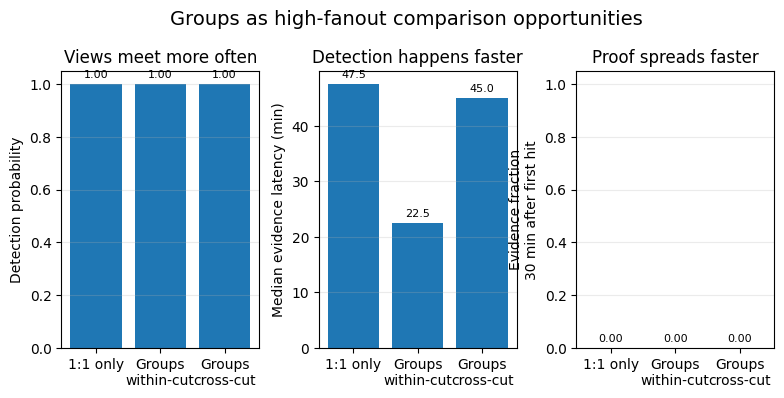

In [37]:
# =========================
# Generate group fanout figure
# =========================

plot_group_fanout_scenario(
    df_agg_group_fanout,
    horizon_min=EVID_PROP_HORIZON_MIN,
    outdir=PLOTS_GROUP_FANOUT,
    stem="fig_group_fanout_three_panel",
    title="Groups as high-fanout comparison opportunities",
)

## Attempt 2 at cross-partition Groups

In [38]:
# =========================
# Scenario: GROUP MEETING ADVANTAGE
# Goal: show that cross-cut groups increase the chance that forked views meet
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_GROUP_MEET = OUT_ROOT / "scenario_group_meeting_advantage"

BASE_GROUP_MEET = dict(BASE_SMALL)
BASE_GROUP_MEET.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # Make the regime hard enough that meeting opportunities matter
    adoption=0.10,
    fork_frac=0.05,

    # Make pairwise cross-cut contacts very rare
    p_contact_cross=0.001,

    # no censorship
    p_drop_crosscut=0.0,
    sticky_victims=True,

    # keep group topology available in all conditions
    groups=2500,
    avg_group_size=8,
)

# Keep total sender-action rate roughly fixed
# msg_rate_1to1 + msg_rate_group = 0.28
STRUCTURES_GROUP_MEET = [
    {
        "structure": "1:1 only",
        "msg_rate_1to1": 0.28,
        "msg_rate_group": 0.00,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups within-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups cross-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.20,
    },
]

P_GOSSIP_GRID_GROUP_MEET = [0.002, 0.003, 0.005, 0.008, 0.012, 0.020]

REPS_GROUP_MEET = 12
SEED_BASE_GROUP_MEET = 60000
DET_THR_GROUP_MEET = 0.95

In [39]:
# =========================
# Run group meeting advantage scenario
# =========================

OUT_GROUP_MEET.mkdir(parents=True, exist_ok=True)

parts = []

for i, s in enumerate(STRUCTURES_GROUP_MEET):
    cfg = dict(BASE_GROUP_MEET)
    cfg.update(
        msg_rate_1to1=s["msg_rate_1to1"],
        msg_rate_group=s["msg_rate_group"],
        p_group_cross=s["p_group_cross"],
    )

    outdir = OUT_GROUP_MEET / f"cond_{i+1}"
    outdir.mkdir(parents=True, exist_ok=True)

    df_part = run_grid(
        cfg,
        dict(p_gossip=P_GOSSIP_GRID_GROUP_MEET),
        replicates=REPS_GROUP_MEET,
        seed_base=SEED_BASE_GROUP_MEET + 1000 * i,
        outroot=outdir,
        detection_policy="strict",
    ).copy()

    df_part["structure"] = s["structure"]
    df_part["msg_rate_1to1"] = s["msg_rate_1to1"]
    df_part["msg_rate_group"] = s["msg_rate_group"]
    df_part["p_group_cross"] = s["p_group_cross"]

    parts.append(df_part)

df_raw_group_meet = pd.concat(parts, ignore_index=True)
df_raw_group_meet.to_csv(OUT_GROUP_MEET / "raw.csv", index=False)

print("Wrote:", (OUT_GROUP_MEET / "raw.csv").resolve())
display(df_raw_group_meet.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\cond_1\permanent_fork_sth_proof_n12000_pg0p002_a0p1_ff0p05_s60000_drop0_pc0p001_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\cond_1\permanent_fork_sth_proof_n12000_pg0p002_a0p1_ff0p05_s60000_drop0_pc0p001_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\cond_1\permanent_fork_sth_proof_n12000_pg0p002_a0p1_ff0p05_s60001_drop0_pc0p001_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\cond_1\permanent_fork_sth_proof_n12000_pg0p002_a0p1_ff0p05_s60001_drop0_pc0p001_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\cond_1\permanent_fork_sth_proof_n12000_pg0p002_a0p1_ff0p05_s60002_drop0_pc0p001_pgc0/s

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir,structure
0,permanent_fork,sth_proof,12000,6.0,5.0,0.002,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.174221,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
1,permanent_fork,sth_proof,12000,6.0,5.0,0.002,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.171252,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
2,permanent_fork,sth_proof,12000,6.0,5.0,0.002,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.090733,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
3,permanent_fork,sth_proof,12000,6.0,5.0,0.002,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.120316,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
4,permanent_fork,sth_proof,12000,6.0,5.0,0.002,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.119442,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only


In [40]:
# =========================
# Aggregate structure-level outcomes
# =========================

def q25(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.25)) if x.size else np.nan

def q75(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.75)) if x.size else np.nan

rows = []

for (structure, pg), s in df_raw_group_meet.groupby(["structure", "p_gossip"], dropna=False):
    det = pd.to_numeric(s["detected"], errors="coerce").fillna(0)
    lat = pd.to_numeric(s["lat_ev_min"], errors="coerce")

    lat_success = lat[det.astype(bool) & lat.notna()]

    rows.append({
        "structure": structure,
        "p_gossip": float(pg),
        "detected_rate": float(det.mean()),
        "lat_ev_med": float(np.median(lat_success)) if len(lat_success) else np.nan,
        "lat_ev_q25": q25(lat_success),
        "lat_ev_q75": q75(lat_success),
        "reps": int(len(s)),
    })

df_agg_group_meet = pd.DataFrame(rows)

order = [s["structure"] for s in STRUCTURES_GROUP_MEET]
df_agg_group_meet["structure"] = pd.Categorical(
    df_agg_group_meet["structure"], categories=order, ordered=True
)
df_agg_group_meet = df_agg_group_meet.sort_values(["structure", "p_gossip"]).reset_index(drop=True)

df_agg_group_meet.to_csv(OUT_GROUP_MEET / "agg.csv", index=False)

print("Wrote:", (OUT_GROUP_MEET / "agg.csv").resolve())
display(df_agg_group_meet.head(12))

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\agg.csv


,structure,p_gossip,detected_rate,lat_ev_med,lat_ev_q25,lat_ev_q75,reps
0,1:1 only,0.002,0.083333,130.0,130.00,130.00,12
1,1:1 only,0.003,0.333333,142.5,111.25,160.00,12
2,1:1 only,0.005,0.666667,105.0,53.75,151.25,12
3,1:1 only,0.008,0.833333,57.5,42.50,132.50,12
4,1:1 only,0.012,0.916667,60.0,45.00,125.00,12
5,1:1 only,0.020,1.000000,50.0,22.50,68.75,12
6,Groups within-cut,0.002,0.750000,80.0,50.00,125.00,12
7,Groups within-cut,0.003,0.916667,100.0,57.50,152.50,12
8,Groups within-cut,0.005,1.000000,80.0,46.25,101.25,12
9,Groups within-cut,0.008,1.000000,52.5,30.00,97.50,12


In [41]:
# =========================
# Minimum p_gossip needed for detection >= threshold
# =========================

rows = []

for structure, s in df_agg_group_meet.groupby("structure", dropna=False):
    s = s.sort_values("p_gossip")
    hit = s[s["detected_rate"] >= DET_THR_GROUP_MEET]

    rows.append({
        "structure": structure,
        "min_p_gossip_for_reliable_detection": float(hit["p_gossip"].iloc[0]) if not hit.empty else np.nan
    })

df_group_meet_threshold = pd.DataFrame(rows)
df_group_meet_threshold["structure"] = pd.Categorical(
    df_group_meet_threshold["structure"], categories=order, ordered=True
)
df_group_meet_threshold = df_group_meet_threshold.sort_values("structure").reset_index(drop=True)

display(df_group_meet_threshold)

C:\Users\efasllija\AppData\Local\Temp\ipykernel_43248\268239187.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for structure, s in df_agg_group_meet.groupby("structure", dropna=False):


,structure,min_p_gossip_for_reliable_detection
0,1:1 only,0.020
1,Groups within-cut,0.005
2,Groups cross-cut,0.008


In [45]:
# =========================

# Robust plotter: group meeting advantage

# Uses current aggregated tables directly

# =========================

from pathlib import Path

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

PLOTS_GROUP_MEET = OUT_GROUP_MEET / "plots"

PLOTS_GROUP_MEET.mkdir(parents=True, exist_ok=True)

def plot_group_meeting_advantage_robust(

    df_agg,

    df_thr,

    det_thr=0.95,

    outdir=None,

    stem="fig_group_meeting_advantage",

    title="Groups increase meeting opportunities",

):

    d1 = df_agg.copy()

    d2 = df_thr.copy()

    # clean numeric types

    d1["p_gossip"] = pd.to_numeric(d1["p_gossip"], errors="coerce")

    d1["detected_rate"] = pd.to_numeric(d1["detected_rate"], errors="coerce")

    d1["lat_ev_med"] = pd.to_numeric(d1["lat_ev_med"], errors="coerce")

    d2["min_p_gossip_for_reliable_detection"] = pd.to_numeric(

        d2["min_p_gossip_for_reliable_detection"], errors="coerce"

    )

    # fixed order

    structure_order = ["1:1 only", "Groups within-cut", "Groups cross-cut"]

    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.7))

    ax1, ax2 = axes

    # -------------------------

    # Panel 1: detection curves

    # -------------------------

    for structure in structure_order:

        s = d1[d1["structure"].astype(str) == structure].copy()

        if s.empty:

            continue

        s = s.sort_values("p_gossip")

        x = s["p_gossip"].to_numpy(dtype=float)

        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)

        if m.any():

            ax1.plot(

                x[m], y[m],

                marker="o",

                linewidth=1.9,

                markersize=4.5,

                label=structure,

            )

    ax1.axhline(det_thr, linestyle="--", linewidth=1.0, alpha=0.8)

    ax1.set_xscale("log")

    ax1.set_ylim(-0.02, 1.02)

    ax1.set_xlabel(r"$p_{\mathrm{gossip}}$ (log)")

    ax1.set_ylabel("Detection probability")

    ax1.set_title("Views meet more often")

    ax1.grid(True, alpha=0.25, which="both")

    ax1.legend(fontsize=8, frameon=True, loc="lower right")

    # -------------------------

    # Panel 2: threshold bars

    # -------------------------

    d2_plot = (

        d2.copy()

        .set_index("structure")

        .reindex(structure_order)

        .reset_index()

    )

    labels = d2_plot["structure"].astype(str).tolist()

    y = d2_plot["min_p_gossip_for_reliable_detection"].to_numpy(dtype=float)

    x = np.arange(len(labels))

    valid = np.isfinite(y)

    ax2.bar(x[valid], y[valid], width=0.7)

    ax2.set_yscale("log")

    ax2.set_xticks(x)

    ax2.set_xticklabels(labels)

    ax2.set_ylabel(r"min $p_g$ for det$\geq 0.95$")

    ax2.set_title("Less gossip needed")

    ax2.grid(True, axis="y", alpha=0.25, which="both")

    for xi, yi in zip(x, y):

        if np.isfinite(yi):

            ax2.annotate(

                f"{yi:.3f}",

                xy=(xi, yi),

                xytext=(0, 3),

                textcoords="offset points",

                ha="center",

                va="bottom",

                fontsize=8,

            )

    fig.suptitle(title, y=1.03, fontsize=14)

    fig.tight_layout()

    if outdir is not None:

        outdir = Path(outdir)

        outdir.mkdir(parents=True, exist_ok=True)

        outbase = outdir / stem

        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)

        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)

        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()
 

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_group_meeting_advantage\plots\fig_group_meeting_advantage.pdf


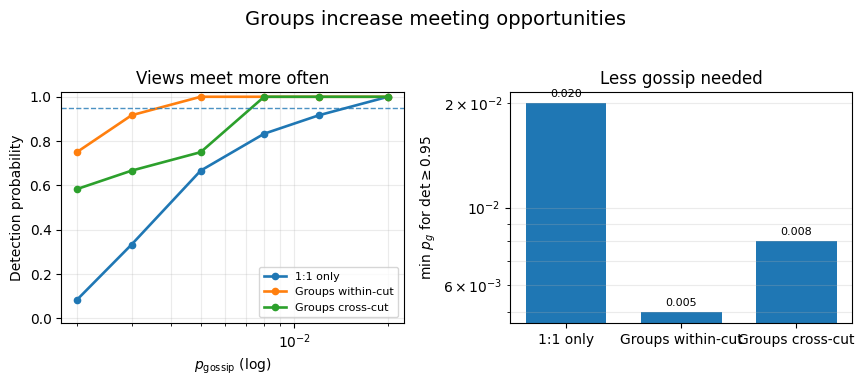

In [46]:
plot_group_meeting_advantage_robust(
   df_agg_group_meet,
   df_group_meet_threshold,
   det_thr=DET_THR_GROUP_MEET,
   outdir=PLOTS_GROUP_MEET,
   stem="fig_group_meeting_advantage",
   title="Groups increase meeting opportunities",
)

## Experimental Scenario: How costly is supressing all cross-cut when there are groups?

In [48]:
# =========================
# Scenario: CROSS-CUT GROUPS UNDER SUPPRESSION
# Goal:
#   show whether cross-cut groups make permanent partition maintenance harder
# by measuring detection under increasing cross-cut suppression.
# =========================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_GROUP_SUPPRESS = OUT_ROOT / "scenario_groups_under_suppression"

BASE_GROUP_SUPPRESS = dict(BASE_SMALL)
BASE_GROUP_SUPPRESS.update(
    users=12000,
    hours=6.0,
    fork_hour=3.0,
    fork_duration=2.0,
    server_mode="permanent_fork",
    mode="sth_proof",

    # hard enough that suppression matters
    adoption=0.10,
    fork_frac=0.05,

    # very sparse pairwise bridge opportunities
    p_contact_cross=0.001,

    # group topology available in all conditions
    groups=2500,
    avg_group_size=8,

    # fixed gossip level near the interesting threshold region
    p_gossip=0.008,

    sticky_victims=True,
)

# Keep total sender-action rate roughly fixed
# msg_rate_1to1 + msg_rate_group = 0.28
STRUCTURES_GROUP_SUPPRESS = [
    {
        "structure": "1:1 only",
        "msg_rate_1to1": 0.28,
        "msg_rate_group": 0.00,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups within-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.00,
    },
    {
        "structure": "Groups cross-cut",
        "msg_rate_1to1": 0.04,
        "msg_rate_group": 0.24,
        "p_group_cross": 0.20,
    },
]

P_DROP_GRID_GROUP_SUPPRESS = [0.0, 0.25, 0.5, 0.75, 0.9, 1.0]

REPS_GROUP_SUPPRESS = 12
SEED_BASE_GROUP_SUPPRESS = 61000

DET_THR_GROUP_SUPPRESS = 0.95

In [49]:
# =========================
# Run cross-cut-groups-under-suppression scenario
# =========================

OUT_GROUP_SUPPRESS.mkdir(parents=True, exist_ok=True)

parts = []

for i, s in enumerate(STRUCTURES_GROUP_SUPPRESS):
    cfg = dict(BASE_GROUP_SUPPRESS)
    cfg.update(
        msg_rate_1to1=s["msg_rate_1to1"],
        msg_rate_group=s["msg_rate_group"],
        p_group_cross=s["p_group_cross"],
    )

    outdir = OUT_GROUP_SUPPRESS / f"cond_{i+1}"
    outdir.mkdir(parents=True, exist_ok=True)

    df_part = run_grid(
        cfg,
        dict(p_drop_crosscut=P_DROP_GRID_GROUP_SUPPRESS),
        replicates=REPS_GROUP_SUPPRESS,
        seed_base=SEED_BASE_GROUP_SUPPRESS + 1000 * i,
        outroot=outdir,
        detection_policy="strict",
    ).copy()

    df_part["structure"] = s["structure"]
    df_part["msg_rate_1to1"] = s["msg_rate_1to1"]
    df_part["msg_rate_group"] = s["msg_rate_group"]
    df_part["p_group_cross"] = s["p_group_cross"]

    parts.append(df_part)

df_raw_group_suppress = pd.concat(parts, ignore_index=True)
df_raw_group_suppress.to_csv(OUT_GROUP_SUPPRESS / "raw.csv", index=False)

print("Wrote:", (OUT_GROUP_SUPPRESS / "raw.csv").resolve())
display(df_raw_group_suppress.head())

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\cond_1\permanent_fork_sth_proof_n12000_pg0p008_a0p1_ff0p05_s61000_drop0_pc0p001_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\cond_1\permanent_fork_sth_proof_n12000_pg0p008_a0p1_ff0p05_s61000_drop0_pc0p001_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\cond_1\permanent_fork_sth_proof_n12000_pg0p008_a0p1_ff0p05_s61001_drop0_pc0p001_pgc0/summary.json and C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\cond_1\permanent_fork_sth_proof_n12000_pg0p008_a0p1_ff0p05_s61001_drop0_pc0p001_pgc0/timeline.csv.

Done. See C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\cond_1\permanent_fork_sth_proof_n12000_pg0p008_a0p1_ff0p05_s61002_drop0_pc0p001_p

,server_mode,mode,users,hours,dt_min,p_gossip,adoption,fork_frac,fork_hour,detected,...,msg_rate_1to1,msg_rate_group,groups,avg_group_size,proof_withhold_rate,proof_timeout_rate,invalid_proof_rate,wall_s,run_dir,structure
0,permanent_fork,sth_proof,12000,6.0,5.0,0.008,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.234880,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
1,permanent_fork,sth_proof,12000,6.0,5.0,0.008,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.182886,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
2,permanent_fork,sth_proof,12000,6.0,5.0,0.008,0.1,0.05,3.0,True,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.149535,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
3,permanent_fork,sth_proof,12000,6.0,5.0,0.008,0.1,0.05,3.0,False,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.142381,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only
4,permanent_fork,sth_proof,12000,6.0,5.0,0.008,0.1,0.05,3.0,True,...,0.28,0.0,2500,8,0.0,0.0,0.0,1.302987,C:/Users/efasllija/dev/gossip-poc/out_nb_incre...,1:1 only


In [50]:
# =========================
# Aggregate outcomes by structure and suppression level
# =========================

def q25(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.25)) if x.size else np.nan

def q75(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().to_numpy()
    return float(np.quantile(x, 0.75)) if x.size else np.nan

rows = []

for (structure, pdrop), s in df_raw_group_suppress.groupby(["structure", "p_drop_crosscut"], dropna=False):
    det = pd.to_numeric(s["detected"], errors="coerce").fillna(0)
    lat = pd.to_numeric(s["lat_ev_min"], errors="coerce")
    bpd = pd.to_numeric(s["bytes_per_delivery"], errors="coerce")

    lat_success = lat[det.astype(bool) & lat.notna()]

    rows.append({
        "structure": structure,
        "p_drop_crosscut": float(pdrop),
        "detected_rate": float(det.mean()),
        "lat_ev_med": float(np.median(lat_success)) if len(lat_success) else np.nan,
        "lat_ev_q25": q25(lat_success),
        "lat_ev_q75": q75(lat_success),
        "bpd_mean": float(bpd.mean()) if len(bpd.dropna()) else np.nan,
        "reps": int(len(s)),
    })

df_agg_group_suppress = pd.DataFrame(rows)

structure_order = [s["structure"] for s in STRUCTURES_GROUP_SUPPRESS]
df_agg_group_suppress["structure"] = pd.Categorical(
    df_agg_group_suppress["structure"],
    categories=structure_order,
    ordered=True,
)
df_agg_group_suppress = df_agg_group_suppress.sort_values(
    ["structure", "p_drop_crosscut"]
).reset_index(drop=True)

df_agg_group_suppress.to_csv(OUT_GROUP_SUPPRESS / "agg.csv", index=False)

print("Wrote:", (OUT_GROUP_SUPPRESS / "agg.csv").resolve())
display(df_agg_group_suppress)

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\agg.csv


,structure,p_drop_crosscut,detected_rate,lat_ev_med,lat_ev_q25,lat_ev_q75,bpd_mean,reps
0,1:1 only,0.00,0.500000,85.0,60.00,113.75,0.764132,12
1,1:1 only,0.25,0.416667,95.0,80.00,120.00,0.756582,12
2,1:1 only,0.50,0.416667,95.0,80.00,120.00,0.754074,12
3,1:1 only,0.75,0.250000,120.0,102.50,130.00,0.736373,12
4,1:1 only,0.90,0.083333,85.0,85.00,85.00,0.731292,12
5,1:1 only,1.00,0.000000,NaN,NaN,NaN,0.726313,12
6,Groups within-cut,0.00,1.000000,62.5,37.50,106.25,0.681672,12
7,Groups within-cut,0.25,1.000000,82.5,37.50,131.25,0.671527,12
8,Groups within-cut,0.50,0.916667,110.0,35.00,137.50,0.661085,12
9,Groups within-cut,0.75,0.750000,105.0,65.00,130.00,0.652899,12


In [51]:
# =========================
# Summary: maximum suppressible cross-cut drop rate
# while still preserving reliable detection
# =========================

rows = []

for structure, s in df_agg_group_suppress.groupby("structure", dropna=False):
    s = s.sort_values("p_drop_crosscut")
    keep = s[s["detected_rate"] >= DET_THR_GROUP_SUPPRESS]

    rows.append({
        "structure": structure,
        "max_p_drop_with_reliable_detection": float(keep["p_drop_crosscut"].max()) if not keep.empty else np.nan
    })

df_group_suppress_threshold = pd.DataFrame(rows)
df_group_suppress_threshold["structure"] = pd.Categorical(
    df_group_suppress_threshold["structure"],
    categories=structure_order,
    ordered=True,
)
df_group_suppress_threshold = df_group_suppress_threshold.sort_values("structure").reset_index(drop=True)

display(df_group_suppress_threshold)

C:\Users\efasllija\AppData\Local\Temp\ipykernel_43248\781213240.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for structure, s in df_agg_group_suppress.groupby("structure", dropna=False):


,structure,max_p_drop_with_reliable_detection
0,1:1 only,NaN
1,Groups within-cut,0.25
2,Groups cross-cut,0.00


In [52]:
# =========================
# Plot: cross-cut groups under suppression
# Left: detection probability vs cross-cut suppression
# Right: maximum suppression preserving reliable detection
# =========================

PLOTS_GROUP_SUPPRESS = OUT_GROUP_SUPPRESS / "plots"
PLOTS_GROUP_SUPPRESS.mkdir(parents=True, exist_ok=True)

def plot_groups_under_suppression(
    df_agg,
    df_thr,
    det_thr=0.95,
    outdir=None,
    stem="fig_groups_under_suppression",
    title="Cross-cut groups raise the adversary's suppression burden",
):
    fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.7))
    ax1, ax2 = axes

    order = ["1:1 only", "Groups within-cut", "Groups cross-cut"]

    # -------------------------
    # Panel 1: detection probability vs p_drop_crosscut
    # -------------------------
    for structure in order:
        s = df_agg[df_agg["structure"].astype(str) == structure].copy()
        if s.empty:
            continue

        s["p_drop_crosscut"] = pd.to_numeric(s["p_drop_crosscut"], errors="coerce")
        s["detected_rate"] = pd.to_numeric(s["detected_rate"], errors="coerce")
        s = s.sort_values("p_drop_crosscut")

        x = s["p_drop_crosscut"].to_numpy(dtype=float)
        y = s["detected_rate"].to_numpy(dtype=float)

        m = np.isfinite(x) & np.isfinite(y)
        if m.any():
            ax1.plot(
                x[m], y[m],
                marker="o",
                linewidth=1.9,
                markersize=4.5,
                label=structure,
            )

    ax1.axhline(det_thr, linestyle="--", linewidth=1.0, alpha=0.8)
    ax1.set_ylim(-0.02, 1.02)
    ax1.set_xlabel("Cross-cut drop probability")
    ax1.set_ylabel("Detection probability")
    ax1.set_title("Detection survives stronger suppression")
    ax1.grid(True, alpha=0.25)
    ax1.legend(fontsize=8, frameon=True, loc="lower left")

    # -------------------------
    # Panel 2: max suppressible drop rate
    # -------------------------
    d2 = (
        df_thr.copy()
        .set_index("structure")
        .reindex(order)
        .reset_index()
    )

    labels = d2["structure"].astype(str).tolist()
    y = pd.to_numeric(
        d2["max_p_drop_with_reliable_detection"], errors="coerce"
    ).to_numpy(dtype=float)
    x = np.arange(len(labels))

    valid = np.isfinite(y)
    ax2.bar(x[valid], y[valid], width=0.7)

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel(r"max $p_{\mathrm{drop}}$ with det$\geq 0.95$")
    ax2.set_title("More censorship needed")
    ax2.grid(True, axis="y", alpha=0.25)

    for xi, yi in zip(x, y):
        if np.isfinite(yi):
            ax2.annotate(
                f"{yi:.2f}",
                xy=(xi, yi),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    fig.suptitle(title, y=1.03, fontsize=14)
    fig.tight_layout()

    if outdir is not None:
        outdir = Path(outdir)
        outdir.mkdir(parents=True, exist_ok=True)
        outbase = outdir / stem
        fig.savefig(outbase.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
        fig.savefig(outbase.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.02)
        print("Wrote:", outbase.with_suffix(".pdf").resolve())

    plt.show()

Wrote: C:\Users\efasllija\dev\gossip-poc\out_nb_incremental_clean0104\scenario_groups_under_suppression\plots\fig_groups_under_suppression.pdf


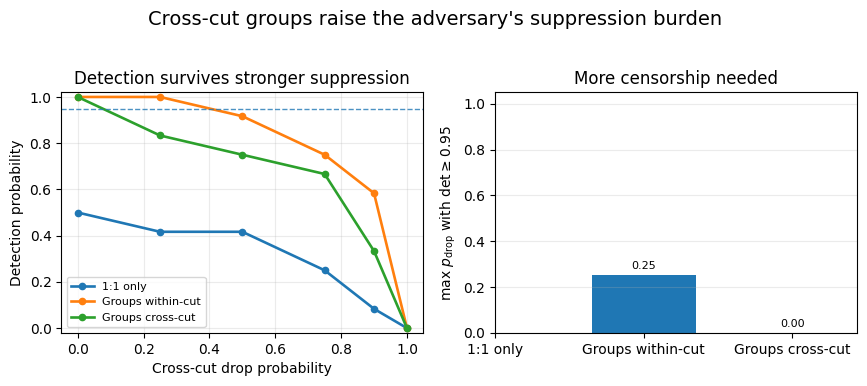

In [53]:
# =========================
# Generate the suppression-resilience figure
# =========================

plot_groups_under_suppression(
    df_agg_group_suppress,
    df_group_suppress_threshold,
    det_thr=DET_THR_GROUP_SUPPRESS,
    outdir=PLOTS_GROUP_SUPPRESS,
    stem="fig_groups_under_suppression",
    title="Cross-cut groups raise the adversary's suppression burden",
)